# Simulation Recovery Diagnostics

This notebook is designed to make the recovery study easier to read and easier to connect to the parameters that matter in the grid run:

- true number of clusters $C$
- number of assessors $N$
- number of items $m$
- block density
- dispersion parameter $\theta$

It works with both completed runs and partially completed runs inside `simulation_recovery_runs/`.

The main outputs are:

- tidy trial-level and scenario-level tables
- average recovery summaries for each parameter level
- interaction heatmaps showing where combinations of parameters become difficult
- focused hard-slice vs easy-slice views over $(N, m)$
- failure tables showing where recovery drops below a chosen threshold

In [8]:
from __future__ import annotations

import importlib
import json
import math
import sys
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

# ── Root path & run directories ───────────────────────────────────────────────
ROOT = Path('.').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RUNS_DIR = Path('simulation_recovery_runs')

# ── Original recovery study metrics/params ────────────────────────────────────
MAIN_METRICS = {
    'aligned_cluster_accuracy': 'Cluster Accuracy',
    'adjusted_rand_index': 'ARI',
    'weighted_normalized_kemeny_p_half': 'Normalized Kemeny',
    'weighted_same_block_f1': 'Block F1',
    'weighted_block_count_error': 'Block Count Error',
    'weighted_strict_inversions': 'Strict Inversions',
}

PARAM_SPECS = [
    ('n_clusters_true', 'True C'),
    ('n_assessors', 'N assessors'),
    ('n_items', 'n items'),
    ('block_density', 'Block density'),
    ('theta', 'θ'),
]

METRIC_SPECS = [
    ('aligned_cluster_accuracy', 'Cluster accuracy', False),
    ('adjusted_rand_index', 'ARI', False),
    ('weighted_same_block_f1', 'Block F1', False),
    ('weighted_normalized_kemeny_p_half', 'Order score', True),
]

PERFORMANCE_CMAP = 'RdYlGn'
BIAS_CMAP = 'RdBu_r'

# ── OAT / large_oat specs ─────────────────────────────────────────────────────
OAT_METRIC_SPECS = [
    ('aligned_cluster_accuracy',           'Cluster accuracy', False),
    ('adjusted_rand_index',                'ARI',              False),
    ('weighted_same_block_f1',             'Block F1',         False),
    ('weighted_normalized_kemeny_p_half',  'Order score',      True),
    ('weighted_theta_abs_error',           'θ abs error',      False),
]

OAT_PARAM_SPECS = [
    ('n_clusters_true', 'True C'),
    ('n_assessors',     'N'),
    ('n_items',         'm'),
    ('block_density',   'Block density'),
    ('theta',           'θ'),
]

# ── TiMMM OAT specs ───────────────────────────────────────────────────────────
TIMMM_METRIC_SPECS = [
    ('cluster_ari',     'Cluster ARI',    '↑ better'),
    ('order_distance',  'Order distance', '↓ better'),
    ('block_ari',       'Block ARI',      '↑ better'),
    ('theta_rmse',      'θ RMSE',         '↓ better'),
    ('runtime_seconds', 'Runtime (s)',    ''),
]

TIMMM_PARAM_SPECS = [
    ('n_clusters_true', 'True C'),
    ('n_assessors',     'N'),
    ('n_items',         'n'),
    ('block_density',   'Block density'),
    ('theta',           'θ'),
]

OAT_DEFAULTS = {
    'n_clusters_true': 5,
    'n_assessors':     200,
    'n_items':         20,
    'block_density':   0.4,
    'theta':           1.0,
}

TIMMM_CMP_METRICS = [
    ('cluster_ari',     'Cluster ARI',    True),
    ('order_distance',  'Order distance', False),
    ('block_ari',       'Block ARI',      True),
    ('theta_rmse',      'θ RMSE',         False),
]

RUNTIME_COL = 'runtime_seconds_mean'

_CONV_METRICS = [
    ('cluster_ari',    'Cluster ARI',    True),
    ('order_distance', 'Order distance', False),
    ('block_ari',      'Block ARI',      True),
    ('theta_rmse',     'θ RMSE',         False),
]

# ── Consensus study specs ─────────────────────────────────────────────────────
_CONS_METRIC_SPECS = [
    ('cluster_nmi',    'Cluster NMI',    '↑ better', True),
    ('order_distance', 'Order distance', '↓ better', True),
    ('block_nmi',      'Block NMI',      '↑ better', True),
    ('theta_rmse',     'θ RMSE',         '↓ better', False),
]

_CONS_STYLES = [
    ('rand_mean',      'Random – mean',        'o', '-',  '#4878d0'),
    ('rand_consensus', 'Random – consensus',   's', '--', '#4878d0'),
    ('spec_mean',      'Spectral – mean',      'o', '-',  '#ee854a'),
    ('spec_consensus', 'Spectral – consensus', 's', '--', '#ee854a'),
]

# ── Raw 30-seed OAT specs ─────────────────────────────────────────────────────
RAW_OAT_DEFAULTS = {
    'n_clusters_true': 5,
    'n_assessors':     200,
    'n_items':         20,
    'block_density':   0.4,
    'theta':           1.0,
}

RAW_METRIC_SPECS = [
    ('cluster_nmi',    'Cluster NMI',    '↑ better', True),
    ('order_distance', 'Order distance', '↓ better', True),
    ('block_nmi',      'Block NMI',      '↑ better', True),
    ('theta_rmse',     'θ RMSE',         '↓ better', False),
]

RAW_PARAM_SPECS = [
    ('n_clusters_true', 'True $C$'),
    ('n_assessors',     '$N$'),
    ('n_items',         '$n$'),
    ('block_density',   r'Block density $\delta$'),
    ('theta',           r'$\theta$'),
]

# ── Grid study specs ──────────────────────────────────────────────────────────
_GRID_METRIC_SPECS = [
    ('cluster_nmi',    'Cluster NMI',    '↑ better', True),
    ('order_distance', 'Order distance', '↓ better', True),
    ('block_nmi',      'Block NMI',      '↑ better', True),
    ('theta_rmse',     'θ RMSE',         '↓ better', False),
]

# ── Plot style presets ────────────────────────────────────────────────────────
_PALETTE = [
    '#0072B2',  # blue
    '#E69F00',  # amber
    '#009E73',  # green
    '#CC79A7',  # pink
    '#56B4E9',  # sky
    '#D55E00',  # vermilion
    '#000000',  # black
]

_RC = {
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.linewidth':      0.7,
    'xtick.major.size':    3.0,
    'xtick.major.width':   0.7,
    'ytick.major.size':    3.0,
    'ytick.major.width':   0.7,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'font.family':         'sans-serif',
    'font.size':           8.5,
    'axes.titlesize':      9.5,
    'axes.titleweight':    'semibold',
    'axes.labelsize':      8.5,
    'axes.grid':           True,
    'grid.color':          '#000000',
    'grid.alpha':          0.10,
    'grid.linestyle':      ':',
    'grid.linewidth':      0.6,
    'figure.dpi':          150,
    'savefig.dpi':         300,
    'savefig.bbox':        'tight',
}

_GRID_RC = {k: v for k, v in _RC.items() if k not in ('savefig.dpi', 'savefig.bbox')}


# ═══════════════════════════════════════════════════════════════════════════════
# Helper functions
# ═══════════════════════════════════════════════════════════════════════════════

def strip_seed(name: str) -> str:
    return name.rsplit('_seed', 1)[0] if '_seed' in name else name

# Alias used in some flatten functions
_strip_seed = strip_seed


def run_directories() -> list[Path]:
    if not RUNS_DIR.exists():
        return []
    return sorted([path for path in RUNS_DIR.iterdir() if path.is_dir()])


def latest_run() -> Path:
    runs = run_directories()
    if not runs:
        raise FileNotFoundError(f'No run directories found in {RUNS_DIR}')
    return runs[-1]


def load_run(run_dir: Path) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    metadata_path = run_dir / 'run_metadata.json'
    all_results_path = run_dir / 'all_results.json'

    metadata: dict[str, Any] = {}
    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text(encoding='utf-8'))
    metadata.setdefault('output_dir', str(run_dir))

    if all_results_path.exists():
        results = json.loads(all_results_path.read_text(encoding='utf-8'))
        return metadata, results

    per_scenario_files = sorted(
        [
            path for path in run_dir.glob('*.json')
            if path.name not in {'run_metadata.json', 'all_results.json', 'scenario_summary.json'}
        ]
    )
    results = [json.loads(path.read_text(encoding='utf-8')) for path in per_scenario_files]
    return metadata, results


def flatten_results(results: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for result in results:
        scenario = result['scenario']
        settings = result['settings']
        metrics = result['metrics']
        rows.append({
            'scenario_name': scenario['name'],
            'base_scenario': strip_seed(scenario['name']),
            'seed': scenario['seed'],
            'n_clusters_true': scenario['n_clusters'],
            'n_assessors': scenario['n_assessors'],
            'n_items': scenario['n_items'],
            'theta': scenario['theta'],
            'block_density': scenario.get('block_density'),
            'fit_n_clusters': settings.get('fit_n_clusters'),
            'n_iter': settings.get('n_iter'),
            'burn_in': settings.get('burn_in'),
            'thin': settings.get('thin'),
            'n_restarts': settings.get('n_restarts'),
            'runtime_seconds': result.get('runtime_seconds'),
            **metrics,
        })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ['n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta', 'seed']
    ).reset_index(drop=True)


def aggregate_trials(trial_df: pd.DataFrame) -> pd.DataFrame:
    if trial_df.empty:
        return pd.DataFrame()
    group_cols = [
        'base_scenario', 'n_clusters_true', 'n_assessors', 'n_items',
        'block_density', 'theta', 'fit_n_clusters', 'n_iter', 'burn_in',
        'thin', 'n_restarts'
    ]
    metric_cols = list(MAIN_METRICS.keys())
    agg_cols = metric_cols + ['n_pred_clusters', 'runtime_seconds']

    summary = trial_df.groupby(group_cols, dropna=False)[agg_cols].agg(['mean', 'std', 'count']).reset_index()
    summary.columns = [
        '_'.join([str(part) for part in col if part]).rstrip('_')
        if isinstance(col, tuple) else col
        for col in summary.columns
    ]
    return summary.sort_values(['n_clusters_true', 'n_assessors', 'n_items', 'theta']).reset_index(drop=True)


def metric_mean_col(metric_key: str) -> str:
    return f'{metric_key}_mean'


def metric_std_col(metric_key: str) -> str:
    return f'{metric_key}_std'


def _pretty_level(value: Any) -> str:
    if pd.isna(value):
        return 'NA'
    if isinstance(value, (int, np.integer)):
        return f'{int(value)}'
    if isinstance(value, (float, np.floating)):
        return f'{float(value):.2f}'.rstrip('0').rstrip('.')
    return str(value)


def _timmm_pretty_level(value) -> str:
    """Pretty-print a parameter level value (TiMMM OAT style)."""
    if pd.isna(value):
        return 'NA'
    if isinstance(value, (int, np.integer)):
        return str(int(value))
    if isinstance(value, (float, np.floating)):
        return f'{float(value):.2f}'.rstrip('0').rstrip('.')
    return str(value)


def _metric_values(df: pd.DataFrame, metric_key: str, invert: bool = False) -> pd.Series:
    values = df[metric_mean_col(metric_key)].astype(float)
    return 1.0 - values if invert else values


def _oat_sweep_df(summary_df: pd.DataFrame, sweep_key: str) -> pd.DataFrame:
    """Return only rows from the OAT sweep for *sweep_key* (all other axes at OAT_DEFAULTS)."""
    mask = pd.Series(True, index=summary_df.index)
    for key, default in OAT_DEFAULTS.items():
        if key == sweep_key:
            continue
        mask &= summary_df[key] == default
    return summary_df[mask]


def _cons_oat_sweep_df(df: pd.DataFrame, param_key: str) -> pd.DataFrame:
    """OAT-sweep filter for consensus study (uses OAT_DEFAULTS, float-safe)."""
    mask = pd.Series(True, index=df.index)
    for col, val in OAT_DEFAULTS.items():
        if col == param_key:
            continue
        if col in df.columns:
            mask &= df[col].apply(
                lambda x: abs(x - val) < 1e-9 if isinstance(x, float) else x == val
            )
    return df[mask]


def _raw_oat_sweep(trial_df: pd.DataFrame, sweep_key: str) -> pd.DataFrame:
    """OAT-sweep filter for the raw 30-seed study (uses RAW_OAT_DEFAULTS)."""
    mask = np.ones(len(trial_df), dtype=bool)
    for key, default in RAW_OAT_DEFAULTS.items():
        if key == sweep_key:
            continue
        if isinstance(default, float):
            mask &= trial_df[key].apply(lambda v: abs(float(v) - default) < 1e-9).values
        else:
            mask &= (trial_df[key] == default).values
    return trial_df[mask]


def _oat_main_effects(summary_df: pd.DataFrame) -> pd.DataFrame:
    """Compute main effects for the large_oat metric/param specs."""
    rows = []
    for param_key, param_label in OAT_PARAM_SPECS:
        for level, group in summary_df.groupby(param_key, sort=True, dropna=False):
            for metric_key, metric_label, invert in OAT_METRIC_SPECS:
                col = metric_mean_col(metric_key)
                if col not in group.columns:
                    continue
                values = group[col].astype(float)
                if invert:
                    values = 1.0 - values
                rows.append({
                    'parameter': param_label,
                    'level': level,
                    'level_label': _pretty_level(level),
                    'metric': metric_label,
                    'mean': values.mean(),
                    'se': values.std(ddof=1) / max(len(values) - 1, 1) ** 0.5,
                })
    return pd.DataFrame(rows)


def show_parameter_grid(metadata: dict[str, Any], summary_df: pd.DataFrame) -> None:
    varied_rows = []
    for key, label in PARAM_SPECS:
        levels = sorted(summary_df[key].dropna().unique().tolist())
        varied_rows.append({
            'parameter': label,
            'levels': ', '.join(_pretty_level(v) for v in levels),
            'n_levels': len(levels),
        })

    print(f"Run: {Path(metadata.get('output_dir', '')).name}")
    display(pd.DataFrame(varied_rows))

    fixed_settings = {
        'fit_n_clusters': summary_df['fit_n_clusters'].dropna().unique().tolist(),
        'n_iter': summary_df['n_iter'].dropna().unique().tolist(),
        'burn_in': summary_df['burn_in'].dropna().unique().tolist(),
        'thin': summary_df['thin'].dropna().unique().tolist(),
        'n_restarts': summary_df['n_restarts'].dropna().unique().tolist(),
    }
    fixed_settings = {k: (v[0] if len(v) == 1 else v) for k, v in fixed_settings.items() if len(v) > 0}
    print('Fixed fitting settings:', fixed_settings)


def compute_main_effects(summary_df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for param_key, param_label in PARAM_SPECS:
        for level, group in summary_df.groupby(param_key, sort=True, dropna=False):
            for metric_key, metric_label, invert in METRIC_SPECS:
                values = _metric_values(group, metric_key, invert=invert)
                rows.append({
                    'parameter_key': param_key,
                    'parameter': param_label,
                    'level': level,
                    'level_label': _pretty_level(level),
                    'metric': metric_label,
                    'mean': values.mean(),
                    'se': values.std(ddof=1) / np.sqrt(len(values)) if len(values) > 1 else 0.0,
                    'n_scenarios': len(values),
                })
    return pd.DataFrame(rows)


def add_cluster_count_diagnostics(trial_df: pd.DataFrame, summary_df: pd.DataFrame) -> pd.DataFrame:
    group_cols = ['base_scenario', 'n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta']
    if trial_df.empty:
        out = summary_df.copy()
        out['cluster_recovery_rate'] = np.nan
        out['cluster_count_abs_error'] = np.nan
        out['cluster_count_bias'] = np.nan
        return out

    tmp = trial_df.copy()
    tmp['cluster_match'] = (tmp['n_pred_clusters'] == tmp['n_clusters_true']).astype(float)
    tmp['cluster_count_abs_error'] = (tmp['n_pred_clusters'] - tmp['n_clusters_true']).abs()
    tmp['cluster_count_bias'] = tmp['n_pred_clusters'] - tmp['n_clusters_true']

    stats = (
        tmp.groupby(group_cols, dropna=False)
        .agg(
            cluster_recovery_rate=('cluster_match', 'mean'),
            cluster_count_abs_error=('cluster_count_abs_error', 'mean'),
            cluster_count_bias=('cluster_count_bias', 'mean'),
        )
        .reset_index()
    )
    return summary_df.merge(stats, on=group_cols, how='left')


def display_main_effect_tables(summary_df: pd.DataFrame) -> None:
    effects = compute_main_effects(summary_df)
    for _, param_label in PARAM_SPECS:
        table = (
            effects[effects['parameter'] == param_label]
            .pivot(index='level_label', columns='metric', values='mean')
            .round(3)
            .sort_index()
        )
        print(f'Average recovery by {param_label}')
        display(table)


def display_cluster_count_impact(cluster_df: pd.DataFrame) -> None:
    print('Recovery of the number of clusters')
    by_c = (
        cluster_df.groupby('n_clusters_true')[['n_pred_clusters_mean', 'cluster_recovery_rate', 'cluster_count_abs_error']]
        .mean()
        .rename(columns={
            'n_pred_clusters_mean': 'mean predicted clusters',
            'cluster_recovery_rate': 'exact C recovery rate',
            'cluster_count_abs_error': 'mean |Ĉ - C|',
        })
        .round(3)
    )
    display(by_c)

    impact = (
        cluster_df.groupby('cluster_count_abs_error')[[
            metric_mean_col('aligned_cluster_accuracy'),
            metric_mean_col('adjusted_rand_index'),
            metric_mean_col('weighted_same_block_f1'),
            metric_mean_col('weighted_normalized_kemeny_p_half'),
        ]]
        .mean()
        .reset_index()
        .sort_values('cluster_count_abs_error')
    )
    impact['order_score_mean'] = 1.0 - impact[metric_mean_col('weighted_normalized_kemeny_p_half')]
    impact = impact.rename(columns={
        'cluster_count_abs_error': 'mean |Ĉ - C|',
        metric_mean_col('aligned_cluster_accuracy'): 'cluster accuracy',
        metric_mean_col('adjusted_rand_index'): 'ARI',
        metric_mean_col('weighted_same_block_f1'): 'Block F1',
        'order_score_mean': 'order score',
    })
    print('Performance conditional on cluster-count error')
    display(impact[['mean |Ĉ - C|', 'cluster accuracy', 'ARI', 'Block F1', 'order score']].round(3))


def plot_main_effects(summary_df: pd.DataFrame) -> None:
    effects = compute_main_effects(summary_df)
    metric_order = [label for _, label, _ in METRIC_SPECS]
    colors = sns.color_palette('deep', len(metric_order))

    fig, axes = plt.subplots(len(metric_order), len(PARAM_SPECS), figsize=(18, 10), constrained_layout=True)

    for col_idx, (_, param_label) in enumerate(PARAM_SPECS):
        subset = effects[effects['parameter'] == param_label].copy()
        for row_idx, metric_label in enumerate(metric_order):
            ax = axes[row_idx, col_idx]
            metric_df = subset[subset['metric'] == metric_label].sort_values('level')
            x = np.arange(len(metric_df))
            ax.errorbar(
                x,
                metric_df['mean'],
                yerr=1.96 * metric_df['se'],
                marker='o',
                linewidth=2.2,
                capsize=3,
                color=colors[row_idx],
            )
            ax.set_xticks(x)
            ax.set_xticklabels(metric_df['level_label'])
            ax.set_ylim(0, 1.02)
            ax.grid(alpha=0.2, linestyle=':')
            if col_idx == 0:
                ax.set_ylabel(metric_label)

    fig.suptitle('Average recovery at each parameter level (mean ± 95% CI over the remaining grid)', fontsize=14, fontweight='bold')
    plt.show()


def _pairwise_matrix(summary_df: pd.DataFrame, row_key: str, col_key: str, metric_key: str, invert: bool = False) -> pd.DataFrame:
    values = summary_df[[row_key, col_key, metric_mean_col(metric_key)]].copy()
    values['score'] = _metric_values(values, metric_key, invert=invert)
    return (
        values.pivot_table(index=row_key, columns=col_key, values='score', aggfunc='mean')
        .sort_index()
        .sort_index(axis=1)
    )


def plot_interaction_heatmaps(summary_df: pd.DataFrame) -> None:
    pair_specs = [
        ('n_clusters_true', 'theta', 'C × θ'),
        ('n_clusters_true', 'n_items', 'C × m'),
        ('theta', 'block_density', 'θ × block density'),
        ('n_assessors', 'n_items', 'N × m'),
    ]
    metric_rows = [
        ('aligned_cluster_accuracy', 'Cluster accuracy', False),
        ('weighted_normalized_kemeny_p_half', 'Order score', True),
    ]
    label_map = {key: label for key, label in PARAM_SPECS}

    fig, axes = plt.subplots(len(metric_rows), len(pair_specs), figsize=(18, 8), constrained_layout=True)

    for row_idx, (metric_key, metric_label, invert) in enumerate(metric_rows):
        for col_idx, (row_key, col_key, title) in enumerate(pair_specs):
            ax = axes[row_idx, col_idx]
            pivot = _pairwise_matrix(summary_df, row_key, col_key, metric_key, invert=invert)
            sns.heatmap(
                pivot,
                annot=True,
                fmt='.2f',
                cmap=PERFORMANCE_CMAP,
                vmin=0,
                vmax=1,
                cbar=(col_idx == len(pair_specs) - 1),
                ax=ax,
            )
            ax.set_title(f'{metric_label}: {title}', fontsize=11, fontweight='bold')
            ax.set_xlabel(label_map.get(col_key, col_key))
            ax.set_ylabel(label_map.get(row_key, row_key))

    plt.show()


def plot_cluster_count_diagnostics(cluster_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

    rate_ct = cluster_df.pivot_table(index='n_clusters_true', columns='theta', values='cluster_recovery_rate', aggfunc='mean').sort_index().sort_index(axis=1)
    sns.heatmap(rate_ct, annot=True, fmt='.2f', cmap=PERFORMANCE_CMAP, vmin=0, vmax=1, ax=axes[0, 0], cbar=False)
    axes[0, 0].set_title('Exact recovery rate of Ĉ: C × θ', fontweight='bold')
    axes[0, 0].set_xlabel('θ')
    axes[0, 0].set_ylabel('True C')

    rate_cm = cluster_df.pivot_table(index='n_clusters_true', columns='n_items', values='cluster_recovery_rate', aggfunc='mean').sort_index().sort_index(axis=1)
    sns.heatmap(rate_cm, annot=True, fmt='.2f', cmap=PERFORMANCE_CMAP, vmin=0, vmax=1, ax=axes[0, 1], cbar=False)
    axes[0, 1].set_title('Exact recovery rate of Ĉ: C × m', fontweight='bold')
    axes[0, 1].set_xlabel('n items')
    axes[0, 1].set_ylabel('True C')

    bias_ct = cluster_df.pivot_table(index='n_clusters_true', columns='theta', values='cluster_count_bias', aggfunc='mean').sort_index().sort_index(axis=1)
    sns.heatmap(bias_ct, annot=True, fmt='.2f', cmap=BIAS_CMAP, center=0, ax=axes[0, 2], cbar=False)
    axes[0, 2].set_title('Mean cluster-count bias: Ĉ − C', fontweight='bold')
    axes[0, 2].set_xlabel('θ')
    axes[0, 2].set_ylabel('True C')

    sns.scatterplot(
        data=cluster_df,
        x='cluster_count_abs_error',
        y=metric_mean_col('aligned_cluster_accuracy'),
        hue='n_clusters_true',
        size='n_items',
        palette='deep',
        alpha=0.8,
        ax=axes[1, 0],
    )
    axes[1, 0].set_title('Accuracy vs |Ĉ − C|', fontweight='bold')
    axes[1, 0].set_xlabel('Mean absolute cluster-count error')
    axes[1, 0].set_ylabel('Cluster accuracy')
    axes[1, 0].set_ylim(0, 1.02)

    sns.scatterplot(
        data=cluster_df,
        x='cluster_count_abs_error',
        y=metric_mean_col('adjusted_rand_index'),
        hue='n_clusters_true',
        size='n_items',
        palette='deep',
        legend=False,
        alpha=0.8,
        ax=axes[1, 1],
    )
    axes[1, 1].set_title('ARI vs |Ĉ − C|', fontweight='bold')
    axes[1, 1].set_xlabel('Mean absolute cluster-count error')
    axes[1, 1].set_ylabel('ARI')
    axes[1, 1].set_ylim(0, 1.02)

    perf_by_error = (
        cluster_df.groupby('cluster_count_abs_error')[metric_mean_col('weighted_same_block_f1')]
        .mean()
        .reset_index()
        .sort_values('cluster_count_abs_error')
    )
    axes[1, 2].plot(perf_by_error['cluster_count_abs_error'], perf_by_error[metric_mean_col('weighted_same_block_f1')], marker='o', linewidth=2.5)
    axes[1, 2].set_title('Block F1 vs |Ĉ − C|', fontweight='bold')
    axes[1, 2].set_xlabel('Mean absolute cluster-count error')
    axes[1, 2].set_ylabel('Block F1')
    axes[1, 2].set_ylim(0, 1.02)
    axes[1, 2].grid(alpha=0.2, linestyle=':')

    plt.show()


def plot_theta_density_slices(summary_df: pd.DataFrame) -> None:
    metric_key = 'aligned_cluster_accuracy'
    metric_col = metric_mean_col(metric_key)
    grouped = (
        summary_df.groupby(['n_clusters_true', 'block_density', 'theta'])[metric_col]
        .mean()
        .reset_index()
        .sort_values(['n_clusters_true', 'block_density', 'theta'])
    )
    clusters = sorted(grouped['n_clusters_true'].unique())
    fig, axes = plt.subplots(1, len(clusters), figsize=(5 * len(clusters), 4), sharey=True, constrained_layout=True)
    if len(clusters) == 1:
        axes = [axes]

    palette = sns.color_palette('rocket_r', grouped['block_density'].nunique())
    for ax, cluster_count in zip(axes, clusters):
        subset = grouped[grouped['n_clusters_true'] == cluster_count]
        for color, (density, group) in zip(palette, subset.groupby('block_density')):
            ax.plot(group['theta'], group[metric_col], marker='o', linewidth=2.5, color=color, label=f'bd={density:.2f}')
        ax.set_title(f'Accuracy vs θ by block density\nTrue C={cluster_count}', fontweight='bold')
        ax.set_xlabel('θ')
        ax.set_ylim(0, 1.02)
        ax.grid(alpha=0.2, linestyle=':')
        if ax is axes[0]:
            ax.set_ylabel('Cluster accuracy')
        ax.legend(title='Block density', fontsize=9)
    plt.show()


def plot_extreme_nm_slices(summary_df: pd.DataFrame, metric_key: str = 'aligned_cluster_accuracy') -> None:
    metric_col = metric_mean_col(metric_key)
    hardness = (
        summary_df.groupby(['n_clusters_true', 'theta', 'block_density'])[metric_col]
        .mean()
        .reset_index()
    )
    hardest = hardness.nsmallest(1, metric_col).iloc[0]
    easiest = hardness.nlargest(1, metric_col).iloc[0]

    scenarios = [('Hardest average slice', hardest), ('Easiest average slice', easiest)]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

    for ax, (title, row) in zip(axes, scenarios):
        subset = summary_df[
            (summary_df['n_clusters_true'] == row['n_clusters_true'])
            & (summary_df['theta'] == row['theta'])
            & (summary_df['block_density'] == row['block_density'])
        ]
        pivot = (
            subset.pivot_table(index='n_items', columns='n_assessors', values=metric_col, aggfunc='mean')
            .sort_index()
            .sort_index(axis=1)
        )
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap=PERFORMANCE_CMAP, vmin=0, vmax=1, cbar=(ax is axes[-1]), ax=ax)
        ax.set_xlabel('N assessors')
        ax.set_ylabel('n items')

    plt.show()


def failure_table(summary_df: pd.DataFrame, metric_key: str = 'aligned_cluster_accuracy', threshold: float = 0.8) -> pd.DataFrame:
    metric_col = metric_mean_col(metric_key)
    cols = [
        'base_scenario', 'n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta',
        metric_col,
        metric_mean_col('adjusted_rand_index'),
        metric_mean_col('weighted_normalized_kemeny_p_half'),
        metric_mean_col('weighted_same_block_f1'),
        metric_mean_col('weighted_block_count_error'),
    ]
    return summary_df.loc[summary_df[metric_col] < threshold, cols].sort_values(
        ['n_clusters_true', 'block_density', 'theta', 'n_assessors', 'n_items', metric_col]
    )


# ── Run-finder functions ───────────────────────────────────────────────────────

def latest_large_oat_run() -> Path:
    candidates = sorted(
        p for p in RUNS_DIR.iterdir()
        if p.is_dir() and p.name.startswith('recovery_large_oat_')
        and not p.name.startswith('recovery_large_oat_spectral_')
    )
    if not candidates:
        raise FileNotFoundError(
            'No recovery_large_oat_* run found. '
            'Run: python _simulation_recovery_study.py --mode large_oat'
        )
    return candidates[-1]


def latest_large_oat_spectral_run() -> Path:
    candidates = sorted(
        p for p in RUNS_DIR.iterdir()
        if p.is_dir() and p.name.startswith('recovery_large_oat_spectral_')
    )
    if not candidates:
        raise FileNotFoundError(
            'No recovery_large_oat_spectral_* run found. '
            'Run: python _simulation_recovery_study.py --mode large_oat_spectral'
        )
    return candidates[-1]


def latest_timmm_oat_run(spectral: bool = False) -> Path:
    prefix = 'recovery_timmm_spectral_' if spectral else 'recovery_timmm_oat_'
    candidates = sorted(
        p for p in RUNS_DIR.iterdir()
        if p.is_dir() and p.name.startswith(prefix)
    )
    if not candidates:
        cmd = 'python _timmm_oat_study.py --spectral' if spectral else 'python _timmm_oat_study.py'
        raise FileNotFoundError(f'No {prefix}* run found. Run: {cmd}')
    return candidates[-1]


def latest_timmm_convergence_run() -> Path:
    dirs = sorted(
        [d for d in RUNS_DIR.iterdir()
         if d.is_dir() and d.name.startswith('recovery_timmm_convergence_')],
        key=lambda d: d.name,
    )
    if not dirs:
        raise FileNotFoundError('No convergence run found in simulation_recovery_runs/')
    return dirs[-1]


def latest_timmm_consensus_run() -> Path:
    prefix = 'recovery_timmm_consensus_'
    candidates = sorted(
        p for p in RUNS_DIR.iterdir()
        if p.is_dir() and p.name.startswith(prefix)
    )
    if not candidates:
        raise FileNotFoundError(
            f'No {prefix}* run found in {RUNS_DIR}.\n'
            'Run: python _timmm_consensus_study.py'
        )
    return candidates[-1]


def latest_raw_oat_run(spectral: bool = True) -> Path:
    prefix = 'recovery_timmm_raw_spectral_' if spectral else 'recovery_timmm_raw_random_'
    candidates = sorted(
        p for p in RUNS_DIR.iterdir()
        if p.is_dir() and p.name.startswith(prefix)
    )
    if not candidates:
        flag = '' if spectral else ' --random'
        raise FileNotFoundError(
            f'No {prefix}* run found in {RUNS_DIR}. '
            f'Run: python _timmm_raw_study.py{flag}'
        )
    return candidates[-1]


def latest_items_cluster_grid_run() -> Path:
    prefix = 'recovery_items_cluster_grid_'
    candidates = sorted(
        p for p in RUNS_DIR.iterdir()
        if p.is_dir() and p.name.startswith(prefix)
    )
    if not candidates:
        raise FileNotFoundError(
            f'No {prefix}* run found in {RUNS_DIR}.\n'
            'Run: python _timmm_items_cluster_grid.py'
        )
    return candidates[-1]


# ── Flatten / aggregate functions ─────────────────────────────────────────────

def flatten_timmm(results: list[dict]) -> pd.DataFrame:
    rows = []
    for r in results:
        sc = r['scenario']
        m  = r['metrics']
        rows.append({
            'scenario_name':   sc['name'],
            'base_scenario':   strip_seed(sc['name']),
            'seed':            sc['seed'],
            'n_clusters_true': sc['n_clusters'],
            'n_assessors':     sc['n_assessors'],
            'n_items':         sc['n_items'],
            'theta':           sc['theta'],
            'block_density':   sc['block_density'],
            'fit_n_clusters':  r['settings']['fit_n_clusters'],
            'cluster_ari':     m['cluster_ari'],
            'order_distance':  m['order_distance'],
            'block_ari':       m['block_ari'],
            'theta_rmse':      m['theta_rmse'],
            'runtime_seconds': r['runtime_seconds'],
        })
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ['n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta', 'seed']
    ).reset_index(drop=True)


def aggregate_timmm(trial_df: pd.DataFrame) -> pd.DataFrame:
    if trial_df.empty:
        return pd.DataFrame()
    group_cols = ['base_scenario', 'n_clusters_true', 'n_assessors', 'n_items',
                  'block_density', 'theta', 'fit_n_clusters']
    metric_cols = ['cluster_ari', 'order_distance', 'block_ari', 'theta_rmse', 'runtime_seconds']
    summary = (
        trial_df.groupby(group_cols, dropna=False)[metric_cols]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    summary.columns = [
        '_'.join([str(p) for p in col if p]).rstrip('_') if isinstance(col, tuple) else col
        for col in summary.columns
    ]
    return summary.sort_values(
        ['n_clusters_true', 'n_assessors', 'n_items', 'theta']
    ).reset_index(drop=True)


def flatten_consensus(results: list[dict]) -> pd.DataFrame:
    rows = []
    for r in results:
        sc = r['scenario']
        base_row = {
            'scenario_name':   sc['name'],
            'base_scenario':   strip_seed(sc['name']),
            'seed':            sc['seed'],
            'n_clusters_true': sc['n_clusters'],
            'n_assessors':     sc['n_assessors'],
            'n_items':         sc['n_items'],
            'theta':           sc['theta'],
            'block_density':   sc['block_density'],
            'fit_n_clusters':  r['settings']['fit_n_clusters'],
            'runtime_seconds': r['runtime_seconds'],
        }
        for init_key in ('rand', 'spec'):
            sub = r[init_key]
            for line_key in ('mean_metrics', 'consensus_metrics'):
                m = sub[line_key]
                prefix = f'{init_key}_{"mean" if line_key == "mean_metrics" else "consensus"}'
                for metric in ('cluster_ari', 'cluster_nmi', 'order_distance', 'block_ari', 'block_nmi', 'theta_rmse'):
                    base_row[f'{prefix}_{metric}'] = m.get(metric, float('nan'))
            base_row[f'{init_key}_k_consensus'] = sub['k_consensus']
        rows.append(base_row)
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(
        ['n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta', 'seed']
    ).reset_index(drop=True)


def aggregate_consensus(trial_df: pd.DataFrame) -> pd.DataFrame:
    if trial_df.empty:
        return pd.DataFrame()
    group_cols = ['base_scenario', 'n_clusters_true', 'n_assessors', 'n_items',
                  'block_density', 'theta', 'fit_n_clusters']
    metric_cols = [c for c in trial_df.columns
                   if c not in group_cols + ['scenario_name', 'seed']]
    return (
        trial_df.groupby(group_cols, dropna=False)[metric_cols]
        .mean()
        .reset_index()
        .sort_values(['n_clusters_true', 'n_assessors', 'n_items', 'theta'])
        .reset_index(drop=True)
    )


def flatten_raw_results(results: list[dict]) -> pd.DataFrame:
    rows = []
    for r in results:
        sc = r['scenario']
        m  = r['metrics']
        rows.append({
            'scenario_name':   sc['name'],
            'base_scenario':   strip_seed(sc['name']),
            'seed':            sc['seed'],
            'n_clusters_true': sc['n_clusters'],
            'n_assessors':     sc['n_assessors'],
            'n_items':         sc['n_items'],
            'theta':           sc['theta'],
            'block_density':   sc['block_density'],
            'cluster_nmi':     m.get('cluster_nmi',    float('nan')),
            'order_distance':  m.get('order_distance', float('nan')),
            'block_nmi':       m.get('block_nmi',      float('nan')),
            'theta_rmse':      m.get('theta_rmse',     float('nan')),
        })
    return pd.DataFrame(rows).sort_values(
        ['n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta', 'seed']
    ).reset_index(drop=True)


def flatten_grid_results(results: list[dict]) -> pd.DataFrame:
    rows = []
    for r in results:
        sc = r['scenario']
        m  = r['metrics']
        rows.append({
            'scenario_name':   sc['name'],
            'seed':            sc['seed'],
            'n_clusters_true': sc['n_clusters'],
            'n_assessors':     sc['n_assessors'],
            'n_items':         sc['n_items'],
            'theta':           sc['theta'],
            'block_density':   sc['block_density'],
            'cluster_nmi':     m.get('cluster_nmi',    float('nan')),
            'order_distance':  m.get('order_distance', float('nan')),
            'block_nmi':       m.get('block_nmi',      float('nan')),
            'theta_rmse':      m.get('theta_rmse',     float('nan')),
        })
    return pd.DataFrame(rows).sort_values(
        ['n_clusters_true', 'n_items', 'seed']
    ).reset_index(drop=True)


def plot_oat_boxplots(
    raw_trial_df: pd.DataFrame,
    *,
    box_width: float = 0.45,
    col_width: float = 3.6,
    row_height: float = 2.5,
    whis: float = 1.5,
):
    """Draw OAT main-effects grid as box plots (IQR box, whiskers, outliers)."""
    n_metrics = len(RAW_METRIC_SPECS)
    n_params  = len(RAW_PARAM_SPECS)

    with mpl.rc_context(_RC):
        fig, axes = plt.subplots(
            n_metrics, n_params,
            figsize=(col_width * n_params, row_height * n_metrics),
            constrained_layout=True,
            squeeze=False,
        )

        for col_idx, (param_key, param_label) in enumerate(RAW_PARAM_SPECS):
            sweep  = _raw_oat_sweep(raw_trial_df, param_key)
            x_vals = sorted(sweep[param_key].unique())
            n_lvls = len(x_vals)
            x_arr  = np.arange(n_lvls)

            for row_idx, (metric_key, metric_label, direction, bounded) in enumerate(RAW_METRIC_SPECS):
                ax    = axes[row_idx, col_idx]
                color = _PALETTE[row_idx % len(_PALETTE)]

                data = [
                    sweep.loc[sweep[param_key] == v, metric_key].dropna().values
                    for v in x_vals
                ]

                ax.boxplot(
                    data,
                    positions=x_arr,
                    widths=box_width,
                    whis=whis,
                    patch_artist=True,
                    manage_ticks=False,
                    flierprops=dict(
                        marker='o', markersize=4,
                        markerfacecolor='none',
                        markeredgecolor=color,
                        markeredgewidth=0.8,
                        linestyle='none',
                    ),
                    medianprops=dict(color=color, linewidth=2.2),
                    boxprops=dict(
                        facecolor=mpl.colors.to_rgba(color, alpha=0.12),
                        edgecolor=color, linewidth=0.9,
                    ),
                    whiskerprops=dict(color=color, linewidth=0.9, linestyle='-'),
                    capprops=dict(color=color, linewidth=0.9),
                )

                ax.yaxis.grid(True)
                ax.xaxis.grid(False)
                ax.set_axisbelow(True)
                ax.set_xticks(x_arr)
                ax.set_xlim(-0.5, n_lvls - 0.5)

                if bounded:
                    ax.set_ylim(0, 1)
                    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
                else:
                    ax.set_ylim(bottom=0)
                    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4, min_n_ticks=3))

                if col_idx == 0:
                    ylabel = f'{metric_label}\n({direction})' if direction else metric_label
                    ax.set_ylabel(ylabel, labelpad=4)

                if row_idx == 0:
                    ax.set_title(param_label)

                if row_idx == n_metrics - 1:
                    ax.set_xticklabels(
                        [_timmm_pretty_level(v) for v in x_vals],
                        fontsize=8,
                        rotation=30 if n_lvls > 4 else 0,
                        ha='right' if n_lvls > 4 else 'center',
                    )
                else:
                    ax.set_xticklabels([])

                for spine in ('left', 'bottom'):
                    ax.spines[spine].set_linewidth(0.7)
                    ax.spines[spine].set_color('#444444')

        return fig, axes


# ── Follow-up / ablation helpers (require _simulation_recovery_study) ─────────

try:
    from _simulation_recovery_study import Scenario, run_scenario as _run_scenario

    def build_followup_scenario(row: pd.Series, trial_df: pd.DataFrame) -> Scenario:
        seed = int(trial_df.loc[trial_df['base_scenario'] == row['base_scenario'], 'seed'].iloc[0])
        return Scenario(
            name=f"{row['base_scenario']}_followup_seed{seed}",
            n_clusters=int(row['n_clusters_true']),
            n_assessors=int(row['n_assessors']),
            n_items=int(row['n_items']),
            theta=float(row['theta']),
            block_density=float(row['block_density']),
            seed=seed,
        )

    def rerun_worst_scenarios(
        summary_df: pd.DataFrame,
        trial_df: pd.DataFrame,
        *,
        n_cases: int = 4,
        metric_key: str = 'aligned_cluster_accuracy',
        n_iter: int = 16000,
        burn_in: int = 10000,
        thin: int = 20,
        n_restarts: int = 4,
        use_annealing: bool = True,
        temp_min: float = 0.1,
        temp_max: float = 1.0,
    ) -> pd.DataFrame:
        baseline_col = metric_mean_col(metric_key)
        worst = summary_df.nsmallest(n_cases, baseline_col).copy()
        comparison_rows = []

        print(
            f'Rerunning {len(worst)} worst scenarios with n_iter={n_iter}, '
            f'burn_in={burn_in}, annealing={use_annealing}, temp_min={temp_min}'
        )

        for i, (_, row) in enumerate(worst.iterrows(), start=1):
            scenario = build_followup_scenario(row, trial_df)
            print(f'[{i}/{len(worst)}] {scenario.name}')
            rerun = _run_scenario(
                scenario,
                n_iter=n_iter,
                burn_in=burn_in,
                thin=thin,
                n_restarts=n_restarts,
                use_annealing=use_annealing,
                temp_min=temp_min,
                temp_max=temp_max,
            )
            m = rerun['metrics']
            comparison_rows.append({
                'scenario': row['base_scenario'],
                'C': int(row['n_clusters_true']),
                'N': int(row['n_assessors']),
                'm_items': int(row['n_items']),
                'block_density': float(row['block_density']),
                'theta': float(row['theta']),
                'baseline_accuracy': float(row[metric_mean_col('aligned_cluster_accuracy')]),
                'rerun_accuracy': float(m['aligned_cluster_accuracy']),
                'baseline_ari': float(row[metric_mean_col('adjusted_rand_index')]),
                'rerun_ari': float(m['adjusted_rand_index']),
                'baseline_block_f1': float(row[metric_mean_col('weighted_same_block_f1')]),
                'rerun_block_f1': float(m['weighted_same_block_f1']),
                'baseline_order_score': 1.0 - float(row[metric_mean_col('weighted_normalized_kemeny_p_half')]),
                'rerun_order_score': 1.0 - float(m['weighted_normalized_kemeny_p_half']),
                'baseline_pred_clusters': float(row['n_pred_clusters_mean']),
                'rerun_pred_clusters': float(m['n_pred_clusters']),
                'runtime_seconds': float(rerun['runtime_seconds']),
            })

        compare_df = pd.DataFrame(comparison_rows)
        for metric in ['accuracy', 'ari', 'block_f1', 'order_score']:
            compare_df[f'delta_{metric}'] = compare_df[f'rerun_{metric}'] - compare_df[f'baseline_{metric}']
        compare_df['delta_pred_clusters'] = compare_df['rerun_pred_clusters'] - compare_df['baseline_pred_clusters']
        return compare_df.sort_values('delta_accuracy', ascending=False)

    def plot_followup_comparison(compare_df: pd.DataFrame) -> None:
        metric_specs = [
            ('accuracy', 'Cluster accuracy'),
            ('ari', 'ARI'),
            ('block_f1', 'Block F1'),
            ('order_score', 'Order score'),
        ]
        fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
        for ax, (metric_key, label) in zip(axes.flat, metric_specs):
            for _, row in compare_df.iterrows():
                ax.plot([0, 1], [row[f'baseline_{metric_key}'], row[f'rerun_{metric_key}']], marker='o', linewidth=2)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['Original run', 'Longer + annealed'])
            ax.set_ylim(0, 1.02)
            ax.grid(alpha=0.2, linestyle=':')
        fig.suptitle('Worst-case follow-up: does a longer annealed run help?', fontsize=14, fontweight='bold')
        plt.show()

    def summarize_ablation(name: str, df: pd.DataFrame) -> dict:
        return {
            'setting': name,
            'mean Δ accuracy': df['delta_accuracy'].mean(),
            'mean Δ ARI': df['delta_ari'].mean(),
            'mean Δ Block F1': df['delta_block_f1'].mean(),
            'mean Δ order score': df['delta_order_score'].mean(),
            'mean Δ predicted clusters': df['delta_pred_clusters'].mean(),
        }

    def plot_ablation_summary(ablation_df: pd.DataFrame) -> None:
        metric_cols = ['mean Δ accuracy', 'mean Δ ARI', 'mean Δ Block F1', 'mean Δ order score']
        plot_df = ablation_df.set_index('setting')[metric_cols]
        ax = plot_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1.05), rot=0)
        ax.set_ylabel('Average improvement over original run')
        ax.grid(axis='y', alpha=0.2, linestyle=':')
        plt.tight_layout()
        plt.show()

except ImportError:
    print('Note: _simulation_recovery_study not found — follow-up/ablation functions unavailable.')

print('Setup complete.')


Setup complete.


In [12]:
RUN_NAME = 'recovery_timmm_raw_spectral_20260429_010724'
# Set RUN_NAME = None to automatically use the newest run directory.

run_dir = RUNS_DIR / RUN_NAME if RUN_NAME else latest_run()
metadata, results = load_run(run_dir)
trial_df = flatten_results(results)
summary_df = aggregate_trials(trial_df)

print(f'Run directory: {run_dir}')
print(f'Loaded {len(results)} result file(s)')
print(f'Trial rows: {len(trial_df)}')
print(f'Scenario rows: {len(summary_df)}')
print(json.dumps(metadata, indent=2))

summary_cols = [
    'base_scenario',
    'n_clusters_true',
    'n_assessors',
    'n_items',
    'block_density',
    'theta',
    'n_pred_clusters_mean',
    metric_mean_col('aligned_cluster_accuracy'),
    metric_mean_col('adjusted_rand_index'),
    metric_mean_col('weighted_normalized_kemeny_p_half'),
    metric_mean_col('weighted_same_block_f1'),
    metric_mean_col('weighted_block_count_error'),
    'runtime_seconds_mean',
    'aligned_cluster_accuracy_count',
]

trial_df.head()

KeyError: "Columns not found: 'weighted_normalized_kemeny_p_half', 'weighted_strict_inversions', 'weighted_same_block_f1', 'adjusted_rand_index', 'aligned_cluster_accuracy', 'n_pred_clusters', 'weighted_block_count_error'"

,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,n_pred_clusters_mean,aligned_cluster_accuracy_mean,adjusted_rand_index_mean,weighted_normalized_kemeny_p_half_mean,weighted_same_block_f1_mean,weighted_block_count_error_mean,runtime_seconds_mean,aligned_cluster_accuracy_count
0,c2_n200_m20_bd0p15_theta0p3,2,200,20,0.15,0.3,2.0,1.000,1.000,0.006,0.983,0.530,5.217,1
1,c2_n200_m20_bd0p70_theta0p3,2,200,20,0.70,0.3,2.0,1.000,1.000,0.015,0.386,3.620,6.176,1
2,c2_n200_m20_bd0p15_theta3p0,2,200,20,0.15,3.0,2.0,1.000,1.000,0.000,1.000,0.000,5.918,1
3,c2_n200_m20_bd0p70_theta3p0,2,200,20,0.70,3.0,2.0,1.000,1.000,0.000,1.000,0.000,7.577,1
4,c2_n200_m50_bd0p15_theta0p3,2,200,50,0.15,0.3,2.0,1.000,1.000,0.000,1.000,0.000,6.880,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,c10_n1000_m50_bd0p70_theta3p0,10,1000,50,0.70,3.0,5.0,0.534,0.321,0.498,0.434,16.910,96.318,1
140,c10_n1000_m100_bd0p15_theta0p3,10,1000,100,0.15,0.3,6.0,0.598,0.395,0.435,0.482,15.805,89.072,1
141,c10_n1000_m100_bd0p70_theta0p3,10,1000,100,0.70,0.3,7.0,0.726,0.588,0.317,0.382,23.206,81.654,1
142,c10_n1000_m100_bd0p15_theta3p0,10,1000,100,0.15,3.0,5.0,0.516,0.290,0.517,0.405,16.695,43.251,1


Best scenarios by accuracy


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,n_pred_clusters_mean,aligned_cluster_accuracy_mean,adjusted_rand_index_mean,weighted_normalized_kemeny_p_half_mean,weighted_same_block_f1_mean,weighted_block_count_error_mean,runtime_seconds_mean,aligned_cluster_accuracy_count
0,c2_n200_m20_bd0p15_theta0p3,2,200,20,0.15,0.3,2.0,1.0,1.0,0.006,0.983,0.53,5.217,1
1,c2_n200_m20_bd0p70_theta0p3,2,200,20,0.70,0.3,2.0,1.0,1.0,0.015,0.386,3.62,6.176,1
2,c2_n200_m20_bd0p15_theta3p0,2,200,20,0.15,3.0,2.0,1.0,1.0,0.000,1.000,0.00,5.918,1
3,c2_n200_m20_bd0p70_theta3p0,2,200,20,0.70,3.0,2.0,1.0,1.0,0.000,1.000,0.00,7.577,1
4,c2_n200_m50_bd0p15_theta0p3,2,200,50,0.15,0.3,2.0,1.0,1.0,0.000,1.000,0.00,6.880,1
5,c2_n200_m50_bd0p70_theta0p3,2,200,50,0.70,0.3,2.0,1.0,1.0,0.003,0.764,2.00,8.203,1
6,c2_n200_m50_bd0p15_theta3p0,2,200,50,0.15,3.0,2.0,1.0,1.0,0.000,1.000,0.00,7.440,1
7,c2_n200_m50_bd0p70_theta3p0,2,200,50,0.70,3.0,2.0,1.0,1.0,0.000,1.000,0.00,9.452,1
8,c2_n200_m100_bd0p15_theta0p3,2,200,100,0.15,0.3,2.0,1.0,1.0,0.001,0.989,2.12,11.184,1
9,c2_n200_m100_bd0p70_theta0p3,2,200,100,0.70,0.3,2.0,1.0,1.0,0.003,0.542,2.00,14.131,1


Worst scenarios by accuracy


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,n_pred_clusters_mean,aligned_cluster_accuracy_mean,adjusted_rand_index_mean,weighted_normalized_kemeny_p_half_mean,weighted_same_block_f1_mean,weighted_block_count_error_mean,runtime_seconds_mean,aligned_cluster_accuracy_count
108,c10_n200_m20_bd0p15_theta0p3,10,200,20,0.15,0.3,1.0,0.135,0.000,0.914,0.004,4.620,9.901,1
109,c10_n200_m20_bd0p70_theta0p3,10,200,20,0.70,0.3,4.0,0.440,0.242,0.608,0.030,8.080,15.085,1
142,c10_n1000_m100_bd0p15_theta3p0,10,1000,100,0.15,3.0,5.0,0.516,0.290,0.517,0.405,16.695,43.251,1
139,c10_n1000_m50_bd0p70_theta3p0,10,1000,50,0.70,3.0,5.0,0.534,0.321,0.498,0.434,16.910,96.318,1
132,c10_n1000_m20_bd0p15_theta0p3,10,1000,20,0.15,0.3,6.0,0.576,0.429,0.432,0.448,2.733,55.235,1
121,c10_n500_m20_bd0p70_theta0p3,10,500,20,0.70,0.3,6.0,0.580,0.351,0.442,0.234,5.974,64.504,1
133,c10_n1000_m20_bd0p70_theta0p3,10,1000,20,0.70,0.3,6.0,0.591,0.370,0.410,0.285,5.915,34.397,1
140,c10_n1000_m100_bd0p15_theta0p3,10,1000,100,0.15,0.3,6.0,0.598,0.395,0.435,0.482,15.805,89.072,1
105,c5_n1000_m100_bd0p70_theta0p3,5,1000,100,0.70,0.3,3.0,0.600,0.466,0.266,0.291,14.589,38.247,1
85,c5_n500_m20_bd0p70_theta0p3,5,500,20,0.70,0.3,3.0,0.608,0.464,0.242,0.394,3.354,31.929,1


...

metric,ARI,Block F1,Cluster accuracy,Order score
level_label,,,,
0.3,0.811,0.655,0.863,0.871
3,0.867,0.844,0.901,0.904


Recovery of the number of clusters


,mean predicted clusters,exact C recovery rate,mean |Ĉ - C|
n_clusters_true,,,
2,2.000,1.000,0.000
3,2.889,0.889,0.111
5,4.361,0.472,0.639
10,6.556,0.000,3.444


Performance conditional on cluster-count error


,mean |Ĉ - C|,cluster accuracy,ARI,Block F1,order score
0,0.0,0.999,0.998,0.931,0.998
1,1.0,0.783,0.739,0.517,0.858
2,2.0,0.743,0.667,0.536,0.780
3,3.0,0.737,0.617,0.534,0.705
4,4.0,0.630,0.446,0.418,0.602
5,5.0,0.525,0.306,0.420,0.492
6,6.0,0.440,0.242,0.030,0.392
7,9.0,0.135,0.000,0.004,0.086


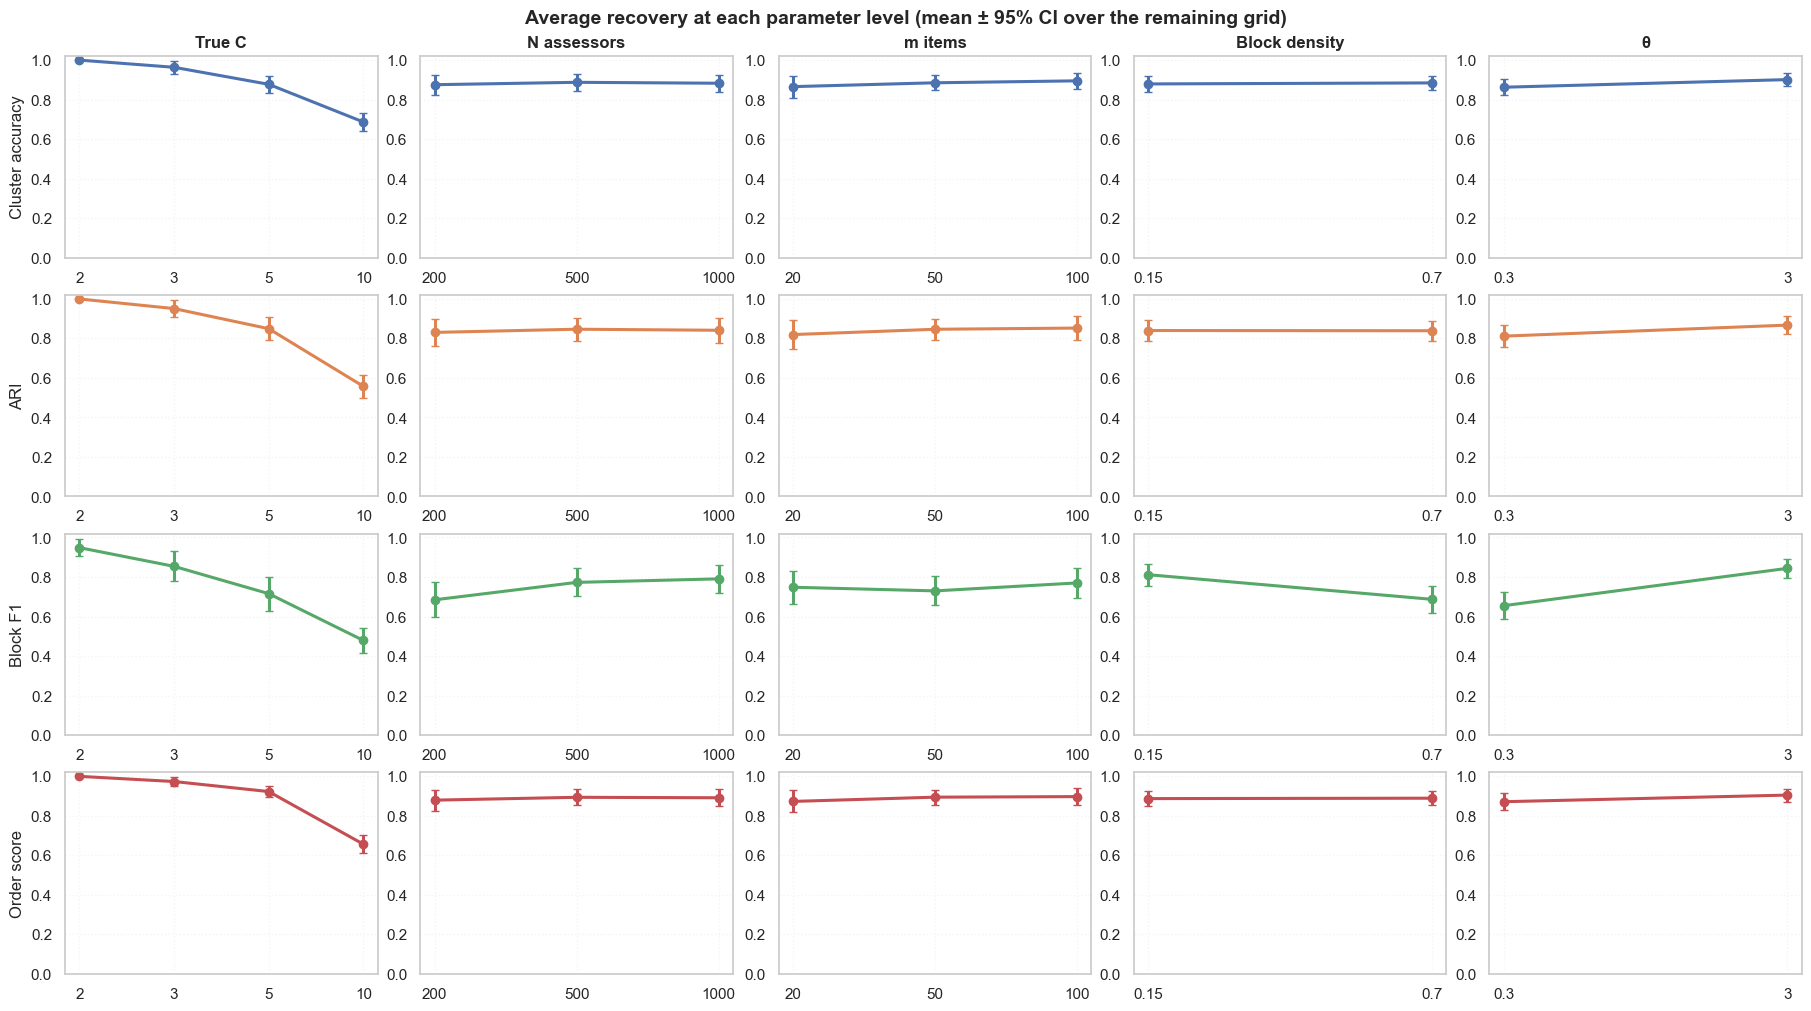

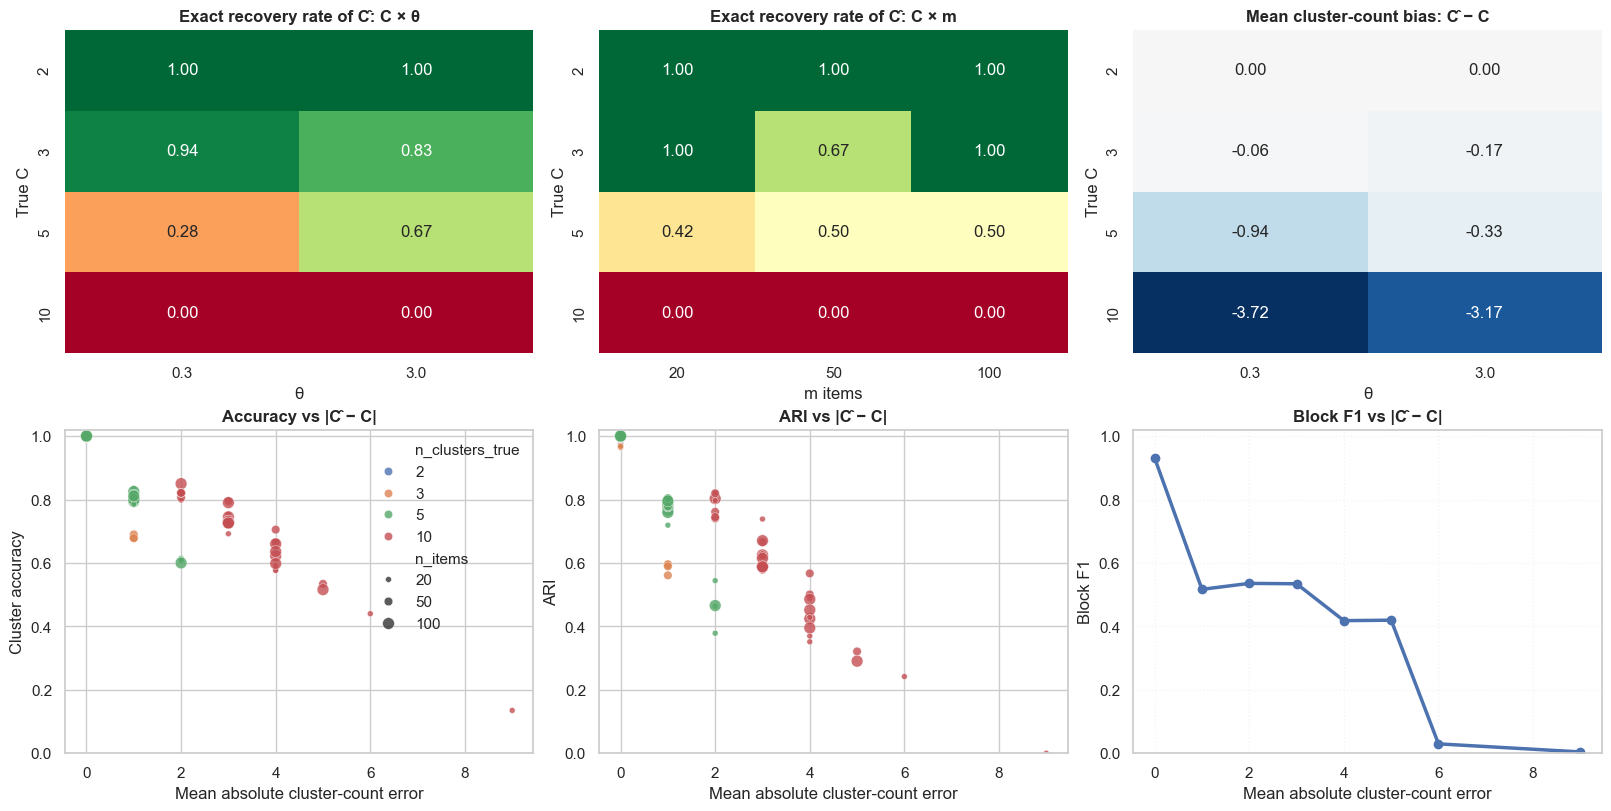

In [76]:
display(summary_df[summary_cols].round(3))

print('Best scenarios by accuracy')
display(summary_df.sort_values(metric_mean_col('aligned_cluster_accuracy'), ascending=False)[summary_cols].head(10).round(3))

print('Worst scenarios by accuracy')
display(summary_df.sort_values(metric_mean_col('aligned_cluster_accuracy'), ascending=True)[summary_cols].head(10).round(3))

cluster_df = add_cluster_count_diagnostics(trial_df, summary_df)

show_parameter_grid(metadata, summary_df)
display_main_effect_tables(summary_df)
display_cluster_count_impact(cluster_df)
plot_main_effects(summary_df)
plot_cluster_count_diagnostics(cluster_df)

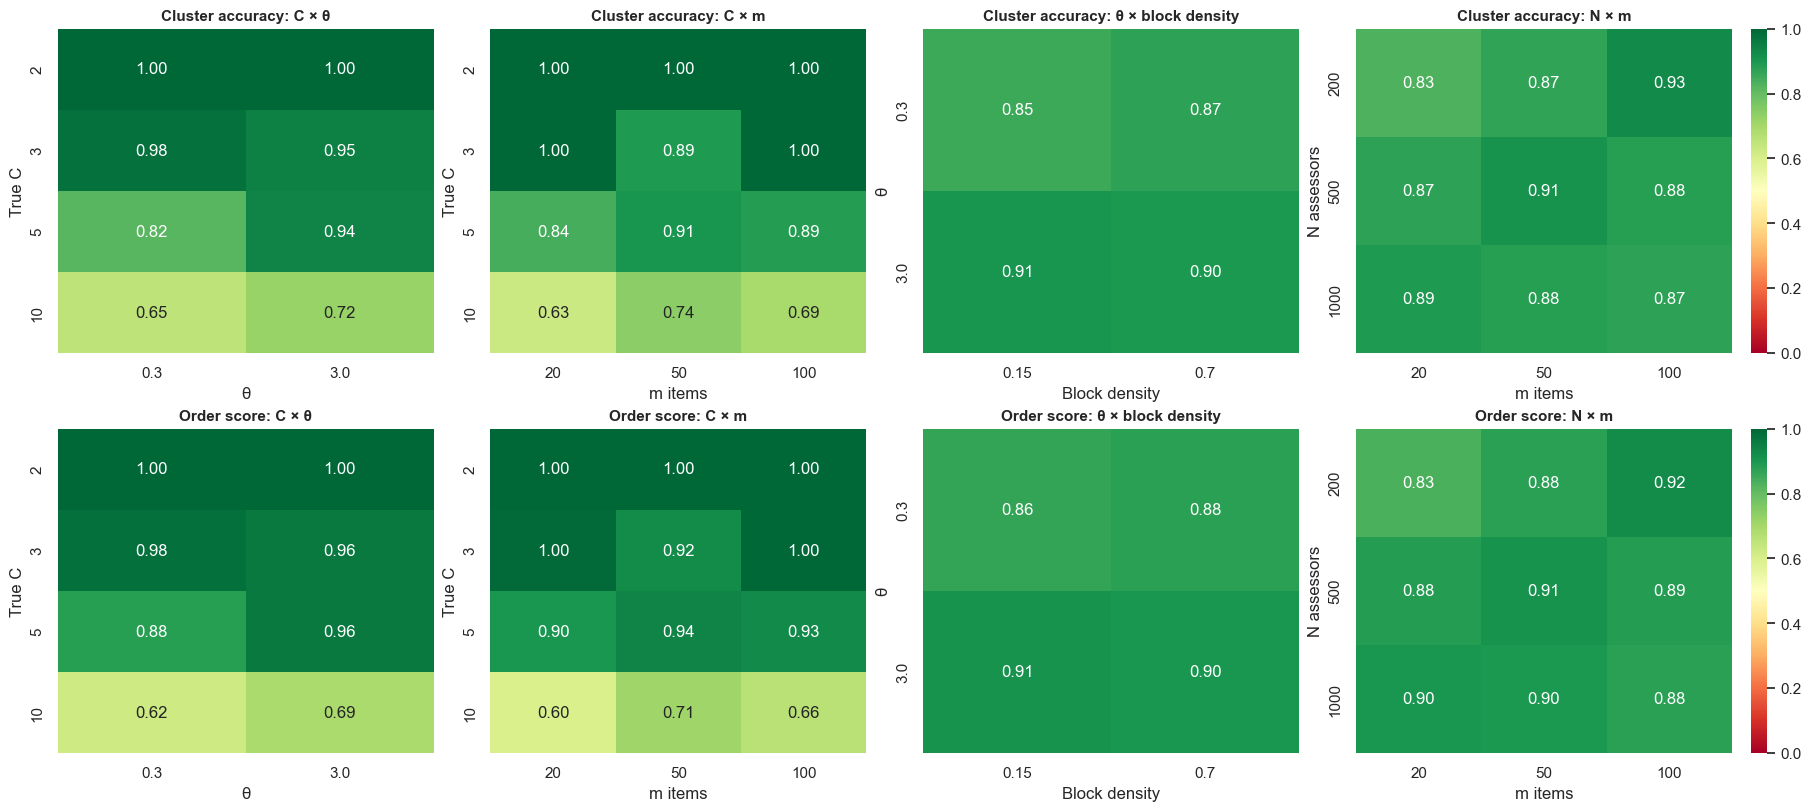

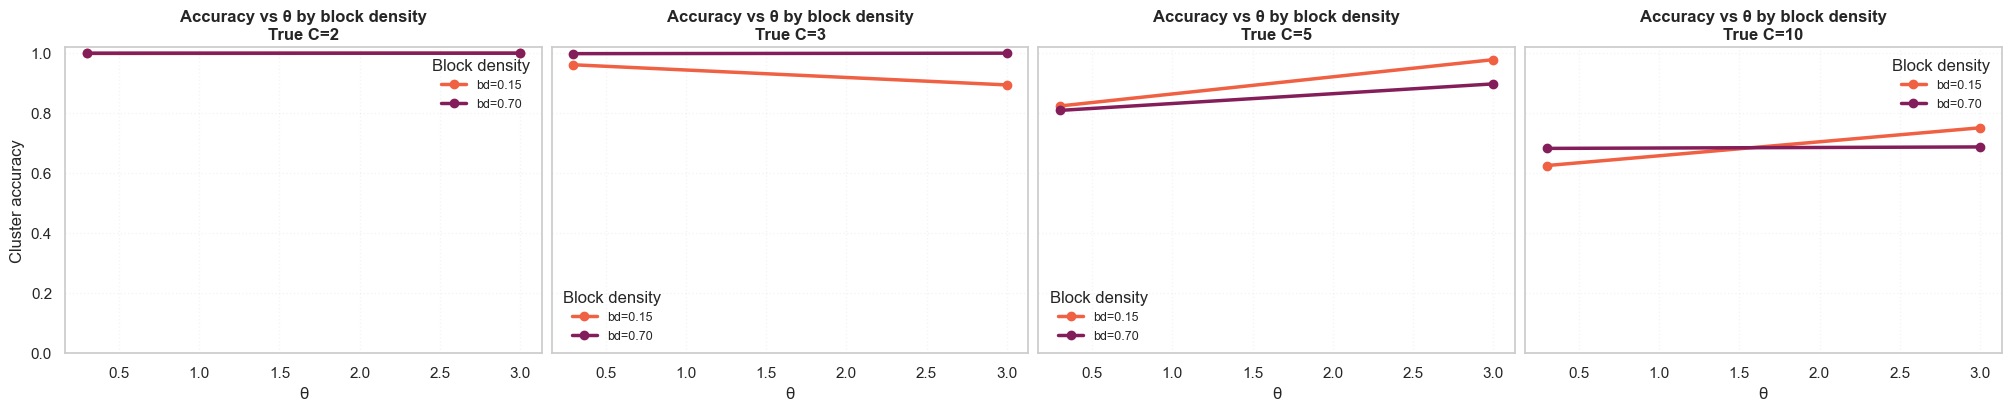

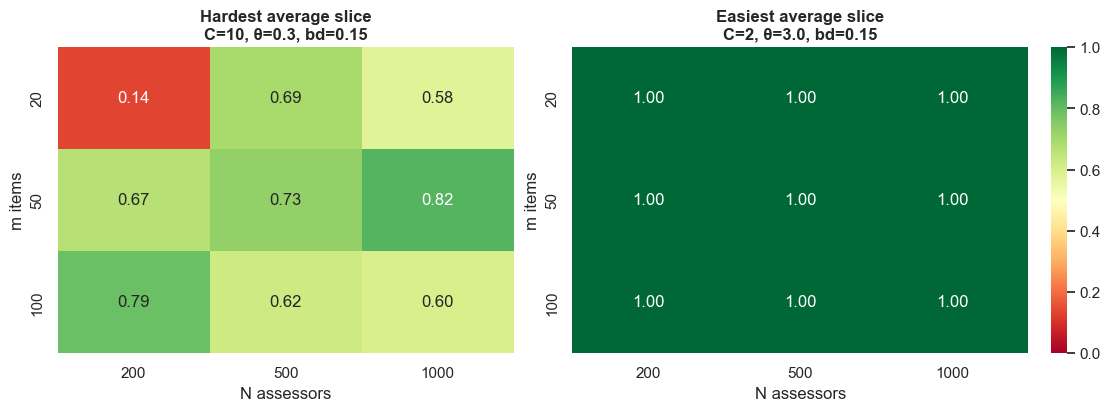

Scenarios with mean accuracy below 0.80


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,aligned_cluster_accuracy_mean,adjusted_rand_index_mean,weighted_normalized_kemeny_p_half_mean,weighted_same_block_f1_mean,weighted_block_count_error_mean
40,c3_n200_m50_bd0p15_theta0p3,3,200,50,0.15,0.3,0.680,0.593,0.244,0.400,10.310
42,c3_n200_m50_bd0p15_theta3p0,3,200,50,0.15,3.0,0.680,0.561,0.227,0.395,13.250
54,c3_n500_m50_bd0p15_theta3p0,3,500,50,0.15,3.0,0.690,0.596,0.200,0.409,10.590
66,c3_n1000_m50_bd0p15_theta3p0,3,1000,50,0.15,3.0,0.678,0.589,0.228,0.394,8.408
72,c5_n200_m20_bd0p15_theta0p3,5,200,20,0.15,0.3,0.615,0.378,0.192,0.561,3.955
84,c5_n500_m20_bd0p15_theta0p3,5,500,20,0.15,0.3,0.612,0.544,0.271,0.467,4.110
92,c5_n500_m100_bd0p15_theta0p3,5,500,100,0.15,0.3,0.794,0.766,0.147,0.609,11.742
96,c5_n1000_m20_bd0p15_theta0p3,5,1000,20,0.15,0.3,0.785,0.719,0.127,0.733,2.282
85,c5_n500_m20_bd0p70_theta0p3,5,500,20,0.70,0.3,0.608,0.464,0.242,0.394,3.354
93,c5_n500_m100_bd0p70_theta0p3,5,500,100,0.70,0.3,0.798,0.759,0.119,0.364,10.468


In [77]:
plot_interaction_heatmaps(summary_df)
plot_theta_density_slices(summary_df)
plot_extreme_nm_slices(summary_df)

BREAK_THRESHOLD = 0.8
break_df = failure_table(summary_df, metric_key='aligned_cluster_accuracy', threshold=BREAK_THRESHOLD)

print(f'Scenarios with mean accuracy below {BREAK_THRESHOLD:.2f}')
display(break_df.round(3))

This section re-runs the worst scenarios from the current simulation output using a longer chain and annealing during burn-in. The goal is to check whether some of the poor recovery was due to insufficient mixing rather than intrinsic difficulty.

In [ ]:
followup_df = rerun_worst_scenarios(
    summary_df,
    trial_df,
    n_cases=4,
    n_iter=16000,
    burn_in=10000,
    thin=20,
    n_restarts=4,
    use_annealing=True,
    temp_min=0.1,
    temp_max=1.0,
)

followup_display = followup_df[[
    'scenario', 'C', 'N', 'm_items', 'block_density', 'theta',
    'baseline_accuracy', 'rerun_accuracy', 'delta_accuracy',
    'baseline_ari', 'rerun_ari', 'delta_ari',
    'baseline_block_f1', 'rerun_block_f1', 'delta_block_f1',
    'baseline_pred_clusters', 'rerun_pred_clusters', 'delta_pred_clusters',
    'runtime_seconds',
]].round(3)

display(followup_display)
print('Mean deltas across rerun cases:')
display(followup_df[[c for c in followup_df.columns if c.startswith('delta_')]].mean().to_frame('mean_delta').T.round(3))
plot_followup_comparison(followup_df)


This check keeps the original simulation budget and only switches annealing on. That isolates whether the gain came from annealing itself rather than from the longer run.

In [ ]:
base_n_iter = int(summary_df['n_iter'].iloc[0])
base_burn_in = int(summary_df['burn_in'].iloc[0])
base_thin = int(summary_df['thin'].iloc[0])
base_restarts = int(summary_df['n_restarts'].iloc[0])

anneal_only_df = rerun_worst_scenarios(
    summary_df,
    trial_df,
    n_cases=4,
    n_iter=base_n_iter,
    burn_in=base_burn_in,
    thin=base_thin,
    n_restarts=base_restarts,
    use_annealing=True,
    temp_min=0.1,
    temp_max=1.0,
)

anneal_only_display = anneal_only_df[[
    'scenario', 'baseline_accuracy', 'rerun_accuracy', 'delta_accuracy',
    'baseline_ari', 'rerun_ari', 'delta_ari',
    'baseline_block_f1', 'rerun_block_f1', 'delta_block_f1',
    'baseline_pred_clusters', 'rerun_pred_clusters', 'delta_pred_clusters',
]].round(3)

print('Annealing only, keeping the original iteration budget')
display(anneal_only_display)

ablation_df = pd.DataFrame([
    summarize_ablation('Annealing only', anneal_only_df),
    summarize_ablation('Longer + annealed', followup_df),
]).round(3)

print('Average gain across the same worst scenarios')
display(ablation_df)
plot_ablation_summary(ablation_df)


This section fixes one difficult synthetic scenario and re-fits the model over a range of iteration budgets. The goal is to identify the point after which the performance is essentially unchanged.

## Single-cluster block-density recovery

This section examines how well the model recovers the true number of blocks (and overall ordering) as a function of **block density** for a single-cluster model (C=1).

**Design:**
- Block density swept from 0.00 (all items in one block) to 1.00 (fully strict ranking)
- `n_assessors` ∈ {10, 20, 50, 100} — deliberately small to stress the low-data regime
- `n_items` ∈ {10, 16, 24}
- θ ∈ {0.1, 0.5, 1.0, 3.0} — from near-uniform to strong signal

**Metrics shown:**
- **Number of blocks** — true (dotted black) vs. predicted; colour = N, line style = θ
- **Normalized Kemeny distance** — ordering error between true and predicted weak consensus

In [5]:
import importlib
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Make sure the workspace root is on the path
ROOT = Path(".").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import _single_cluster_bd_plots as scbd
importlib.reload(scbd)

# ── Load the most recent single_cluster_bd run ──────────────────────────────
run_dir = scbd.latest_run_dir(Path("simulation_recovery_runs"))
print(f"Run directory: {run_dir}")
results = scbd.load_results(run_dir)
rows = [scbd.extract_row(r) for r in results]
print(f"Scenarios loaded: {len(rows)}")

Run directory: simulation_recovery_runs\recovery_single_cluster_bd_20260421_131122
Scenarios loaded: 336


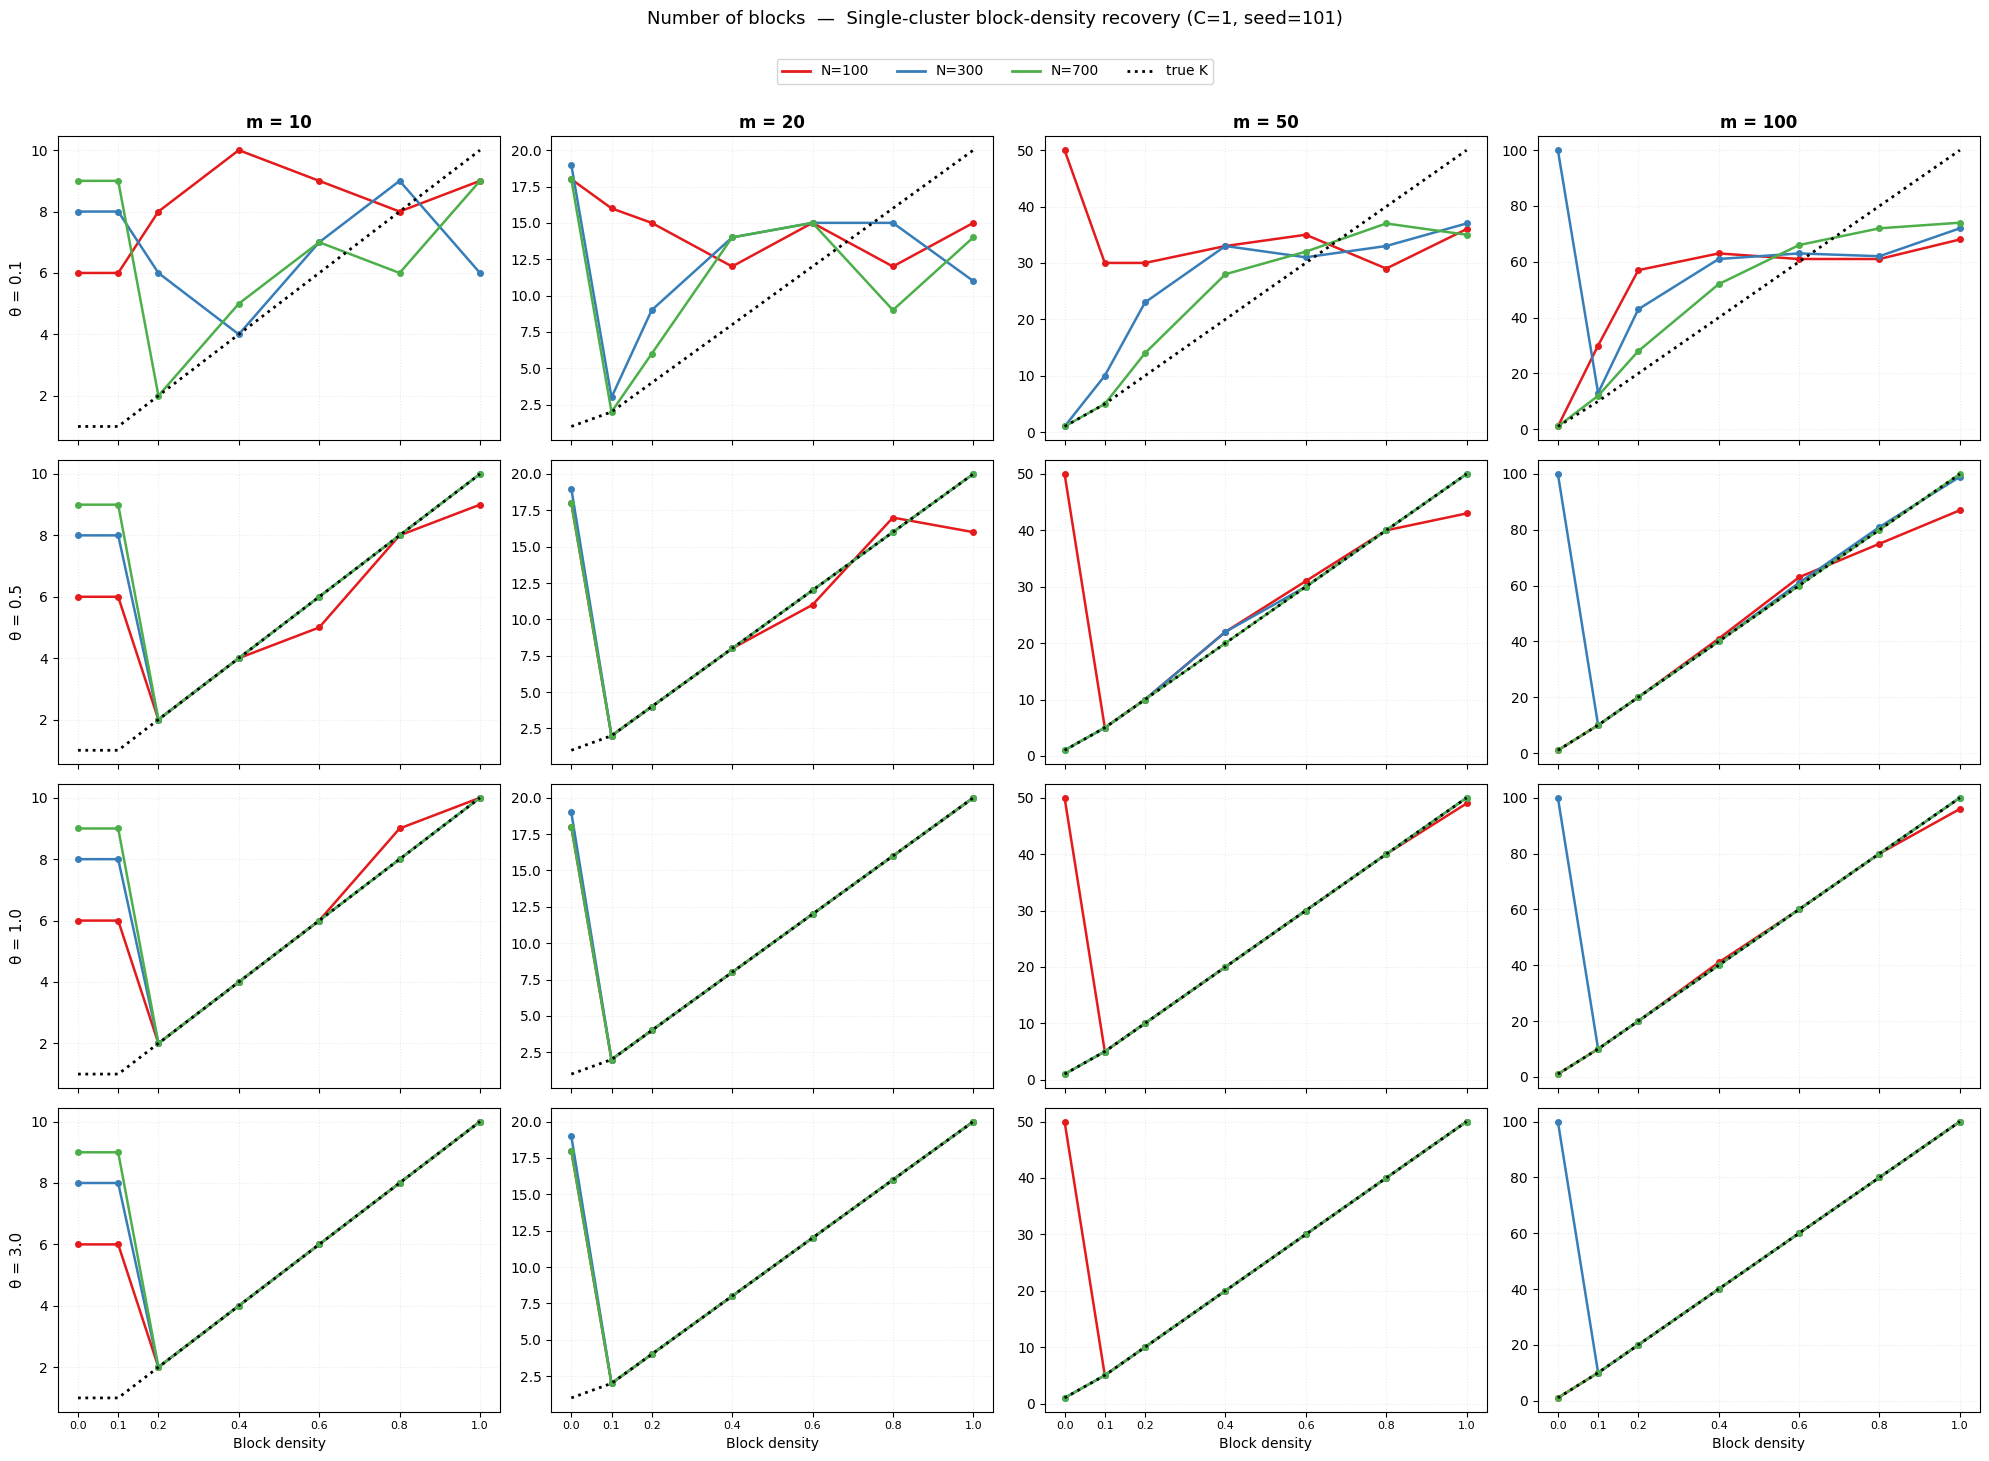

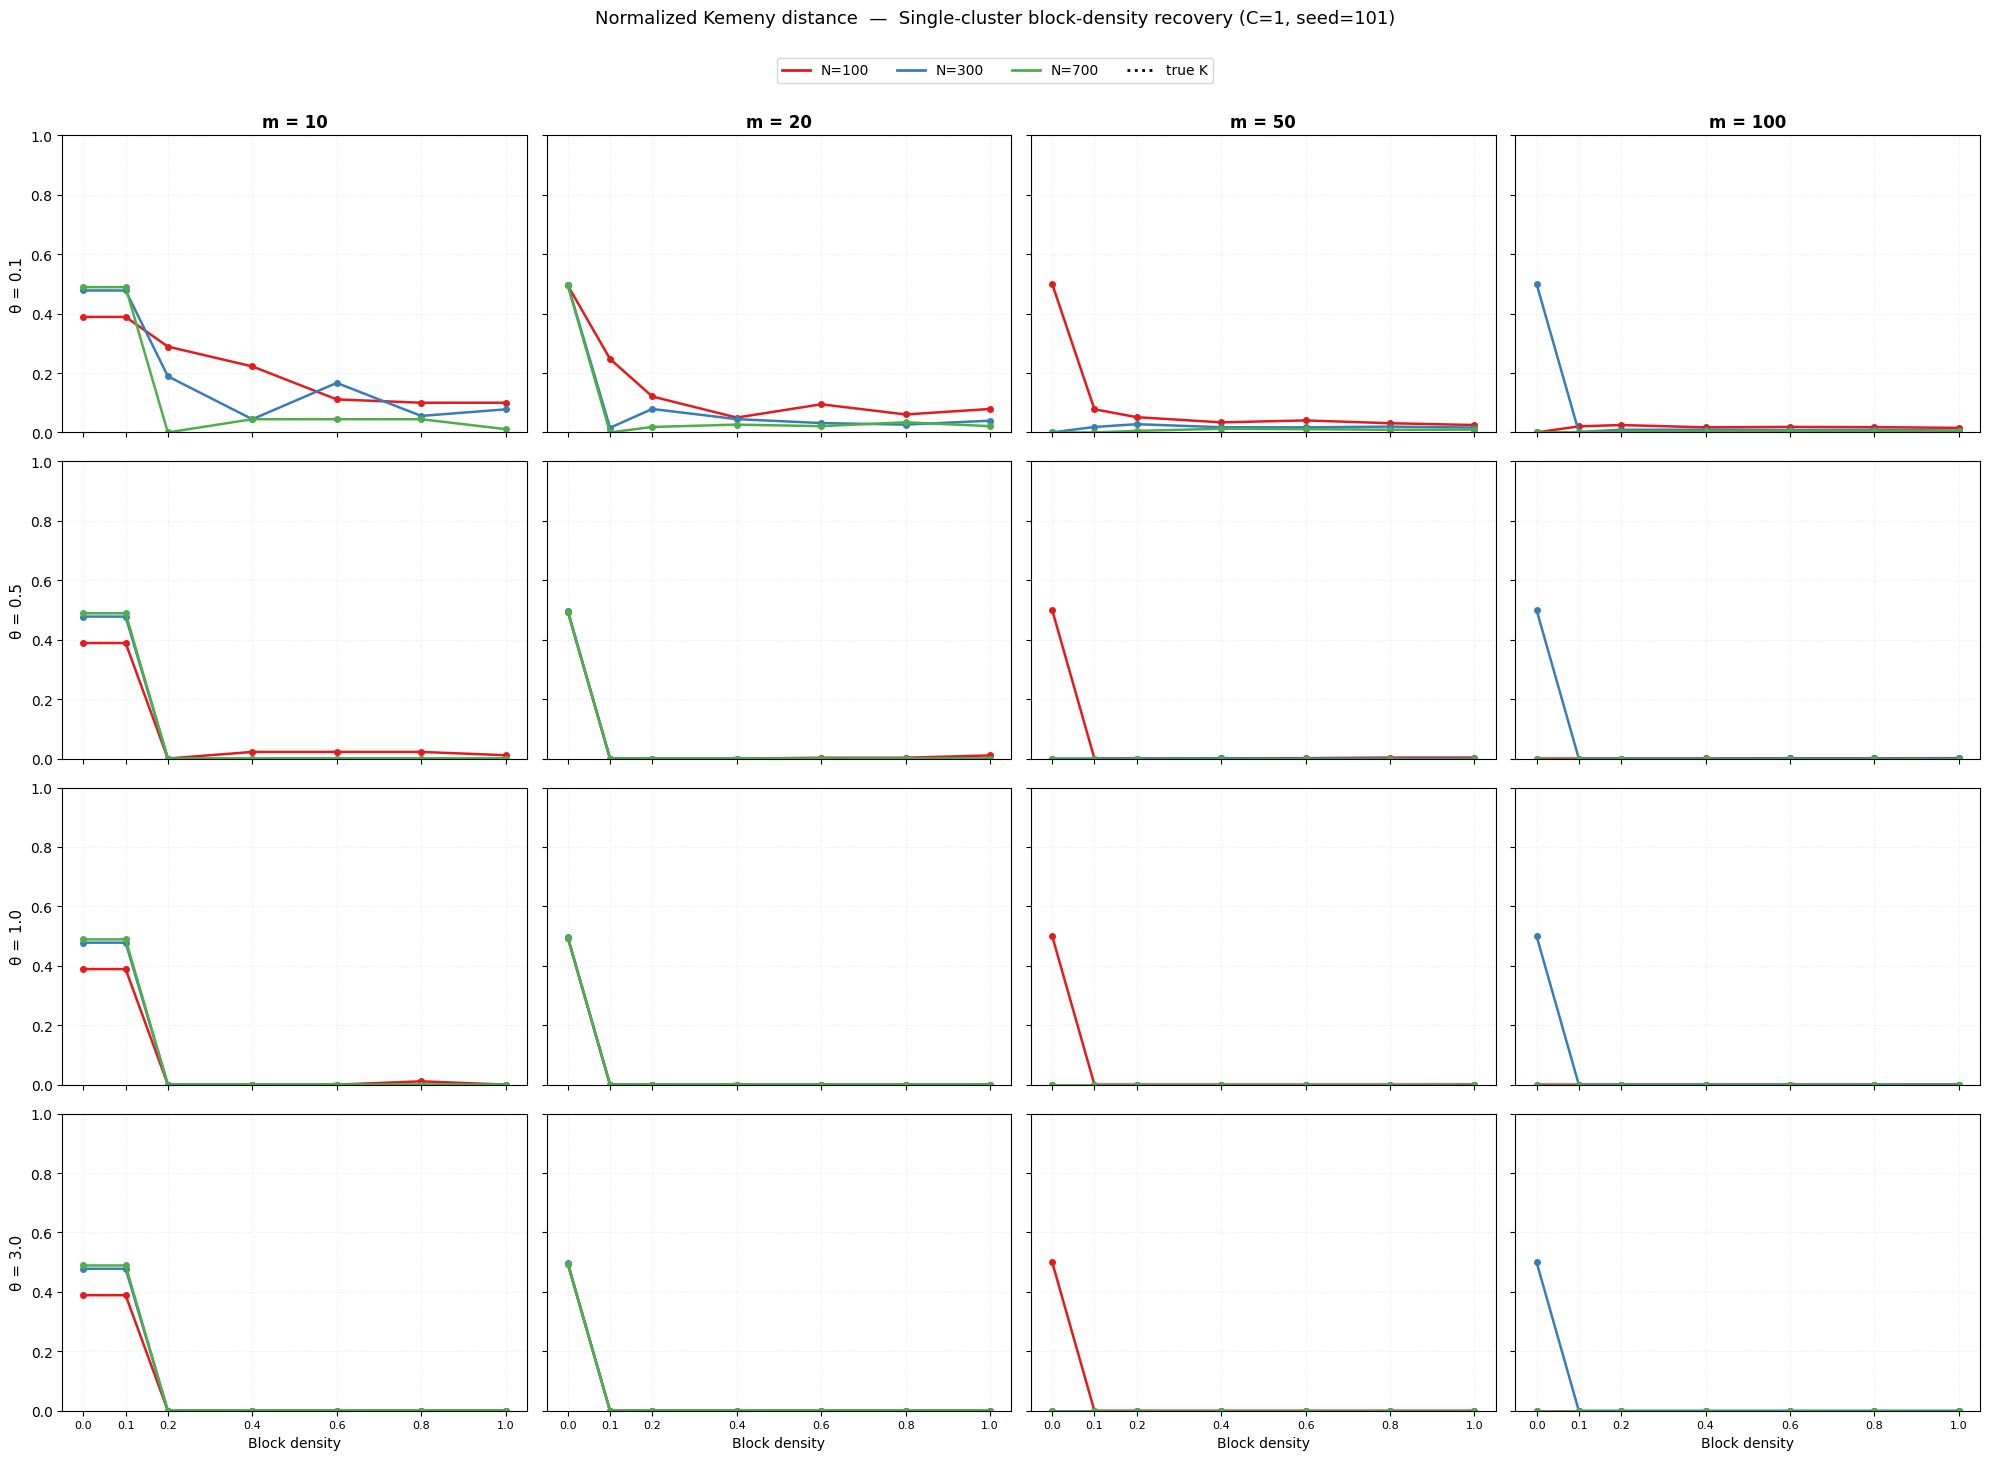

In [7]:
grid = scbd._build_grid(rows)

METRICS_PLOT = [
    ("block_count", "Number of blocks"),
    ("norm_kemeny",  "Normalized Kemeny distance"),
]
N_ITEMS_VALUES    = scbd.N_ITEMS_VALUES    # columns
THETA_VALUES      = scbd.THETA_VALUES      # rows within each metric figure
N_ASSESSORS_VALUES = scbd.N_ASSESSORS_VALUES
BLOCK_DENSITIES   = scbd.BLOCK_DENSITIES
bd_x = list(BLOCK_DENSITIES)

# Layout: one figure per metric; rows = theta, cols = n_items
# Each subplot has 3 lines (one per N_assessors) → easy to read
for metric_key, metric_label in METRICS_PLOT:
    n_rows = len(THETA_VALUES)
    n_cols = len(N_ITEMS_VALUES)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5.0 * n_cols, 3.5 * n_rows),
        sharex=True,
        sharey=(metric_key != "block_count"),
    )

    for row_idx, theta in enumerate(THETA_VALUES):
        for col_idx, n_items in enumerate(N_ITEMS_VALUES):
            ax = axes[row_idx][col_idx]

            for n_assessors in N_ASSESSORS_VALUES:
                color = scbd._N_COLORS[n_assessors]
                label = scbd._N_LABELS[n_assessors]

                if metric_key == "block_count":
                    true_vals, pred_vals = [], []
                    for bd in BLOCK_DENSITIES:
                        r = grid.get((n_items, n_assessors, theta, bd))
                        true_vals.append(r["true_n_blocks"] if r else float("nan"))
                        pred_vals.append(r["pred_n_blocks"] if r else float("nan"))
                    if n_assessors == N_ASSESSORS_VALUES[0]:
                        ax.plot(bd_x, true_vals, color="black", lw=2, ls=":", zorder=5)
                    ax.plot(bd_x, pred_vals, color=color, lw=1.8, marker="o", ms=4, label=label)
                else:
                    vals = [
                        grid[(n_items, n_assessors, theta, bd)][metric_key]
                        if (n_items, n_assessors, theta, bd) in grid else float("nan")
                        for bd in BLOCK_DENSITIES
                    ]
                    ax.plot(bd_x, vals, color=color, lw=1.8, marker="o", ms=4, label=label)
                    ax.set_ylim(0, 1.0)

            if row_idx == 0:
                ax.set_title(f"m = {n_items}", fontsize=12, fontweight="bold")
            if col_idx == 0:
                ax.set_ylabel(f"θ = {theta}", fontsize=11)
            if row_idx == n_rows - 1:
                ax.set_xlabel("Block density", fontsize=10)
            ax.set_xticks(bd_x)
            ax.tick_params(axis="x", labelsize=8)
            ax.grid(alpha=0.25, linestyle=":")

    # Legend: N_assessors colours + true K
    handles = [
        mlines.Line2D([], [], color=scbd._N_COLORS[n], lw=2, label=scbd._N_LABELS[n])
        for n in N_ASSESSORS_VALUES
    ]
    handles.append(mlines.Line2D([], [], color="black", lw=2, ls=":", label="true K"))

    fig.legend(handles=handles, loc="upper center", ncol=len(handles),
               bbox_to_anchor=(0.5, 1.01), fontsize=10, frameon=True)
    fig.suptitle(
        f"{metric_label}  —  Single-cluster block-density recovery (C=1, seed=101)",
        fontsize=13, y=1.04,
    )
    fig.tight_layout()
    plt.show()


## Large OAT simulation — Random initialisation (no spectral pre-processing)

Same OAT design as the description below, but with a **random/trivial warm start** (`init_clusters_default`):

- **Block structure:** consecutive-pair blocks `[(0,1), (2,3), …]` — neutral, no Borda ordering
- **Cluster assignments $z^{(0)}$:** shuffled round-robin over $k = 2 C_\text{true}$ clusters (over-saturated)

The MCMC Gibbs moves then merge/split blocks and re-assign rankings from scratch.  
This is the hardest baseline: no information from the data is used to warm-start the chain.

| Axis | Values swept | Default |
|------|-------------|---------|
| True clusters $C$ | 1, 2, 5, 10, 15, 20 | 5 |
| Assessors $N$ | 20, 50, 100, 200, 500, 1 000 | 200 |
| Items $m$ | 5, 10, 20, 50, 100 | 20 |
| Block density | 0.0, 0.2, 0.4, 0.6, 0.8, 1.0 | 0.4 |
| Dispersion $\theta$ | 0.01, 0.1, 0.5, 1.0, 2.0, 4.0 | 1.0 |

3 seeds × 27 base scenarios = **81 total runs**.  
Metrics: cluster accuracy, ARI, block F1, order score, and θ recovery.

In [ ]:
# ── Load large_oat (random-init) run ─────────────────────────────────────────
# Set to a specific directory name to pin a run, or None to auto-detect latest.
LARGE_OAT_RUN_NAME = None   # e.g. 'recovery_large_oat_20260422_102147'

oat_run_dir = RUNS_DIR / LARGE_OAT_RUN_NAME if LARGE_OAT_RUN_NAME else latest_large_oat_run()
oat_metadata, oat_results = load_run(oat_run_dir)
oat_trial_df   = flatten_results(oat_results)
oat_summary_df = aggregate_trials(oat_trial_df)

print(f"Run directory : {oat_run_dir}")
print(f"Results loaded: {len(oat_results)}")
print(f"Trial rows    : {len(oat_trial_df)}")
print(f"Scenario rows : {len(oat_summary_df)}")

oat_summary_df.head()


Run directory : simulation_recovery_runs\recovery_large_oat_20260422_102147
Results loaded: 81
Trial rows    : 81
Scenario rows : 27


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,fit_n_clusters,n_iter,burn_in,thin,n_restarts,aligned_cluster_accuracy_mean,aligned_cluster_accuracy_std,aligned_cluster_accuracy_count,adjusted_rand_index_mean,adjusted_rand_index_std,adjusted_rand_index_count,weighted_normalized_kemeny_p_half_mean,weighted_normalized_kemeny_p_half_std,weighted_normalized_kemeny_p_half_count,weighted_same_block_f1_mean,weighted_same_block_f1_std,weighted_same_block_f1_count,weighted_block_count_error_mean,weighted_block_count_error_std,weighted_block_count_error_count,weighted_strict_inversions_mean,weighted_strict_inversions_std,weighted_strict_inversions_count,n_pred_clusters_mean,n_pred_clusters_std,n_pred_clusters_count,runtime_seconds_mean,runtime_seconds_std,runtime_seconds_count
0,c1_n200_m20_bd0p40_theta1p0,1,200,20,0.4,1.0,2,8000,5000,20,3,1.000000,0.000000,3,1.000000,0.000000,3,0.000000,0.000000,3,1.000000,0.000000,3,0.000000,0.000000,3,0.000000,0.000000,3,1.000000,0.000000,3,5.548097,0.033467,3
1,c2_n200_m20_bd0p40_theta1p0,2,200,20,0.4,1.0,4,8000,5000,20,3,1.000000,0.000000,3,1.000000,0.000000,3,0.000000,0.000000,3,1.000000,0.000000,3,0.000000,0.000000,3,0.000000,0.000000,3,2.000000,0.000000,3,8.806712,0.658934,3
2,c5_n20_m20_bd0p40_theta1p0,5,20,20,0.4,1.0,10,8000,5000,20,3,0.650000,0.180278,3,0.494840,0.287750,3,0.402719,0.201171,3,0.289951,0.181253,3,6.383333,1.957251,3,71.583333,38.815536,3,2.666667,1.154701,3,12.843774,0.937832,3
3,c5_n50_m20_bd0p40_theta1p0,5,50,20,0.4,1.0,10,8000,5000,20,3,0.673333,0.190088,3,0.551050,0.313163,3,0.376211,0.212828,3,0.372885,0.172463,3,5.320000,2.113481,3,66.726667,41.075094,3,3.000000,1.000000,3,15.157685,4.615441,3
4,c5_n100_m20_bd0p40_theta1p0,5,100,20,0.4,1.0,10,8000,5000,20,3,0.820000,0.180000,3,0.771686,0.232420,3,0.210009,0.204060,3,0.643485,0.275382,3,3.496667,2.303505,3,37.183333,37.925604,3,4.000000,1.000000,3,20.738527,6.087527,3


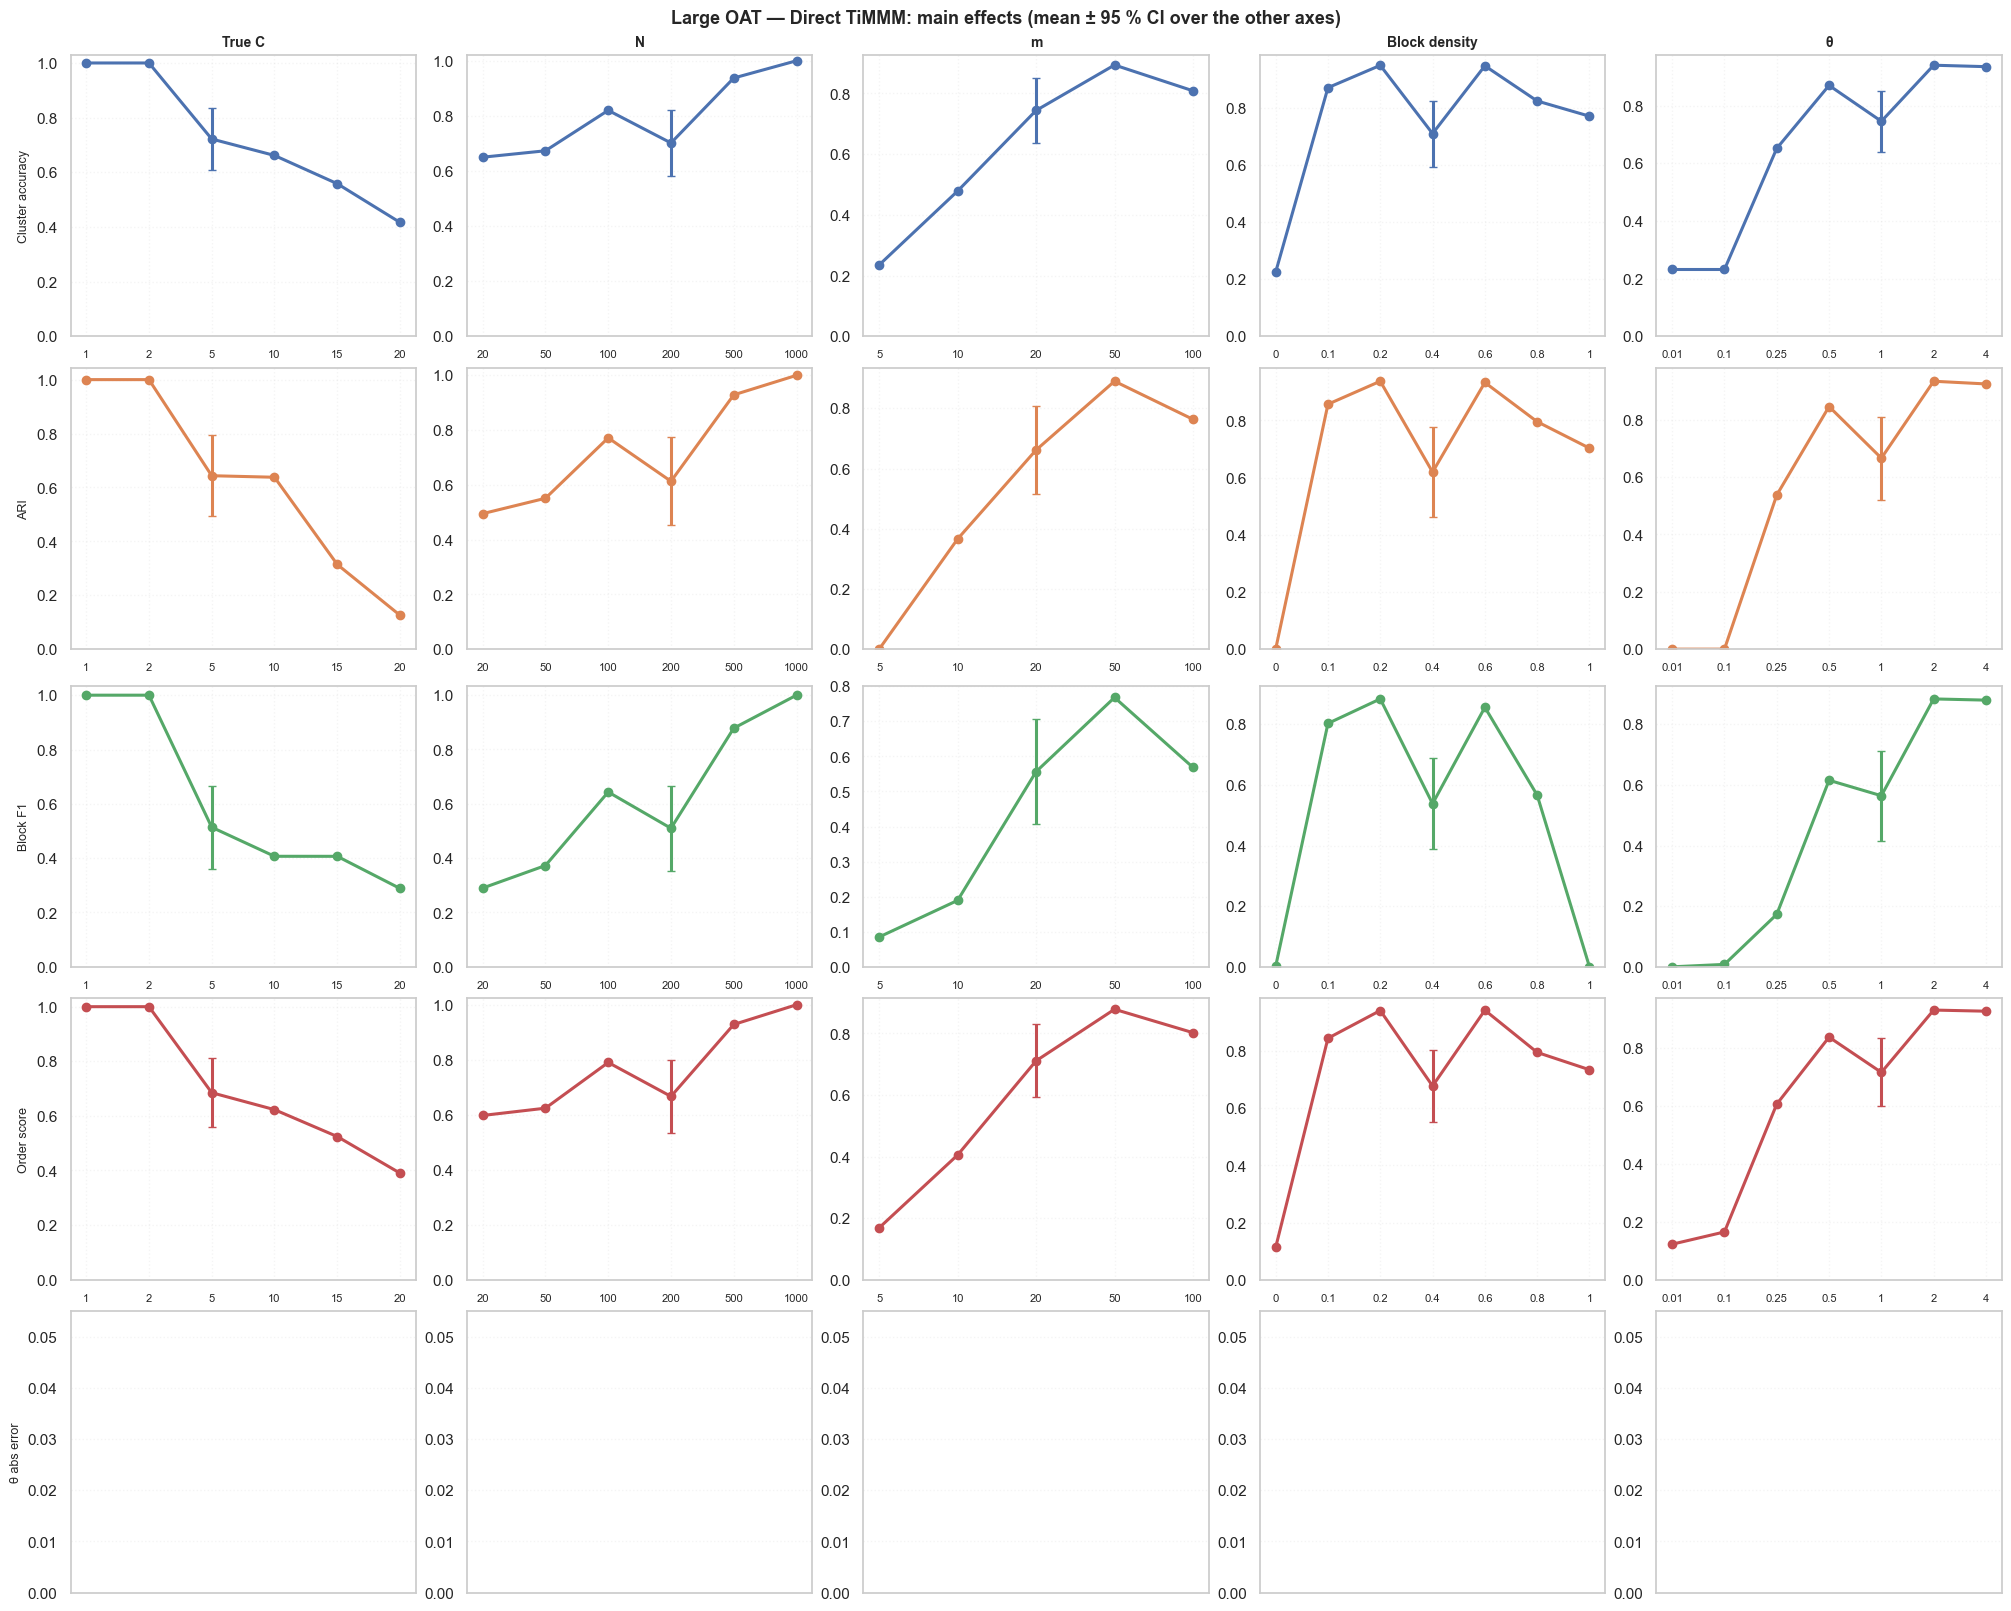

In [ ]:
# ── OAT main-effects plot (random-init) ──────────────────────────────────────
oat_effects = _oat_main_effects(oat_summary_df)

metric_order = [label for _, label, _ in OAT_METRIC_SPECS]
colors       = sns.color_palette('deep', len(metric_order))

fig, axes = plt.subplots(
    len(metric_order), len(OAT_PARAM_SPECS),
    figsize=(20, 3.2 * len(metric_order)),
    constrained_layout=True,
)

for col_idx, (_, param_label) in enumerate(OAT_PARAM_SPECS):
    subset = oat_effects[oat_effects['parameter'] == param_label].copy()
    for row_idx, metric_label in enumerate(metric_order):
        ax = axes[row_idx, col_idx]
        metric_df = subset[subset['metric'] == metric_label].sort_values('level')
        x = np.arange(len(metric_df))
        ax.errorbar(
            x, metric_df['mean'], yerr=1.96 * metric_df['se'],
            marker='o', linewidth=2.2, capsize=3, color=colors[row_idx],
        )
        ax.set_xticks(x)
        ax.set_xticklabels(metric_df['level_label'], fontsize=8)
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2, linestyle=':')
        if col_idx == 0:
            ax.set_ylabel(metric_label, fontsize=9)
        if row_idx == 0:
            ax.set_title(param_label, fontsize=10, fontweight='bold')

fig.suptitle(
    'Large OAT — Direct TiMMM: main effects (mean ± 95 % CI over the other axes)',
    fontsize=13, fontweight='bold',
)
plt.show()


In [10]:
# ── θ recovery: separate focus plot ───────────────────────────────────────────
# Show how well theta is recovered as a function of each parameter axis.
# Left panel: abs error vs axis;  Right panel: scatter true θ vs predicted θ.

theta_col = 'weighted_theta_abs_error_mean'
if theta_col not in oat_summary_df.columns:
    print(f"Column '{theta_col}' not found — run was likely produced before theta recovery was added.")
else:
    # ── 1. Mean abs error vs each axis ────────────────────────────────────────
    fig, axes = plt.subplots(1, len(OAT_PARAM_SPECS), figsize=(18, 3.8), constrained_layout=True)
    for ax, (param_key, param_label) in zip(axes, OAT_PARAM_SPECS):
        grp = oat_summary_df.groupby(param_key, sort=True, dropna=False)[theta_col].mean()
        x   = np.arange(len(grp))
        ax.bar(x, grp.values, color='#5588cc', alpha=0.8)
        ax.set_xticks(x)
        ax.set_xticklabels([_pretty_level(v) for v in grp.index], fontsize=8)
        ax.set_title(param_label, fontsize=10, fontweight='bold')
        ax.set_ylim(bottom=0)
        ax.grid(axis='y', alpha=0.3, linestyle=':')
        if ax is axes[0]:
            ax.set_ylabel('Mean |θ̂ − θ|', fontsize=9)
    fig.suptitle('θ recovery — mean absolute error by parameter axis', fontsize=12, fontweight='bold')
    plt.show()

    # ── 2. True θ vs mean |error| scatter ────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    sc = ax.scatter(
        oat_summary_df['theta'], oat_summary_df[theta_col],
        c=oat_summary_df['n_clusters_true'], cmap='viridis',
        alpha=0.7, s=40, edgecolors='none',
    )
    plt.colorbar(sc, ax=ax, label='True C')
    ax.set_xlabel('True θ', fontsize=10)
    ax.set_ylabel('Mean |θ̂ − θ|', fontsize=10)
    ax.set_title('θ recovery error vs true θ (colour = true C)', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.2, linestyle=':')
    plt.show()

    # ── 3. Summary table ──────────────────────────────────────────────────────
    theta_summary = (
        oat_summary_df.groupby('theta')[theta_col]
        .agg(['mean', 'std', 'count'])
        .rename(columns={'mean': 'mean |θ̂−θ|', 'std': 'std', 'count': 'n'})
        .round(4)
    )
    print("θ recovery by true θ:")
    display(theta_summary)


NameError: name 'oat_summary_df' is not defined

## Large OAT simulation — Spectral-clustering initialisation

Same OAT design as the random-init section, but the chain is **warm-started from spectral clustering** on the Kendall-agreement affinity matrix.

**Initialisation pipeline (per restart):**
1. Build an $N \times N$ Kendall-agreement affinity matrix from the generated rankings.
2. Apply spectral clustering with $k = 2 C_\text{true}$ (same over-saturation as the random run) to get starting assignments $z^{(0)}$.
3. Within each spectral group, build the initial block structure from the Borda-consensus ordering of items.
4. Run TiMMM MCMC from that warm start.

**Hypothesis:** Informed initialisation from the data should speed up mixing and improve recovery, especially at high $C$ or low $N$ where pure random restarts struggle to find the right partition.

In [ ]:
# ── Load large_oat_spectral run ───────────────────────────────────────────────
# Set to a specific directory name to pin a run, or None to auto-detect latest.
LARGE_OAT_SPECTRAL_RUN_NAME = None   # e.g. 'recovery_large_oat_spectral_20260422_120000'

spec_run_dir = RUNS_DIR / LARGE_OAT_SPECTRAL_RUN_NAME if LARGE_OAT_SPECTRAL_RUN_NAME else latest_large_oat_spectral_run()
spec_metadata, spec_results = load_run(spec_run_dir)
spec_trial_df   = flatten_results(spec_results)
spec_summary_df = aggregate_trials(spec_trial_df)

print(f"Run directory : {spec_run_dir}")
print(f"Results loaded: {len(spec_results)}")
print(f"Trial rows    : {len(spec_trial_df)}")
print(f"Scenario rows : {len(spec_summary_df)}")

spec_summary_df.head()


In [ ]:
# ── Main-effects plot — spectral-init run ─────────────────────────────────────
# Reuses _oat_main_effects and OAT_METRIC_SPECS / OAT_PARAM_SPECS defined above.

spec_effects = _oat_main_effects(spec_summary_df)

fig, axes = plt.subplots(
    len(OAT_METRIC_SPECS), len(OAT_PARAM_SPECS),
    figsize=(20, 3.2 * len(OAT_METRIC_SPECS)),
    constrained_layout=True,
)

for col_idx, (_, param_label) in enumerate(OAT_PARAM_SPECS):
    subset = spec_effects[spec_effects['parameter'] == param_label].copy()
    for row_idx, (_, metric_label, _) in enumerate(OAT_METRIC_SPECS):
        ax = axes[row_idx, col_idx]
        metric_df = subset[subset['metric'] == metric_label].sort_values('level')
        x = np.arange(len(metric_df))
        ax.errorbar(
            x, metric_df['mean'], yerr=1.96 * metric_df['se'],
            marker='o', linewidth=2.2, capsize=3, color=colors[row_idx],
        )
        ax.set_xticks(x)
        ax.set_xticklabels(metric_df['level_label'], fontsize=8)
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2, linestyle=':')
        if col_idx == 0:
            ax.set_ylabel(metric_label, fontsize=9)
        if row_idx == 0:
            ax.set_title(param_label, fontsize=10, fontweight='bold')

fig.suptitle(
    'Large OAT — Spectral-init TiMMM: main effects (mean ± 95 % CI over the other axes)',
    fontsize=13, fontweight='bold',
)
plt.show()


In [ ]:
# ── Head-to-head comparison: Direct TiMMM vs Spectral-init TiMMM ─────────────
# Merge on scenario identity (base_scenario) and compare each metric side by side.

COMPARE_METRICS = [
    ('aligned_cluster_accuracy_mean',          'Cluster accuracy', False),
    ('adjusted_rand_index_mean',               'ARI',              False),
    ('weighted_same_block_f1_mean',            'Block F1',         False),
    ('weighted_normalized_kemeny_p_half_mean', 'Order score',      True),
    ('weighted_theta_abs_error_mean',          'θ abs error',      False),
]

merge_keys = ['base_scenario', 'n_clusters_true', 'n_assessors', 'n_items', 'block_density', 'theta']

cmp = oat_summary_df[merge_keys + [col for col, _, _ in COMPARE_METRICS]].merge(
    spec_summary_df[merge_keys + [col for col, _, _ in COMPARE_METRICS]],
    on=merge_keys,
    suffixes=('_direct', '_spectral'),
)

# ── 1. Scatter plots: direct vs spectral per metric ────────────────────────────
n_metrics = len(COMPARE_METRICS)
fig, axes = plt.subplots(1, n_metrics, figsize=(4.5 * n_metrics, 4.5), constrained_layout=True)

for ax, (col, label, invert) in zip(axes, COMPARE_METRICS):
    if col not in cmp.columns + ['%s_direct' % col, '%s_spectral' % col]:
        pass  # silently skip missing columns
    col_d = f'{col}_direct'
    col_s = f'{col}_spectral'
    if col_d not in cmp.columns or col_s not in cmp.columns:
        ax.set_visible(False)
        continue
    xd = 1.0 - cmp[col_d] if invert else cmp[col_d]
    xs = 1.0 - cmp[col_s] if invert else cmp[col_s]
    ax.scatter(xd, xs, alpha=0.5, s=25, color='#5588cc', edgecolors='none')
    lims = [min(xd.min(), xs.min()) - 0.02, max(xd.max(), xs.max()) + 0.02]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax.set_xlabel(f'Direct  ({label})', fontsize=9)
    ax.set_ylabel(f'Spectral-init  ({label})', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')

fig.suptitle('Scenario-level comparison: Direct vs Spectral-init (each point = one base scenario × seed)',
             fontsize=11, fontweight='bold')
plt.show()

# ── 2. Mean improvement by parameter axis ─────────────────────────────────────
print("\nMean Δ (spectral − direct) by axis:")
for col, label, invert in COMPARE_METRICS:
    col_d = f'{col}_direct'
    col_s = f'{col}_spectral'
    if col_d not in cmp.columns or col_s not in cmp.columns:
        continue
    if invert:
        delta = (1.0 - cmp[col_s]) - (1.0 - cmp[col_d])
    else:
        delta = cmp[col_s] - cmp[col_d]
    print(f"  {label:22s}  mean Δ = {delta.mean():+.4f}  (std = {delta.std():.4f})")

# ── 3. Per-C summary table ─────────────────────────────────────────────────────
rows = []
for col, label, invert in COMPARE_METRICS:
    col_d = f'{col}_direct'
    col_s = f'{col}_spectral'
    if col_d not in cmp.columns or col_s not in cmp.columns:
        continue
    if invert:
        delta = (1.0 - cmp[col_s]) - (1.0 - cmp[col_d])
    else:
        delta = cmp[col_s] - cmp[col_d]
    cmp[f'delta_{label}'] = delta

delta_cols = [f'delta_{label}' for _, label, _ in COMPARE_METRICS
              if f'{col}_direct' in cmp.columns for col, _, _ in [(_, _, _)] if col == _]
# simpler: grab all delta_ columns
delta_cols = [c for c in cmp.columns if c.startswith('delta_')]

by_c = cmp.groupby('n_clusters_true')[delta_cols].mean().round(4)
print("\nMean Δ (spectral − direct) by true C:")
display(by_c)


## TiMMM OAT — clean four-metric evaluation

Results from `_timmm_oat_study.py`: plain TiMMM with **no spectral pre-processing**, **no consensus clustering**, fitted with $k = 2 C_\text{true}$ clusters and default random initialisation.

**Metrics (four only):**

| Metric | Direction | Description |
|--------|-----------|-------------|
| Cluster ARI | ↑ better | ARI between true and predicted cluster assignments |
| Order distance | ↓ better | Normalised Kemeny distance between true and predicted weak-order consensuses (0 = perfect) |
| Block ARI | ↑ better | Cluster-size-weighted mean ARI of item→block-id memberships within matched cluster pairs |
| θ RMSE | ↓ better | $\sqrt{\sum_c w_c (\theta_\text{true} - \hat\theta_c)^2}$ over matched cluster pairs |

Runtime (seconds per scenario) is shown as a fifth row for computational context.

**OAT design:** same parameter grid and seeds as the `large_oat` baseline — directly comparable.

In [ ]:
# ── Load timmm_oat or timmm_spectral run ──────────────────────────────────────
# Set TIMMM_OAT_RUN_NAME to pin a specific run, or None to auto-detect.
# Set TIMMM_USE_SPECTRAL = True to load the spectral-init run instead.
TIMMM_OAT_RUN_NAME = None    # e.g. 'recovery_timmm_oat_20260422_111014'
TIMMM_USE_SPECTRAL = False   # True → recovery_timmm_spectral_*, False → recovery_timmm_oat_*

timmm_run_dir = (
    RUNS_DIR / TIMMM_OAT_RUN_NAME if TIMMM_OAT_RUN_NAME
    else latest_timmm_oat_run(spectral=TIMMM_USE_SPECTRAL)
)
_, timmm_results = load_run(timmm_run_dir)
timmm_trial_df   = flatten_timmm(timmm_results)
timmm_summary_df = aggregate_timmm(timmm_trial_df)

print(f"Run directory : {timmm_run_dir}")
print(f"Results loaded: {len(timmm_results)}")
print(f"Trial rows    : {len(timmm_trial_df)}")
print(f"Scenario rows : {len(timmm_summary_df)}")

timmm_summary_df.head()


Run directory : simulation_recovery_runs\recovery_timmm_oat_20260422_111103
Results loaded: 81
Trial rows    : 81
Scenario rows : 27


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,fit_n_clusters,cluster_ari_mean,cluster_ari_std,cluster_ari_count,order_distance_mean,order_distance_std,order_distance_count,block_ari_mean,block_ari_std,block_ari_count,theta_rmse_mean,theta_rmse_std,theta_rmse_count,runtime_seconds_mean,runtime_seconds_std,runtime_seconds_count
0,c1_n200_ni20_bd0p40_theta1p0,1,200,20,0.4,1.0,2,1.000000,0.000000,3,0.000000,0.000000,3,1.000000,0.000000,3,0.020355,0.016894,3,5.553759,0.007177,3
1,c2_n200_ni20_bd0p40_theta1p0,2,200,20,0.4,1.0,4,1.000000,0.000000,3,0.000000,0.000000,3,1.000000,0.000000,3,0.025953,0.012836,3,8.516027,1.112537,3
2,c5_n20_ni20_bd0p40_theta1p0,5,20,20,0.4,1.0,10,0.150412,0.130261,3,0.600702,0.025239,3,0.117877,0.077740,3,0.726083,0.087404,3,9.836209,1.851968,3
3,c5_n50_ni20_bd0p40_theta1p0,5,50,20,0.4,1.0,10,0.209170,0.181148,3,0.638561,0.110727,3,0.170617,0.147874,3,0.644295,0.177552,3,11.195569,1.760615,3
4,c5_n100_ni20_bd0p40_theta1p0,5,100,20,0.4,1.0,10,0.476082,0.267626,3,0.438026,0.199069,3,0.376722,0.181878,3,0.481281,0.153692,3,16.243562,4.669906,3


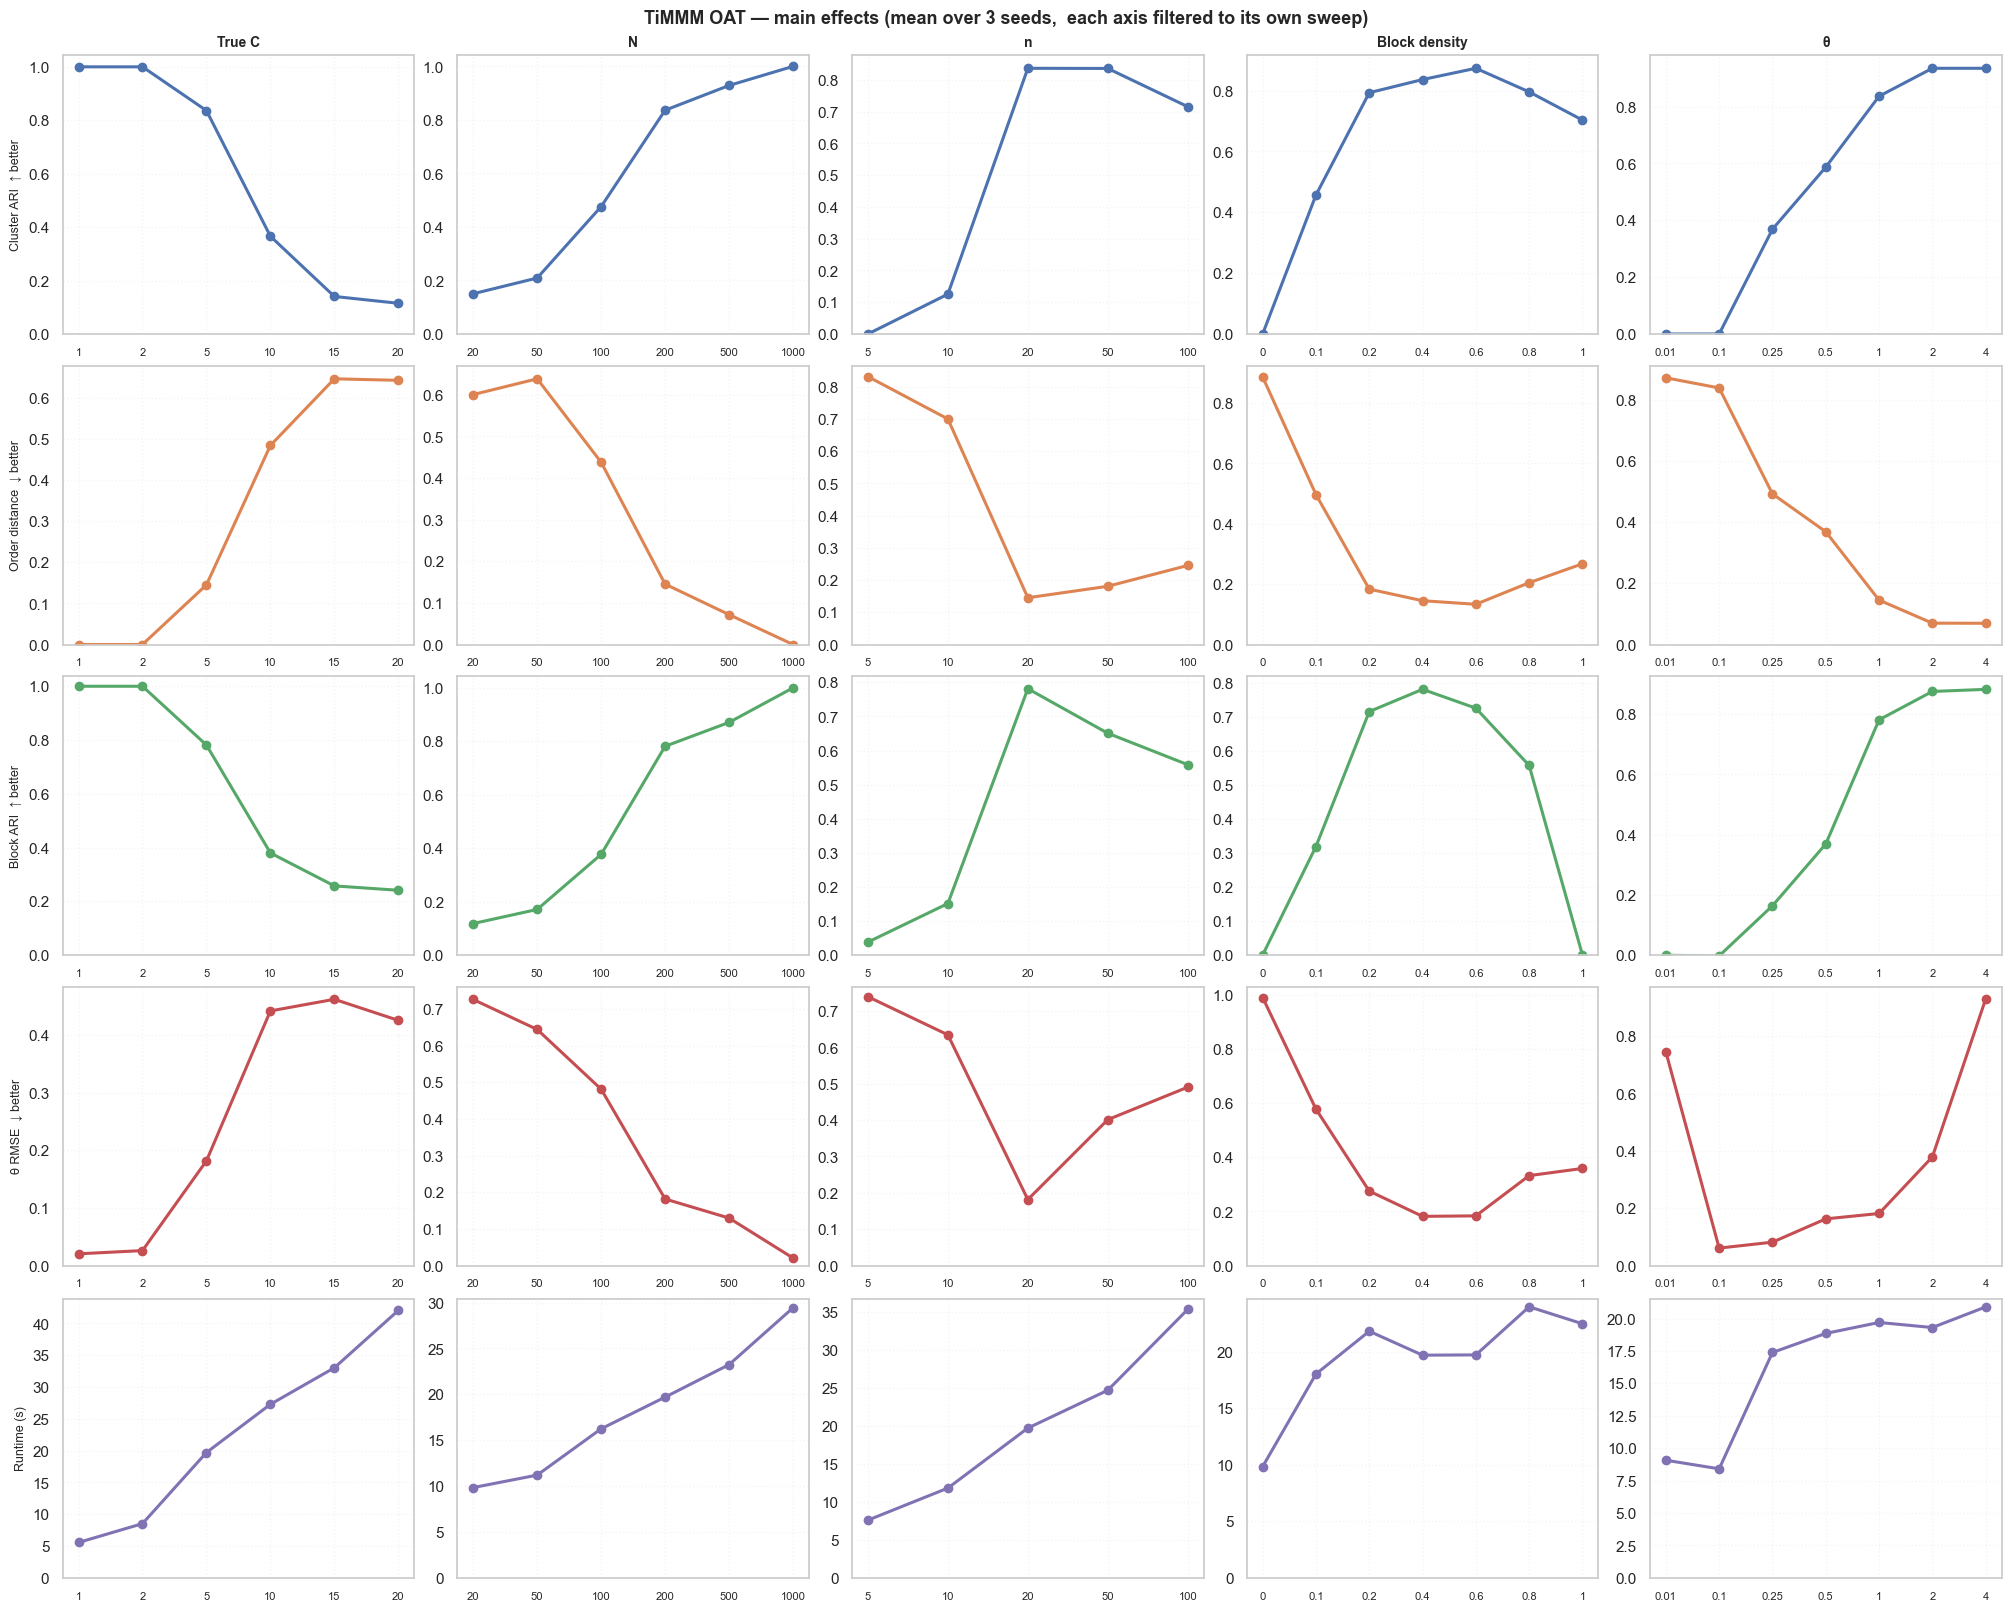

In [ ]:
# ── Main-effects plot: 4 metrics + runtime ────────────────────────────────────
metric_order_t = [label for _, label, _ in TIMMM_METRIC_SPECS]
timmm_colors   = sns.color_palette('deep', len(metric_order_t))

fig, axes = plt.subplots(
    len(TIMMM_METRIC_SPECS), len(TIMMM_PARAM_SPECS),
    figsize=(20, 3.2 * len(TIMMM_METRIC_SPECS)),
    constrained_layout=True,
)

for col_idx, (param_key, param_label) in enumerate(TIMMM_PARAM_SPECS):
    sweep_df = _oat_sweep_df(timmm_summary_df, param_key)

    for row_idx, (metric_key, metric_label, direction) in enumerate(TIMMM_METRIC_SPECS):
        ax = axes[row_idx, col_idx]
        col = f'{metric_key}_mean'
        if col not in sweep_df.columns:
            ax.set_visible(False)
            continue

        grp = (
            sweep_df.groupby(param_key, sort=True, dropna=False)[col]
            .mean()
            .reset_index()
            .sort_values(param_key)
        )
        x = np.arange(len(grp))
        ax.plot(
            x, grp[col],
            marker='o', linewidth=2.2, color=timmm_colors[row_idx],
        )
        ax.set_xticks(x)
        ax.set_xticklabels([_timmm_pretty_level(v) for v in grp[param_key]], fontsize=8)
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2, linestyle=':')
        if col_idx == 0:
            ylabel = f'{metric_label}  {direction}' if direction else metric_label
            ax.set_ylabel(ylabel, fontsize=9)
        if row_idx == 0:
            ax.set_title(param_label, fontsize=10, fontweight='bold')

fig.suptitle(
    'TiMMM OAT — main effects (mean over 3 seeds,  each axis filtered to its own sweep)',
    fontsize=13, fontweight='bold',
)
plt.show()


## TiMMM OAT — Random init vs Spectral init comparison

Head-to-head comparison using the **same four metrics and OAT design** from `_timmm_oat_study.py`.

Each point in the scatter plots is one base scenario (averaged over seeds). Points **above the diagonal** mean spectral initialisation wins; points **below** mean random wins.

The bar charts show signed improvement (spectral − random, sign-flipped so that positive always means "spectral is better") broken down by each OAT parameter axis, making it easy to see where — if anywhere — the initialisation strategy matters.

Runtime overhead is shown separately: spectral init adds an upfront spectral-clustering step whose cost scales with $N^2$.

> **Requires both runs to exist.**  
> Run `python _timmm_oat_study.py` (random) and `python _timmm_oat_study.py --spectral` (spectral) first.

Random-init  : recovery_timmm_oat_20260422_111103  (81 results)
Spectral-init: recovery_timmm_spectral_20260422_115553  (81 results)

Matched scenarios: 27


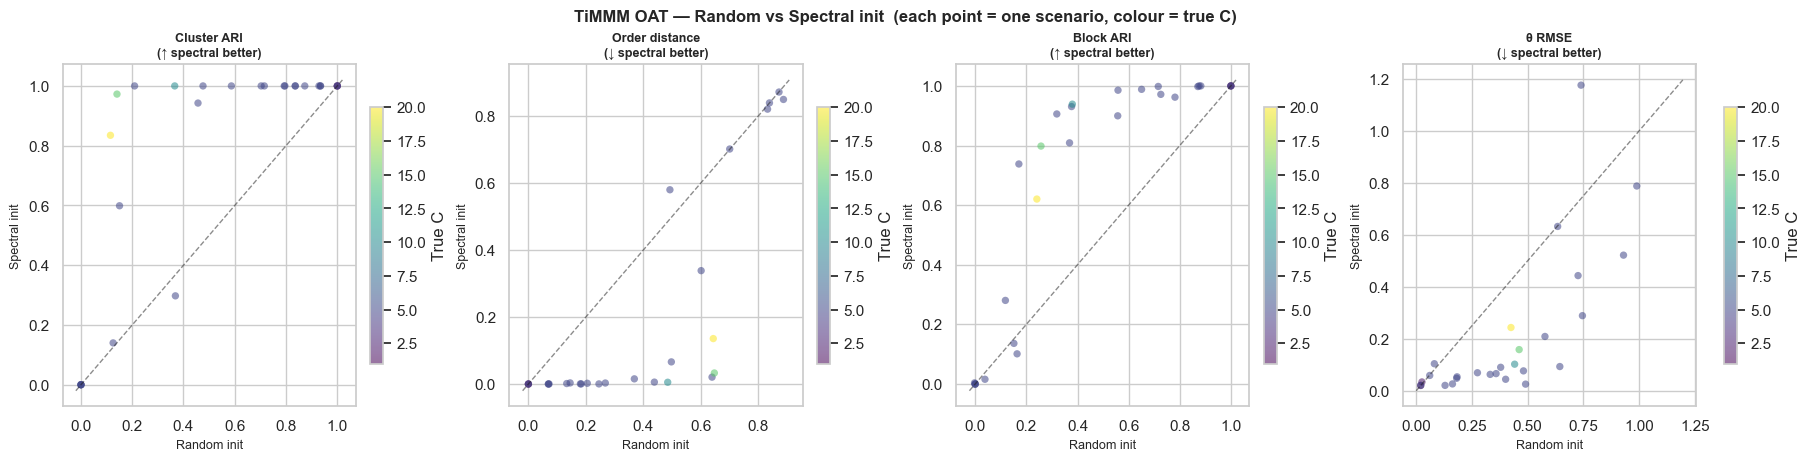


Mean Δ (spectral − random):


,Metric,Direction,Mean Δ,Std Δ,% scenarios spectral wins
0,Cluster ARI,↑ want +,0.2386,0.2722,70.3704
1,Order distance,↓ want −,-0.1933,0.2059,77.7778
2,Block ARI,↑ want +,0.2178,0.2235,66.6667
3,θ RMSE,↓ want −,-0.2008,0.2089,85.1852


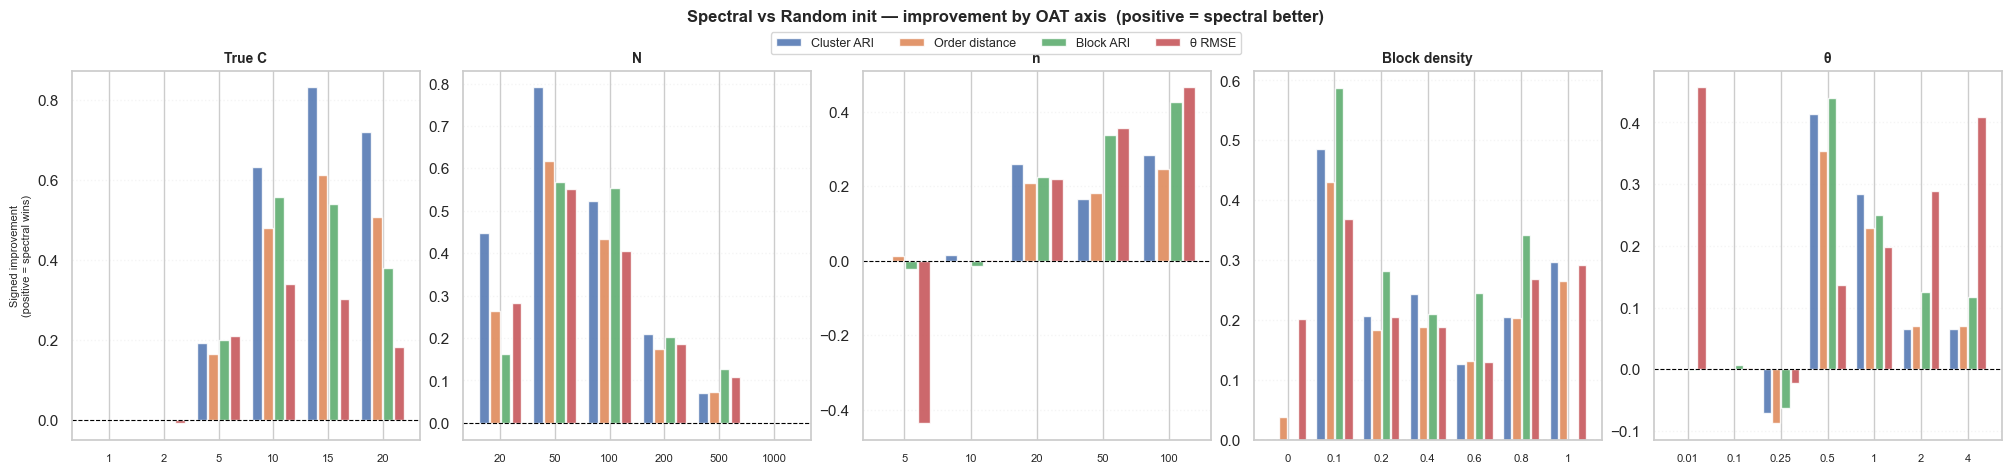

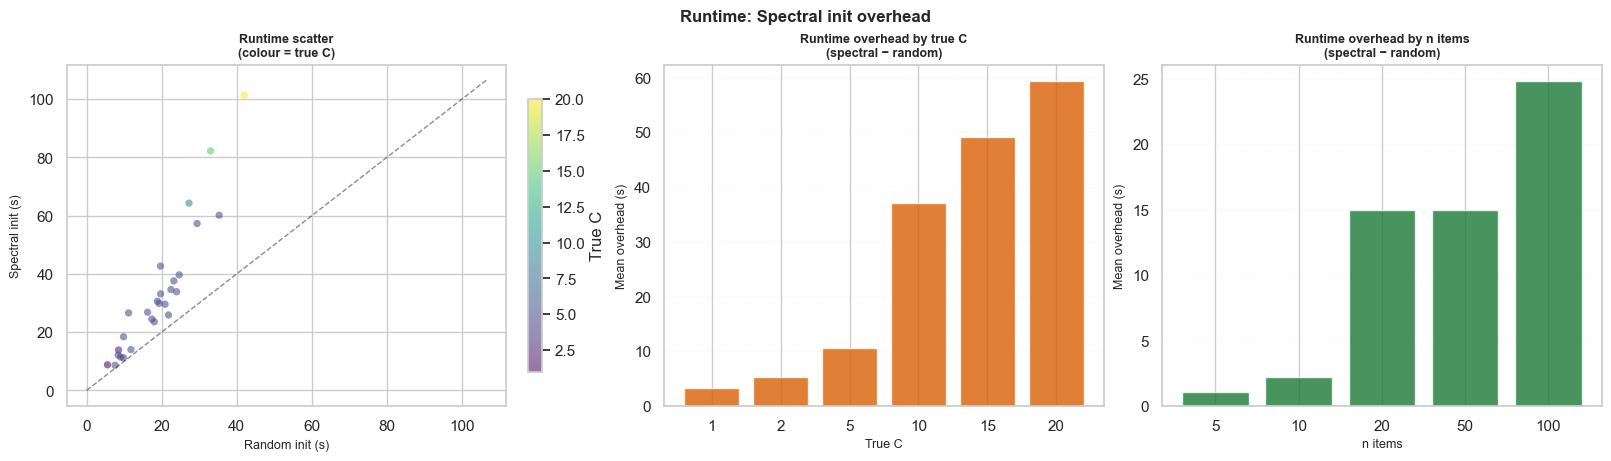

Mean runtime — random: 19.08 s  |  spectral: 33.43 s  |  overhead: +14.35 s  |  ratio: 1.66x


In [ ]:
# ── Load BOTH random-init and spectral-init timmm_oat runs ────────────────────
try:
    rand_run_dir = RUNS_DIR / TIMMM_OAT_RUN_NAME if TIMMM_OAT_RUN_NAME else latest_timmm_oat_run(spectral=False)
    _, rand_results = load_run(rand_run_dir)
    rand_trial_df   = flatten_timmm(rand_results)
    rand_summary_df = aggregate_timmm(rand_trial_df)
    print(f"Random-init  : {rand_run_dir.name}  ({len(rand_results)} results)")
except FileNotFoundError as e:
    print(f"Random-init run not found — {e}")
    rand_summary_df = pd.DataFrame()

try:
    spec_timmm_run_dir = latest_timmm_oat_run(spectral=True)
    _, spec_timmm_results = load_run(spec_timmm_run_dir)
    spec_timmm_trial_df   = flatten_timmm(spec_timmm_results)
    spec_timmm_summary_df = aggregate_timmm(spec_timmm_trial_df)
    print(f"Spectral-init: {spec_timmm_run_dir.name}  ({len(spec_timmm_results)} results)")
except FileNotFoundError as e:
    print(f"Spectral-init run not found — {e}")
    spec_timmm_summary_df = pd.DataFrame()

if rand_summary_df.empty or spec_timmm_summary_df.empty:
    print("\nCannot compare — one or both runs are missing.")
else:
    _merge_keys = ['base_scenario', 'n_clusters_true', 'n_assessors',
                   'n_items', 'block_density', 'theta']
    _metric_mean_cols = [f'{m}_mean' for m, _, _ in TIMMM_CMP_METRICS] + [RUNTIME_COL]

    cmp_t = rand_summary_df[_merge_keys + _metric_mean_cols].merge(
        spec_timmm_summary_df[_merge_keys + _metric_mean_cols],
        on=_merge_keys,
        suffixes=('_rand', '_spec'),
    )
    print(f"\nMatched scenarios: {len(cmp_t)}")

    # ── 1. Scatter plots: random vs spectral ──────────────────────────────────
    n_m = len(TIMMM_CMP_METRICS)
    fig, axes = plt.subplots(1, n_m, figsize=(4.5 * n_m, 4.5), constrained_layout=True)

    for ax, (mkey, mlabel, higher_better) in zip(axes, TIMMM_CMP_METRICS):
        col_r = f'{mkey}_mean_rand'
        col_s = f'{mkey}_mean_spec'
        xr, xs = cmp_t[col_r], cmp_t[col_s]
        sc = ax.scatter(xr, xs, alpha=0.55, s=28,
                        c=cmp_t['n_clusters_true'], cmap='viridis', edgecolors='none')
        lo = min(xr.min(), xs.min()) - 0.02
        hi = max(xr.max(), xs.max()) + 0.02
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5)
        ax.set_xlabel('Random init', fontsize=9)
        ax.set_ylabel('Spectral init', fontsize=9)
        arrow = '↑ spectral better' if higher_better else '↓ spectral better'
        ax.set_title(f'{mlabel}\n({arrow})', fontsize=9, fontweight='bold')
        plt.colorbar(sc, ax=ax, label='True C', shrink=0.75)

    fig.suptitle(
        'TiMMM OAT — Random vs Spectral init  (each point = one scenario, colour = true C)',
        fontsize=12, fontweight='bold',
    )
    plt.show()

    # ── 2. Summary table of mean Δ (spectral − random) ────────────────────────
    delta_rows = []
    for mkey, mlabel, higher_better in TIMMM_CMP_METRICS:
        col_r, col_s = f'{mkey}_mean_rand', f'{mkey}_mean_spec'
        delta = cmp_t[col_s] - cmp_t[col_r]
        delta_rows.append({
            'Metric': mlabel,
            'Direction': '↑ want +' if higher_better else '↓ want −',
            'Mean Δ': delta.mean(),
            'Std Δ': delta.std(),
            '% scenarios spectral wins': (
                (delta > 0).mean() * 100 if higher_better else (delta < 0).mean() * 100
            ),
        })
    print("\nMean Δ (spectral − random):")
    display(pd.DataFrame(delta_rows).round(4))

    # ── 3. Signed improvement by parameter axis ────────────────────────────────
    for mkey, mlabel, higher_better in TIMMM_CMP_METRICS:
        col_r, col_s = f'{mkey}_mean_rand', f'{mkey}_mean_spec'
        sign = 1 if higher_better else -1
        cmp_t[f'imp_{mkey}'] = sign * (cmp_t[col_s] - cmp_t[col_r])

    imp_cols   = [f'imp_{mkey}' for mkey, _, _ in TIMMM_CMP_METRICS]
    imp_labels = [mlabel for _, mlabel, _ in TIMMM_CMP_METRICS]
    colors_imp = sns.color_palette('deep', len(imp_cols))

    fig, axes = plt.subplots(1, len(TIMMM_PARAM_SPECS), figsize=(20, 4.2), constrained_layout=True)

    for ax, (param_key, param_label) in zip(axes, TIMMM_PARAM_SPECS):
        grp = cmp_t.groupby(param_key, sort=True)[imp_cols].mean()
        x     = np.arange(len(grp))
        width = 0.8 / len(imp_cols)
        for i, (col_imp, lbl, color) in enumerate(zip(imp_cols, imp_labels, colors_imp)):
            offset = (i - len(imp_cols) / 2 + 0.5) * width
            ax.bar(x + offset, grp[col_imp], width=width * 0.9,
                   label=lbl, color=color, alpha=0.85)
        ax.axhline(0, color='black', lw=0.8, linestyle='--')
        ax.set_xticks(x)
        ax.set_xticklabels([_timmm_pretty_level(v) for v in grp.index], fontsize=8)
        ax.set_title(param_label, fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.2, linestyle=':')
        if ax is axes[0]:
            ax.set_ylabel('Signed improvement\n(positive = spectral wins)', fontsize=8)

    handles, labels_leg = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_leg, loc='upper center', ncol=len(imp_cols),
               bbox_to_anchor=(0.5, 1.05), fontsize=9, frameon=True)
    fig.suptitle(
        'Spectral vs Random init — improvement by OAT axis  (positive = spectral better)',
        fontsize=12, fontweight='bold', y=1.09,
    )
    plt.show()

    # ── 4. Runtime comparison ──────────────────────────────────────────────────
    rt_r = f'{RUNTIME_COL}_rand'
    rt_s = f'{RUNTIME_COL}_spec'
    if rt_r in cmp_t.columns and rt_s in cmp_t.columns:
        cmp_t['rt_overhead'] = cmp_t[rt_s] - cmp_t[rt_r]
        cmp_t['rt_ratio']    = cmp_t[rt_s] / cmp_t[rt_r].replace(0, float('nan'))

        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

        ax = axes[0]
        sc = ax.scatter(cmp_t[rt_r], cmp_t[rt_s], alpha=0.55, s=28,
                        c=cmp_t['n_clusters_true'], cmap='viridis', edgecolors='none')
        hi = max(cmp_t[rt_r].max(), cmp_t[rt_s].max()) * 1.05
        ax.plot([0, hi], [0, hi], 'k--', lw=1, alpha=0.5)
        ax.set_xlabel('Random init (s)', fontsize=9)
        ax.set_ylabel('Spectral init (s)', fontsize=9)
        ax.set_title('Runtime scatter\n(colour = true C)', fontsize=9, fontweight='bold')
        plt.colorbar(sc, ax=ax, label='True C', shrink=0.8)

        ax = axes[1]
        grp_rt = cmp_t.groupby('n_clusters_true')['rt_overhead'].mean()
        x = np.arange(len(grp_rt))
        ax.bar(x, grp_rt.values, color='#d95f02', alpha=0.8)
        ax.axhline(0, color='black', lw=0.8, linestyle='--')
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in grp_rt.index])
        ax.set_xlabel('True C', fontsize=9)
        ax.set_ylabel('Mean overhead (s)', fontsize=9)
        ax.set_title('Runtime overhead by true C\n(spectral − random)', fontsize=9, fontweight='bold')
        ax.grid(axis='y', alpha=0.2, linestyle=':')

        ax = axes[2]
        grp_rt2 = cmp_t.groupby('n_items')['rt_overhead'].mean()
        x2 = np.arange(len(grp_rt2))
        ax.bar(x2, grp_rt2.values, color='#1b7837', alpha=0.8)
        ax.axhline(0, color='black', lw=0.8, linestyle='--')
        ax.set_xticks(x2)
        ax.set_xticklabels([str(v) for v in grp_rt2.index])
        ax.set_xlabel('n items', fontsize=9)
        ax.set_ylabel('Mean overhead (s)', fontsize=9)
        ax.set_title('Runtime overhead by n items\n(spectral − random)', fontsize=9, fontweight='bold')
        ax.grid(axis='y', alpha=0.2, linestyle=':')

        fig.suptitle('Runtime: Spectral init overhead', fontsize=12, fontweight='bold')
        plt.show()

        print(
            f"Mean runtime — random: {cmp_t[rt_r].mean():.2f} s  |  "
            f"spectral: {cmp_t[rt_s].mean():.2f} s  |  "
            f"overhead: {cmp_t['rt_overhead'].mean():+.2f} s  |  "
            f"ratio: {cmp_t['rt_ratio'].mean():.2f}x"
        )


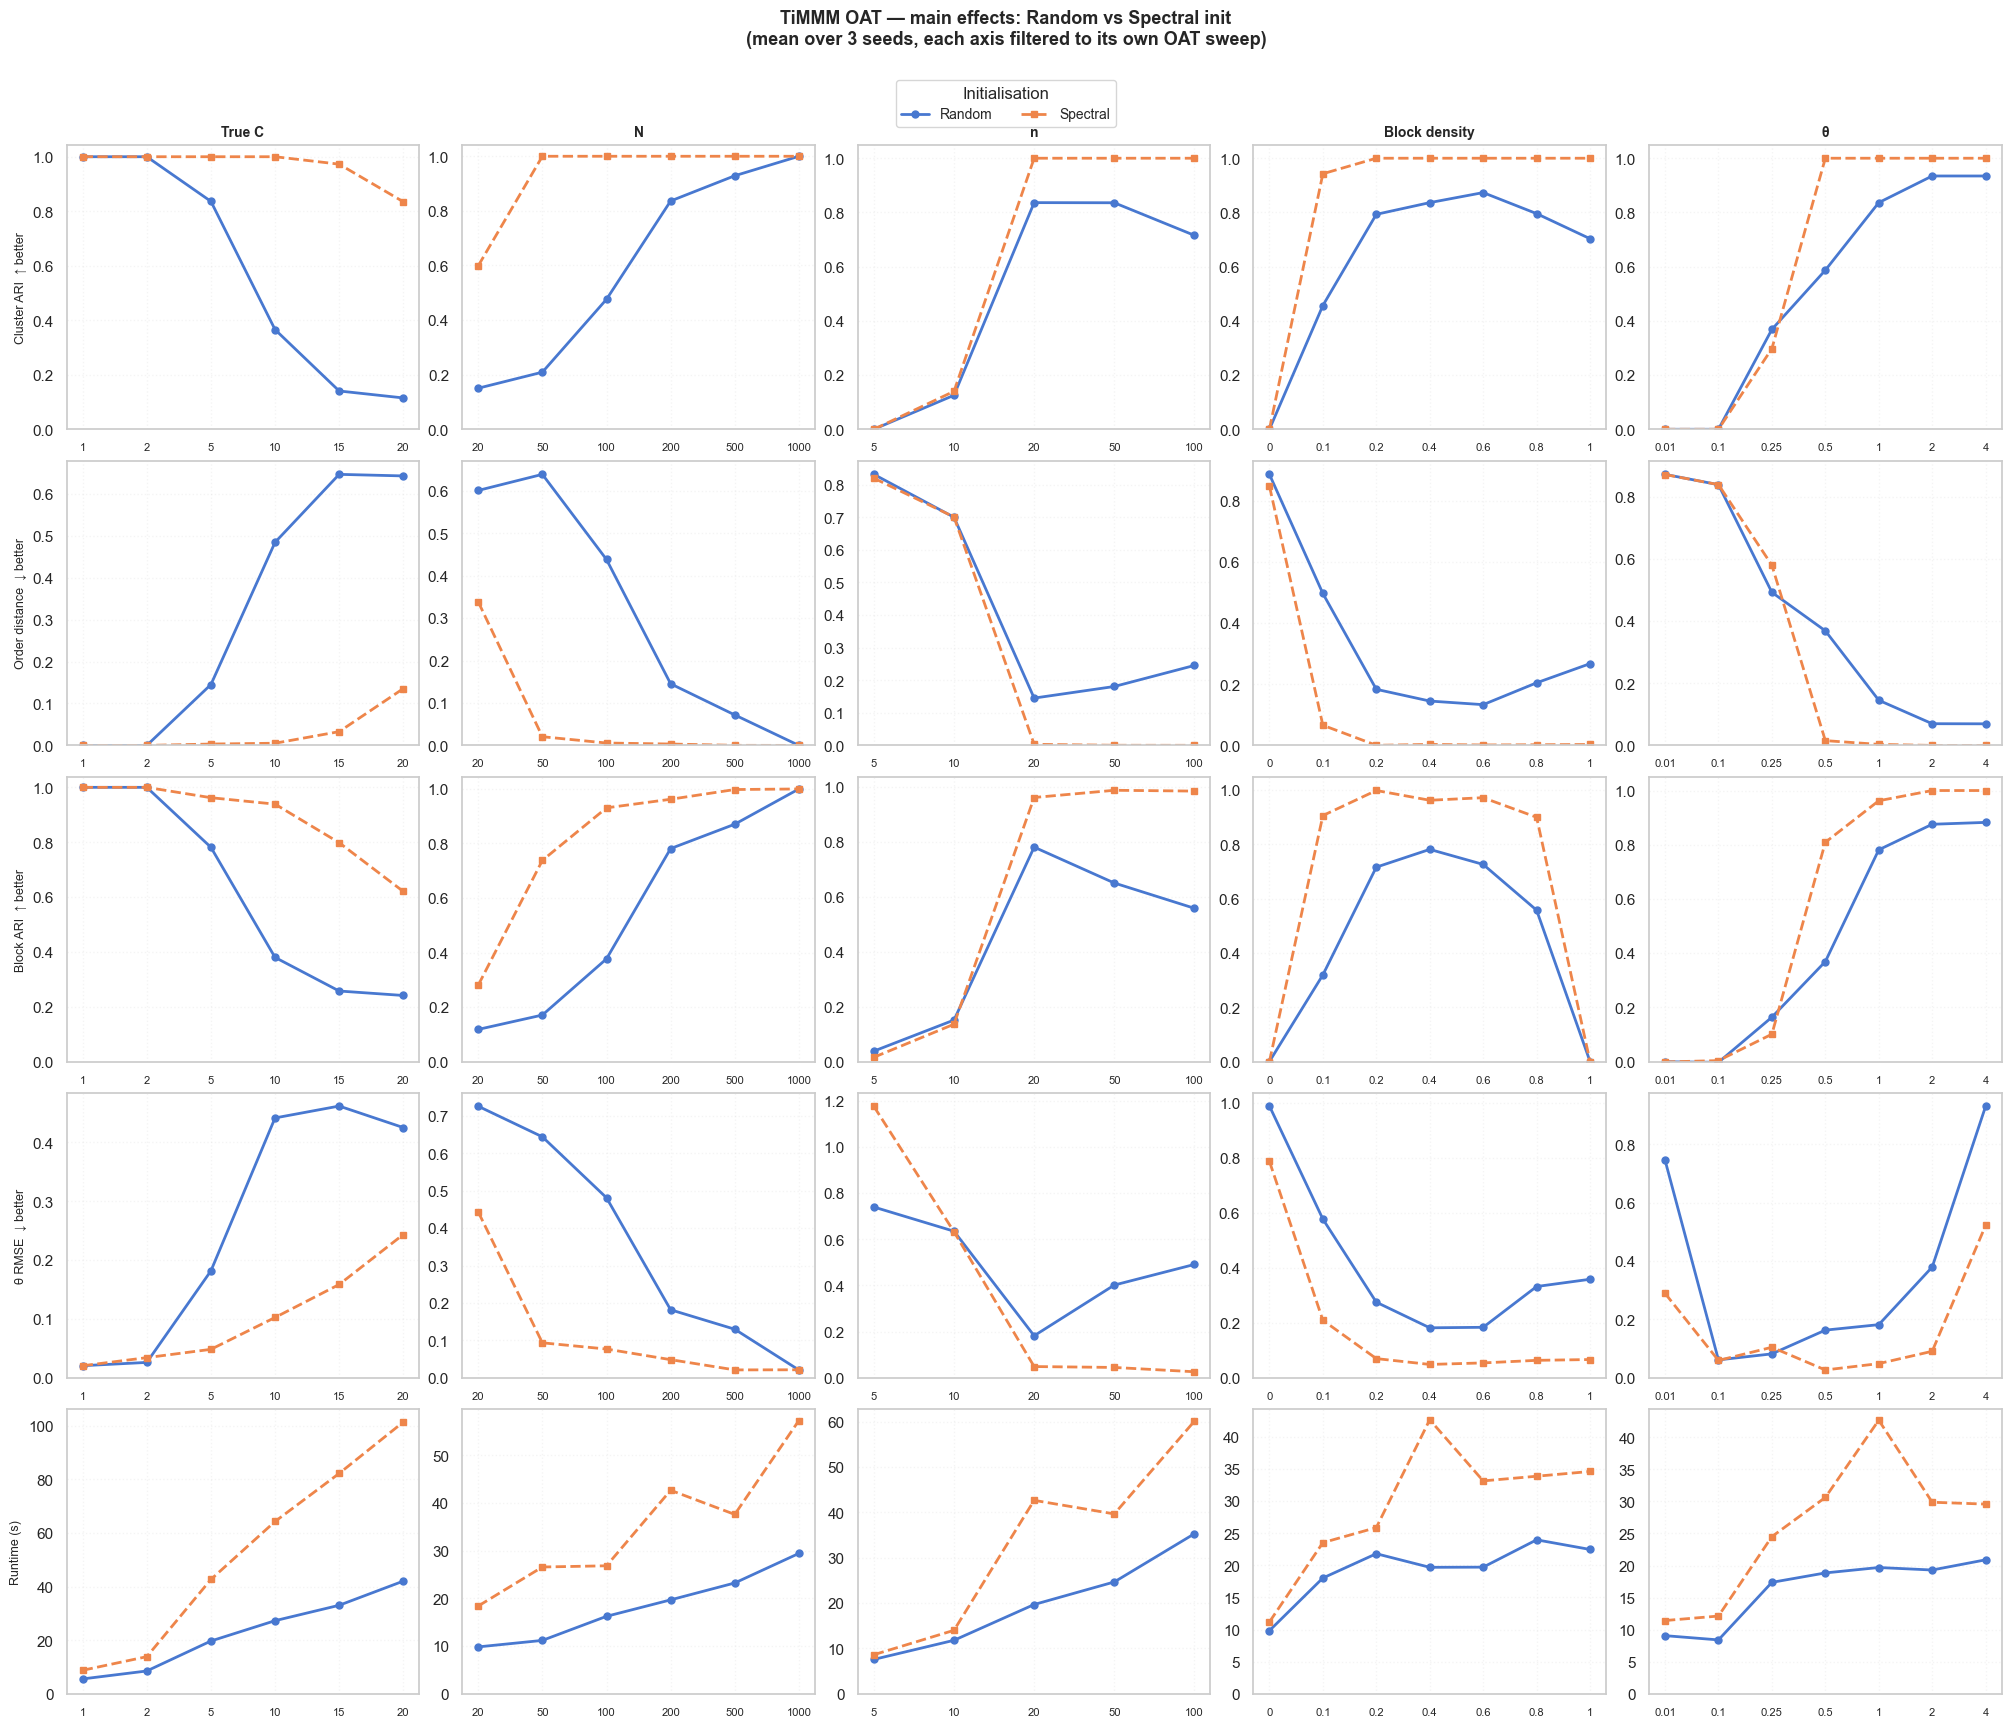

In [29]:
# ── Overlaid main-effects plot: Random init vs Spectral init ──────────────────
# Same 5-metric × 5-parameter grid as the single-run plot above, but both
# initialisation strategies are drawn on each subplot for direct comparison.

_INIT_STYLES = [
    (rand_summary_df,        'Random',   'o', '-',  '#4878d0'),
    (spec_timmm_summary_df,  'Spectral', 's', '--', '#ee854a'),
]

fig, axes = plt.subplots(
    len(TIMMM_METRIC_SPECS), len(TIMMM_PARAM_SPECS),
    figsize=(20, 3.2 * len(TIMMM_METRIC_SPECS)),
    constrained_layout=True,
)

for col_idx, (param_key, param_label) in enumerate(TIMMM_PARAM_SPECS):
    for row_idx, (metric_key, metric_label, direction) in enumerate(TIMMM_METRIC_SPECS):
        ax = axes[row_idx, col_idx]
        col = f'{metric_key}_mean'

        for df, init_label, marker, ls, color in _INIT_STYLES:
            sweep_df = _oat_sweep_df(df, param_key)
            if col not in sweep_df.columns:
                continue
            grp = (
                sweep_df.groupby(param_key, sort=True, dropna=False)[col]
                .mean()
                .reset_index()
                .sort_values(param_key)
            )
            x = np.arange(len(grp))
            ax.plot(
                x, grp[col],
                marker=marker, linewidth=2.0, linestyle=ls,
                color=color, label=init_label, markersize=5,
            )
            ax.set_xticks(x)
            ax.set_xticklabels([_timmm_pretty_level(v) for v in grp[param_key]], fontsize=8)

        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2, linestyle=':')
        if col_idx == 0:
            ylabel = f'{metric_label}  {direction}' if direction else metric_label
            ax.set_ylabel(ylabel, fontsize=9)
        if row_idx == 0:
            ax.set_title(param_label, fontsize=10, fontweight='bold')

# Single shared legend at the top
handles_leg, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles_leg, labels_leg, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 1.03), fontsize=10, frameon=True,
           title='Initialisation')

fig.suptitle(
    'TiMMM OAT — main effects: Random vs Spectral init\n'
    '(mean over 3 seeds, each axis filtered to its own OAT sweep)',
    fontsize=13, fontweight='bold', y=1.07,
)
plt.show()


## TiMMM — Convergence study: slow mixing vs local minima

For the **hard scenarios** where spectral init outperforms random init in the OAT comparison above, this section diagnoses *why* random init fails:

* **Slow convergence** — random init is not stuck; it just needs a longer chain. Metric improves monotonically as the chain grows and eventually matches spectral init.
* **Local minima** — random init is trapped. Even with a very long chain it plateaus well below spectral init.

**Method**: run a single long chain per (scenario, init strategy) pair, then evaluate the MAP at multiple prefix checkpoints (fractions of saved samples). Because both short-chain and long-chain assessments come from the *same run*, run-to-run variance is eliminated as a confounder.

**Generate the data**:
```
python _timmm_convergence_study.py \
    --rand-dir simulation_recovery_runs/recovery_timmm_oat_20260422_111103 \
    --spec-dir simulation_recovery_runs/recovery_timmm_spectral_20260422_115553 \
    --n-hard 20 --n-iter 30000 --burn-in 5000 --thin 20 --n-restarts 1
```
For a quick smoke-test add `--limit 6 --n-iter 5000`.


In [5]:
# ── Load convergence study run ────────────────────────────────────────────────
# Set CONVERGENCE_RUN_NAME to pin a specific run, or None to auto-detect latest.
CONVERGENCE_RUN_NAME = None   # e.g. 'recovery_timmm_convergence_20260502_120000'

try:
    conv_run_dir = RUNS_DIR / CONVERGENCE_RUN_NAME if CONVERGENCE_RUN_NAME else latest_timmm_convergence_run()
    conv_metadata, conv_results = load_run(conv_run_dir)
    print(f"Convergence run : {conv_run_dir.name}  ({len(conv_results)} records)")
    print(json.dumps({k: v for k, v in conv_metadata.items() if k != 'hard_scenarios'}, indent=2))
except FileNotFoundError as e:
    print(f"Convergence run not found — {e}")
    conv_results = []
    conv_metadata = {}


Convergence run : recovery_timmm_convergence_20260501_152312  (4 records)
{
  "mode": "timmm_convergence",
  "rand_dir": "simulation_recovery_runs\\recovery_timmm_oat_20260422_111103",
  "spec_dir": "simulation_recovery_runs\\recovery_timmm_spectral_20260422_115553",
  "gap_metric": "cluster_ari",
  "n_hard": 5,
  "n_iter": 3000,
  "burn_in": 1000,
  "thin": 10,
  "n_restarts": 1,
  "checkpoints": [
    0.25,
    0.5,
    1.0
  ],
  "seeds": [
    42
  ],
  "total_work_items": 4,
  "output_dir": "simulation_recovery_runs\\recovery_timmm_convergence_20260501_152312"
}


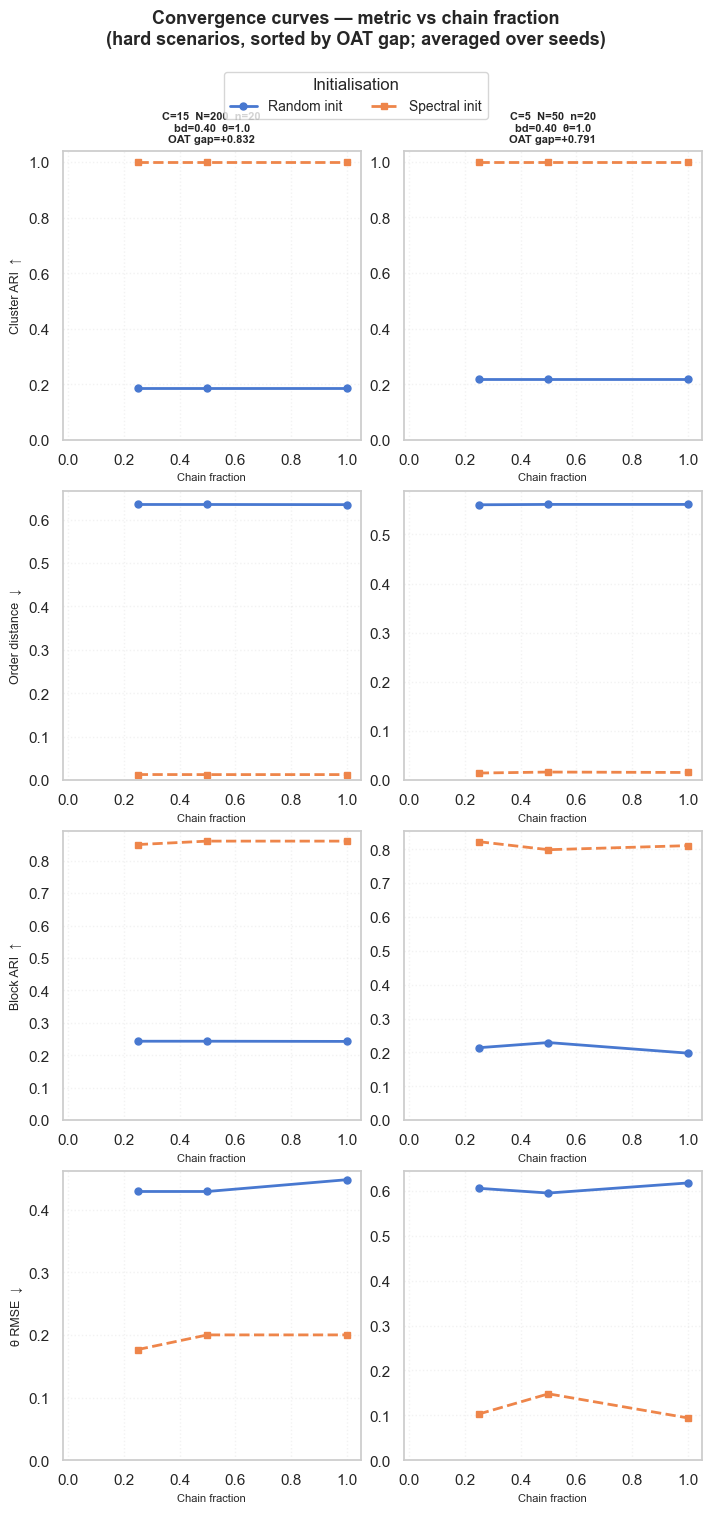


Mean ARI gain (shortest checkpoint → longest checkpoint):
    random: +0.0000 ± 0.0000
  spectral: +0.0000 ± 0.0000


In [6]:
# ── Convergence curves: random vs spectral init across chain lengths ───────────
# Each subplot shows one hard scenario.  X-axis = chain fraction (checkpoint).
# Lines: random init (solid) and spectral init (dashed).
# If random improves and catches up → slow convergence.
# If random plateaus well below spectral → local minima.

if not conv_results:
    print("No convergence results to plot — run the study first.")
else:
    # ── Flatten into a tidy DataFrame ─────────────────────────────────────────
    conv_rows = []
    for rec in conv_results:
        sc = rec['scenario']
        init = rec['init_strategy']
        gap  = rec.get('oat_gap', float('nan'))
        base = strip_seed(sc['name'])
        for cp in rec['convergence']['checkpoints']:
            row = {
                'base_scenario': base,
                'scenario_name': sc['name'],
                'seed':          sc['seed'],
                'n_clusters':    sc['n_clusters'],
                'n_assessors':   sc['n_assessors'],
                'n_items':       sc['n_items'],
                'theta':         sc['theta'],
                'block_density': sc['block_density'],
                'init_strategy': init,
                'oat_gap':       gap,
                'fraction':      cp['fraction'],
                'n_samples':     cp['n_samples'],
                'best_logp':     cp['best_logp'],
                'logp_refined':  cp.get('logp_refined', float('nan')),
            }
            for mkey, _, _ in _CONV_METRICS:
                row[mkey] = cp['metrics'].get(mkey, float('nan'))
            conv_rows.append(row)

    conv_df = pd.DataFrame(conv_rows)

    # Average over seeds within each (base_scenario, init_strategy, fraction)
    conv_avg = (
        conv_df.groupby(['base_scenario', 'n_clusters', 'n_assessors', 'n_items',
                         'theta', 'block_density', 'init_strategy', 'fraction', 'oat_gap'])
        [[mkey for mkey, _, _ in _CONV_METRICS] + ['best_logp', 'logp_refined']]
        .mean()
        .reset_index()
    )

    # One row per base scenario, sorted by oat_gap descending
    base_scenarios = (
        conv_avg[['base_scenario', 'oat_gap']]
        .drop_duplicates()
        .sort_values('oat_gap', ascending=False)
        .reset_index(drop=True)
    )

    n_scenarios = len(base_scenarios)
    n_metrics   = len(_CONV_METRICS)

    _INIT_STYLES_CONV = {
        'random':   ('o', '-',  '#4878d0', 'Random init'),
        'spectral': ('s', '--', '#ee854a', 'Spectral init'),
    }

    fig, axes = plt.subplots(
        n_metrics, n_scenarios,
        figsize=(max(4, 3.5 * n_scenarios), 3.5 * n_metrics),
        constrained_layout=True,
    )
    if n_scenarios == 1:
        axes = axes.reshape(n_metrics, 1)
    if n_metrics == 1:
        axes = axes.reshape(1, n_scenarios)

    for col_idx, row in base_scenarios.iterrows():
        base = row['base_scenario']
        gap  = row['oat_gap']
        subset = conv_avg[conv_avg['base_scenario'] == base]

        for row_idx, (mkey, mlabel, higher_better) in enumerate(_CONV_METRICS):
            ax = axes[row_idx, col_idx]

            for init, (marker, ls, color, legend_label) in _INIT_STYLES_CONV.items():
                grp = (
                    subset[subset['init_strategy'] == init]
                    .sort_values('fraction')
                )
                if grp.empty:
                    continue
                ax.plot(
                    grp['fraction'], grp[mkey],
                    marker=marker, linestyle=ls, color=color,
                    linewidth=2.0, markersize=5, label=legend_label,
                )

            ax.set_xlim(-0.02, 1.05)
            ax.set_ylim(bottom=0)
            ax.set_xlabel('Chain fraction', fontsize=8)
            ax.grid(alpha=0.25, linestyle=':')

            arrow = '↑' if higher_better else '↓'
            if col_idx == 0:
                ax.set_ylabel(f'{mlabel}  {arrow}', fontsize=9)
            if row_idx == 0:
                sc_row = subset.iloc[0]
                title = (
                    f"C={int(sc_row['n_clusters'])}  N={int(sc_row['n_assessors'])}"
                    f"  n={int(sc_row['n_items'])}\n"
                    f"bd={sc_row['block_density']:.2f}  θ={sc_row['theta']}"
                    f"\nOAT gap={gap:+.3f}"
                )
                ax.set_title(title, fontsize=8, fontweight='bold')

    handles_leg, labels_leg = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles_leg, labels_leg, loc='upper center', ncol=2,
               bbox_to_anchor=(0.5, 1.03), fontsize=10, frameon=True,
               title='Initialisation')
    fig.suptitle(
        'Convergence curves — metric vs chain fraction\n'
        '(hard scenarios, sorted by OAT gap; averaged over seeds)',
        fontsize=13, fontweight='bold', y=1.07,
    )
    plt.show()

    # ── Summary: mean ARI gain from shortest → longest checkpoint ─────────────
    print("\nMean ARI gain (shortest checkpoint → longest checkpoint):")
    for init in ['random', 'spectral']:
        grp = conv_avg[conv_avg['init_strategy'] == init]
        gains = []
        for base in grp['base_scenario'].unique():
            sub = grp[grp['base_scenario'] == base].sort_values('fraction')
            if len(sub) >= 2:
                gains.append(sub['cluster_ari'].iloc[-1] - sub['cluster_ari'].iloc[0])
        if gains:
            print(f"  {init:>8}: {np.mean(gains):+.4f} ± {np.std(gains):.4f}")


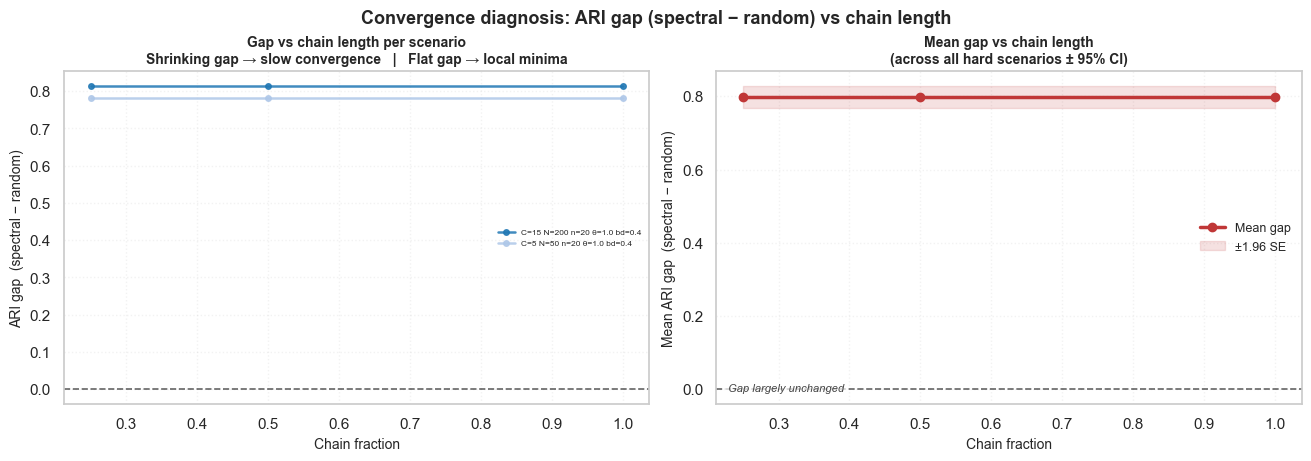

In [7]:
# ── Gap evolution: (spectral − random) ARI vs chain fraction ──────────────────
# If the gap *shrinks* as chain grows → slow convergence.
# If the gap *stays flat or grows* → local minima trapping random init.

if 'conv_avg' not in dir() or conv_avg.empty:
    print("No convergence data — run the study and execute the previous cell first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

    # ── Left: gap per base scenario ────────────────────────────────────────────
    ax = axes[0]
    fracs_sorted = sorted(conv_avg['fraction'].unique())
    colors_gap = sns.color_palette('tab20', n_scenarios)

    for color, (_, row) in zip(colors_gap, base_scenarios.iterrows()):
        base = row['base_scenario']
        sc_row = conv_avg[conv_avg['base_scenario'] == base].iloc[0]
        label = (
            f"C={int(sc_row['n_clusters'])} N={int(sc_row['n_assessors'])}"
            f" n={int(sc_row['n_items'])} θ={sc_row['theta']} bd={sc_row['block_density']:.1f}"
        )
        rand_line = (
            conv_avg[(conv_avg['base_scenario'] == base) & (conv_avg['init_strategy'] == 'random')]
            .sort_values('fraction')
        )
        spec_line = (
            conv_avg[(conv_avg['base_scenario'] == base) & (conv_avg['init_strategy'] == 'spectral')]
            .sort_values('fraction')
        )
        if rand_line.empty or spec_line.empty:
            continue
        # Align on fractions
        merged = rand_line[['fraction', 'cluster_ari']].merge(
            spec_line[['fraction', 'cluster_ari']],
            on='fraction', suffixes=('_rand', '_spec'),
        )
        merged['gap'] = merged['cluster_ari_spec'] - merged['cluster_ari_rand']
        ax.plot(merged['fraction'], merged['gap'], marker='o', linewidth=1.8,
                color=color, label=label, markersize=4, alpha=0.85)

    ax.axhline(0, color='black', lw=1.2, linestyle='--', alpha=0.6)
    ax.set_xlabel('Chain fraction', fontsize=10)
    ax.set_ylabel('ARI gap  (spectral − random)', fontsize=10)
    ax.set_title(
        'Gap vs chain length per scenario\n'
        'Shrinking gap → slow convergence   |   Flat gap → local minima',
        fontsize=10, fontweight='bold',
    )
    ax.grid(alpha=0.25, linestyle=':')
    ax.legend(fontsize=6, ncol=1, loc='best', framealpha=0.7)

    # ── Right: mean gap ± SE across all hard scenarios ─────────────────────────
    ax = axes[1]
    gap_by_frac = []
    for frac in fracs_sorted:
        rand_vals = conv_avg[(conv_avg['fraction'] == frac) & (conv_avg['init_strategy'] == 'random')]['cluster_ari'].values
        spec_vals = conv_avg[(conv_avg['fraction'] == frac) & (conv_avg['init_strategy'] == 'spectral')]['cluster_ari'].values
        # Pair by base_scenario
        rand_df = conv_avg[(conv_avg['fraction'] == frac) & (conv_avg['init_strategy'] == 'random')][['base_scenario', 'cluster_ari']].set_index('base_scenario')
        spec_df = conv_avg[(conv_avg['fraction'] == frac) & (conv_avg['init_strategy'] == 'spectral')][['base_scenario', 'cluster_ari']].set_index('base_scenario')
        common = rand_df.index.intersection(spec_df.index)
        if len(common) == 0:
            continue
        gaps_f = spec_df.loc[common, 'cluster_ari'].values - rand_df.loc[common, 'cluster_ari'].values
        gap_by_frac.append({
            'fraction': frac,
            'mean_gap': float(np.mean(gaps_f)),
            'se_gap':   float(np.std(gaps_f, ddof=1) / max(1, np.sqrt(len(gaps_f)))),
            'n':        len(gaps_f),
        })

    if gap_by_frac:
        gdf = pd.DataFrame(gap_by_frac)
        ax.plot(gdf['fraction'], gdf['mean_gap'], marker='o', linewidth=2.5,
                color='#c03737', label='Mean gap')
        ax.fill_between(
            gdf['fraction'],
            gdf['mean_gap'] - 1.96 * gdf['se_gap'],
            gdf['mean_gap'] + 1.96 * gdf['se_gap'],
            color='#c03737', alpha=0.15, label='±1.96 SE',
        )
        ax.axhline(0, color='black', lw=1.2, linestyle='--', alpha=0.6)
        ax.set_xlabel('Chain fraction', fontsize=10)
        ax.set_ylabel('Mean ARI gap  (spectral − random)', fontsize=10)
        ax.set_title(
            'Mean gap vs chain length\n(across all hard scenarios ± 95% CI)',
            fontsize=10, fontweight='bold',
        )
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25, linestyle=':')

        # Annotate with interpretation
        first_gap = gdf['mean_gap'].iloc[0]
        last_gap  = gdf['mean_gap'].iloc[-1]
        change    = last_gap - first_gap
        interp = (
            "Gap shrinks → consistent with slow convergence"
            if change < -0.02
            else ("Gap grows/flat → consistent with local minima" if change > 0.01
                  else "Gap largely unchanged")
        )
        ax.text(0.02, 0.04, interp, transform=ax.transAxes,
                fontsize=8, color='#444', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    fig.suptitle(
        'Convergence diagnosis: ARI gap (spectral − random) vs chain length',
        fontsize=13, fontweight='bold',
    )
    plt.show()


## TiMMM OAT — Consensus clustering (10 seeds, 4 evaluation lines)

Four evaluated lines per OAT axis, produced by `_timmm_consensus_study.py`:

| Line | Init | Aggregation |
|---|---|---|
| **rand_mean** | Random | mean best-MAP over restarts & seeds |
| **rand_consensus** | Random | co-occurrence consensus → single-cluster TiMMM |
| **spec_mean** | Spectral | mean best-MAP over restarts & seeds |
| **spec_consensus** | Spectral | co-occurrence consensus → single-cluster TiMMM |

Run the study with:
```
python _timmm_consensus_study.py
# quick smoke-test:
python _timmm_consensus_study.py --limit 10 --n-iter 2000 --burn-in 1000 --thin 10 --n-restarts 3
```

In [ ]:
# ── Load timmm_consensus run ──────────────────────────────────────────────────
# Set TIMMM_CONSENSUS_RUN_NAME to pin a specific run, or None to auto-detect.
TIMMM_CONSENSUS_RUN_NAME = 'recovery_timmm_consensus_20260423_100838'

cons_run_dir = (
    RUNS_DIR / TIMMM_CONSENSUS_RUN_NAME if TIMMM_CONSENSUS_RUN_NAME
    else latest_timmm_consensus_run()
)
_, cons_results = load_run(cons_run_dir)
cons_trial_df   = flatten_consensus(cons_results)
cons_summary_df = aggregate_consensus(cons_trial_df)

print(f"Run directory : {cons_run_dir}")
print(f"Results loaded: {len(cons_results)}")
print(f"Trial rows    : {len(cons_trial_df)}")
print(f"Scenario rows : {len(cons_summary_df)}")
cons_summary_df.head()


Run directory : simulation_recovery_runs\recovery_timmm_consensus_20260423_100838
Results loaded: 78
Trial rows    : 78
Scenario rows : 26


,base_scenario,n_clusters_true,n_assessors,n_items,block_density,theta,fit_n_clusters,runtime_seconds,rand_mean_cluster_ari,rand_mean_cluster_nmi,rand_mean_order_distance,rand_mean_block_ari,rand_mean_block_nmi,rand_mean_theta_rmse,rand_consensus_cluster_ari,rand_consensus_cluster_nmi,rand_consensus_order_distance,rand_consensus_block_ari,rand_consensus_block_nmi,rand_consensus_theta_rmse,rand_k_consensus,spec_mean_cluster_ari,spec_mean_cluster_nmi,spec_mean_order_distance,spec_mean_block_ari,spec_mean_block_nmi,spec_mean_theta_rmse,spec_consensus_cluster_ari,spec_consensus_cluster_nmi,spec_consensus_order_distance,spec_consensus_block_ari,spec_consensus_block_nmi,spec_consensus_theta_rmse,spec_k_consensus
0,c2_n200_ni20_bd0p40_theta1p0,2,200,20,0.4,1.0,4,410.775576,0.900000,0.900000,0.049742,0.906934,0.939121,0.108181,1.000000,1.000000,0.000000,1.000000,1.000000,0.032024,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.032063,1.000000,1.000000,0.000000,1.000000,1.000000,0.032024,2.0
1,c5_n20_ni20_bd0p40_theta1p0,5,20,20,0.4,1.0,10,173.847513,0.148556,0.289200,0.619969,0.118738,0.359970,0.694706,0.509974,0.698117,0.407281,0.317982,0.548189,0.500077,2.666667,0.653662,0.797167,0.282671,0.367838,0.646756,0.481449,0.853213,0.889511,0.130921,0.509643,0.779087,0.328829,4.0
2,c5_n50_ni20_bd0p40_theta1p0,5,50,20,0.4,1.0,10,28136.729457,0.422135,0.621249,0.459846,0.326069,0.507110,0.517723,0.812252,0.905039,0.169877,0.580644,0.763137,0.266632,4.000000,1.000000,1.000000,0.018682,0.761385,0.920670,0.112264,1.000000,1.000000,0.019316,0.750382,0.918510,0.094362,5.0
3,c5_n100_ni20_bd0p40_theta1p0,5,100,20,0.4,1.0,10,669.654117,0.611901,0.798306,0.338132,0.464589,0.617947,0.411793,1.000000,1.000000,0.005202,0.936037,0.971761,0.040796,5.000000,1.000000,1.000000,0.005434,0.933808,0.971206,0.068303,1.000000,1.000000,0.005018,0.938346,0.972876,0.043854,5.0
4,c5_n200_ni5_bd0p40_theta1p0,5,200,5,0.4,1.0,10,150.833207,0.000000,0.000000,0.831192,0.031422,0.125650,0.764691,0.000000,0.000000,0.831583,0.037950,0.133261,0.758773,1.000000,0.000000,0.000000,0.829233,0.031041,0.123592,0.780648,0.000000,0.000000,0.831583,0.037950,0.133261,0.758773,1.0


In [ ]:
# ── Overlaid main-effects plot: 4 lines (rand/spec × mean/consensus) ──────────
with plt.rc_context({
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.linewidth':     0.8,
    'xtick.major.size':   3,
    'ytick.major.size':   3,
    'font.size':          9,
    'axes.titlesize':     10,
    'axes.labelsize':     9,
}):
    n_metrics = len(_CONS_METRIC_SPECS)
    n_params  = len(TIMMM_PARAM_SPECS)
    fig, axes = plt.subplots(
        n_metrics, n_params,
        figsize=(16, 2.8 * n_metrics),
        constrained_layout=True,
    )

    for col_idx, (param_key, param_label) in enumerate(TIMMM_PARAM_SPECS):
        for row_idx, (metric_key, metric_label, direction, bounded) in enumerate(_CONS_METRIC_SPECS):
            ax = axes[row_idx, col_idx]
            sweep = _cons_oat_sweep_df(cons_summary_df, param_key)

            for prefix, init_label, marker, ls, color in _CONS_STYLES:
                col = f'{prefix}_{metric_key}'
                if col not in sweep.columns or sweep.empty:
                    continue
                grp = (
                    sweep.groupby(param_key, sort=True, dropna=False)[col]
                    .mean()
                    .reset_index()
                    .sort_values(param_key)
                )
                x = np.arange(len(grp))
                ax.plot(
                    x, grp[col],
                    marker=marker, linewidth=1.5, linestyle=ls,
                    color=color, label=init_label, markersize=4,
                )
                ax.set_xticks(x)
                ax.set_xticklabels(
                    [_timmm_pretty_level(v) for v in grp[param_key]], fontsize=8
                )

            if bounded:
                ax.set_ylim(0, 1)
            else:
                ax.set_ylim(bottom=0)
            ax.grid(axis='y', alpha=0.25, linestyle=':', linewidth=0.7)

            if col_idx == 0:
                ylabel = f'{metric_label}\n({direction})' if direction else metric_label
                ax.set_ylabel(ylabel, fontsize=9)
            else:
                ax.set_ylabel('')

            if row_idx == 0:
                ax.set_title(param_label, fontsize=10, fontweight='bold', pad=6)

            if row_idx < n_metrics - 1:
                ax.set_xticklabels([])

    handles_leg, labels_leg = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles_leg, labels_leg,
        loc='lower center',
        ncol=4,
        bbox_to_anchor=(0.5, -0.04),
        fontsize=9,
        frameon=True,
        framealpha=0.9,
        edgecolor='#cccccc',
        title='Initialisation × aggregation',
        title_fontsize=9,
    )

plt.show()


NameError: name 'TIMMM_PARAM_SPECS' is not defined

## TiMMM Raw OAT — 30-seed posterior variability

Each cell shows the full distribution across **30 independent seeds** as jittered points, with the **mean** shown as a solid marker and a **95% confidence band** (t-interval) shaded around it. No connecting line is drawn between discrete parameter levels so that discreteness is not obscured.

> Requires the output of `python _timmm_raw_study.py` (spectral init, default) or `python _timmm_raw_study.py --random`.


In [ ]:
# ── Load TiMMM raw 30-seed OAT run ───────────────────────────────────────────
# Set RAW_OAT_RUN_NAME to pin a specific run, or None to auto-detect latest.
RAW_OAT_RUN_NAME = 'recovery_timmm_raw_spectral_20260429_010724'
RAW_USE_SPECTRAL = True   # True → spectral init (default), False → random


In [26]:
raw_run_dir = (
    RUNS_DIR / RAW_OAT_RUN_NAME if RAW_OAT_RUN_NAME
    else latest_raw_oat_run(spectral=RAW_USE_SPECTRAL)
)
_, raw_results   = load_run(raw_run_dir)
raw_trial_df     = flatten_raw_results(raw_results)

print(f"Run directory : {raw_run_dir}")
print(f"Results loaded: {len(raw_results)}")
print(f"Trial rows    : {len(raw_trial_df)}")
print(f"Seeds found   : {sorted(raw_trial_df['seed'].unique())}")
raw_trial_df.head()


Run directory : simulation_recovery_runs\recovery_timmm_raw_spectral_20260429_010724
Results loaded: 780
Trial rows    : 780
Seeds found   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29)]


,scenario_name,base_scenario,seed,n_clusters_true,n_assessors,n_items,theta,block_density,cluster_nmi,order_distance,block_nmi,theta_rmse
0,c2_n200_ni10_bd0p40_theta1p0_seed00,c2_n200_ni10_bd0p40_theta1p0,0,2,200,10,1.0,0.4,0.928847,0.000000,1.000000,0.005130
1,c2_n200_ni10_bd0p40_theta1p0_seed01,c2_n200_ni10_bd0p40_theta1p0,1,2,200,10,1.0,0.4,0.000000,0.555111,0.332129,0.474731
2,c2_n200_ni10_bd0p40_theta1p0_seed02,c2_n200_ni10_bd0p40_theta1p0,2,2,200,10,1.0,0.4,1.000000,0.000000,1.000000,0.063328
3,c2_n200_ni10_bd0p40_theta1p0_seed03,c2_n200_ni10_bd0p40_theta1p0,3,2,200,10,1.0,0.4,1.000000,0.000000,1.000000,0.024114
4,c2_n200_ni10_bd0p40_theta1p0_seed04,c2_n200_ni10_bd0p40_theta1p0,4,2,200,10,1.0,0.4,1.000000,0.000000,1.000000,0.036020


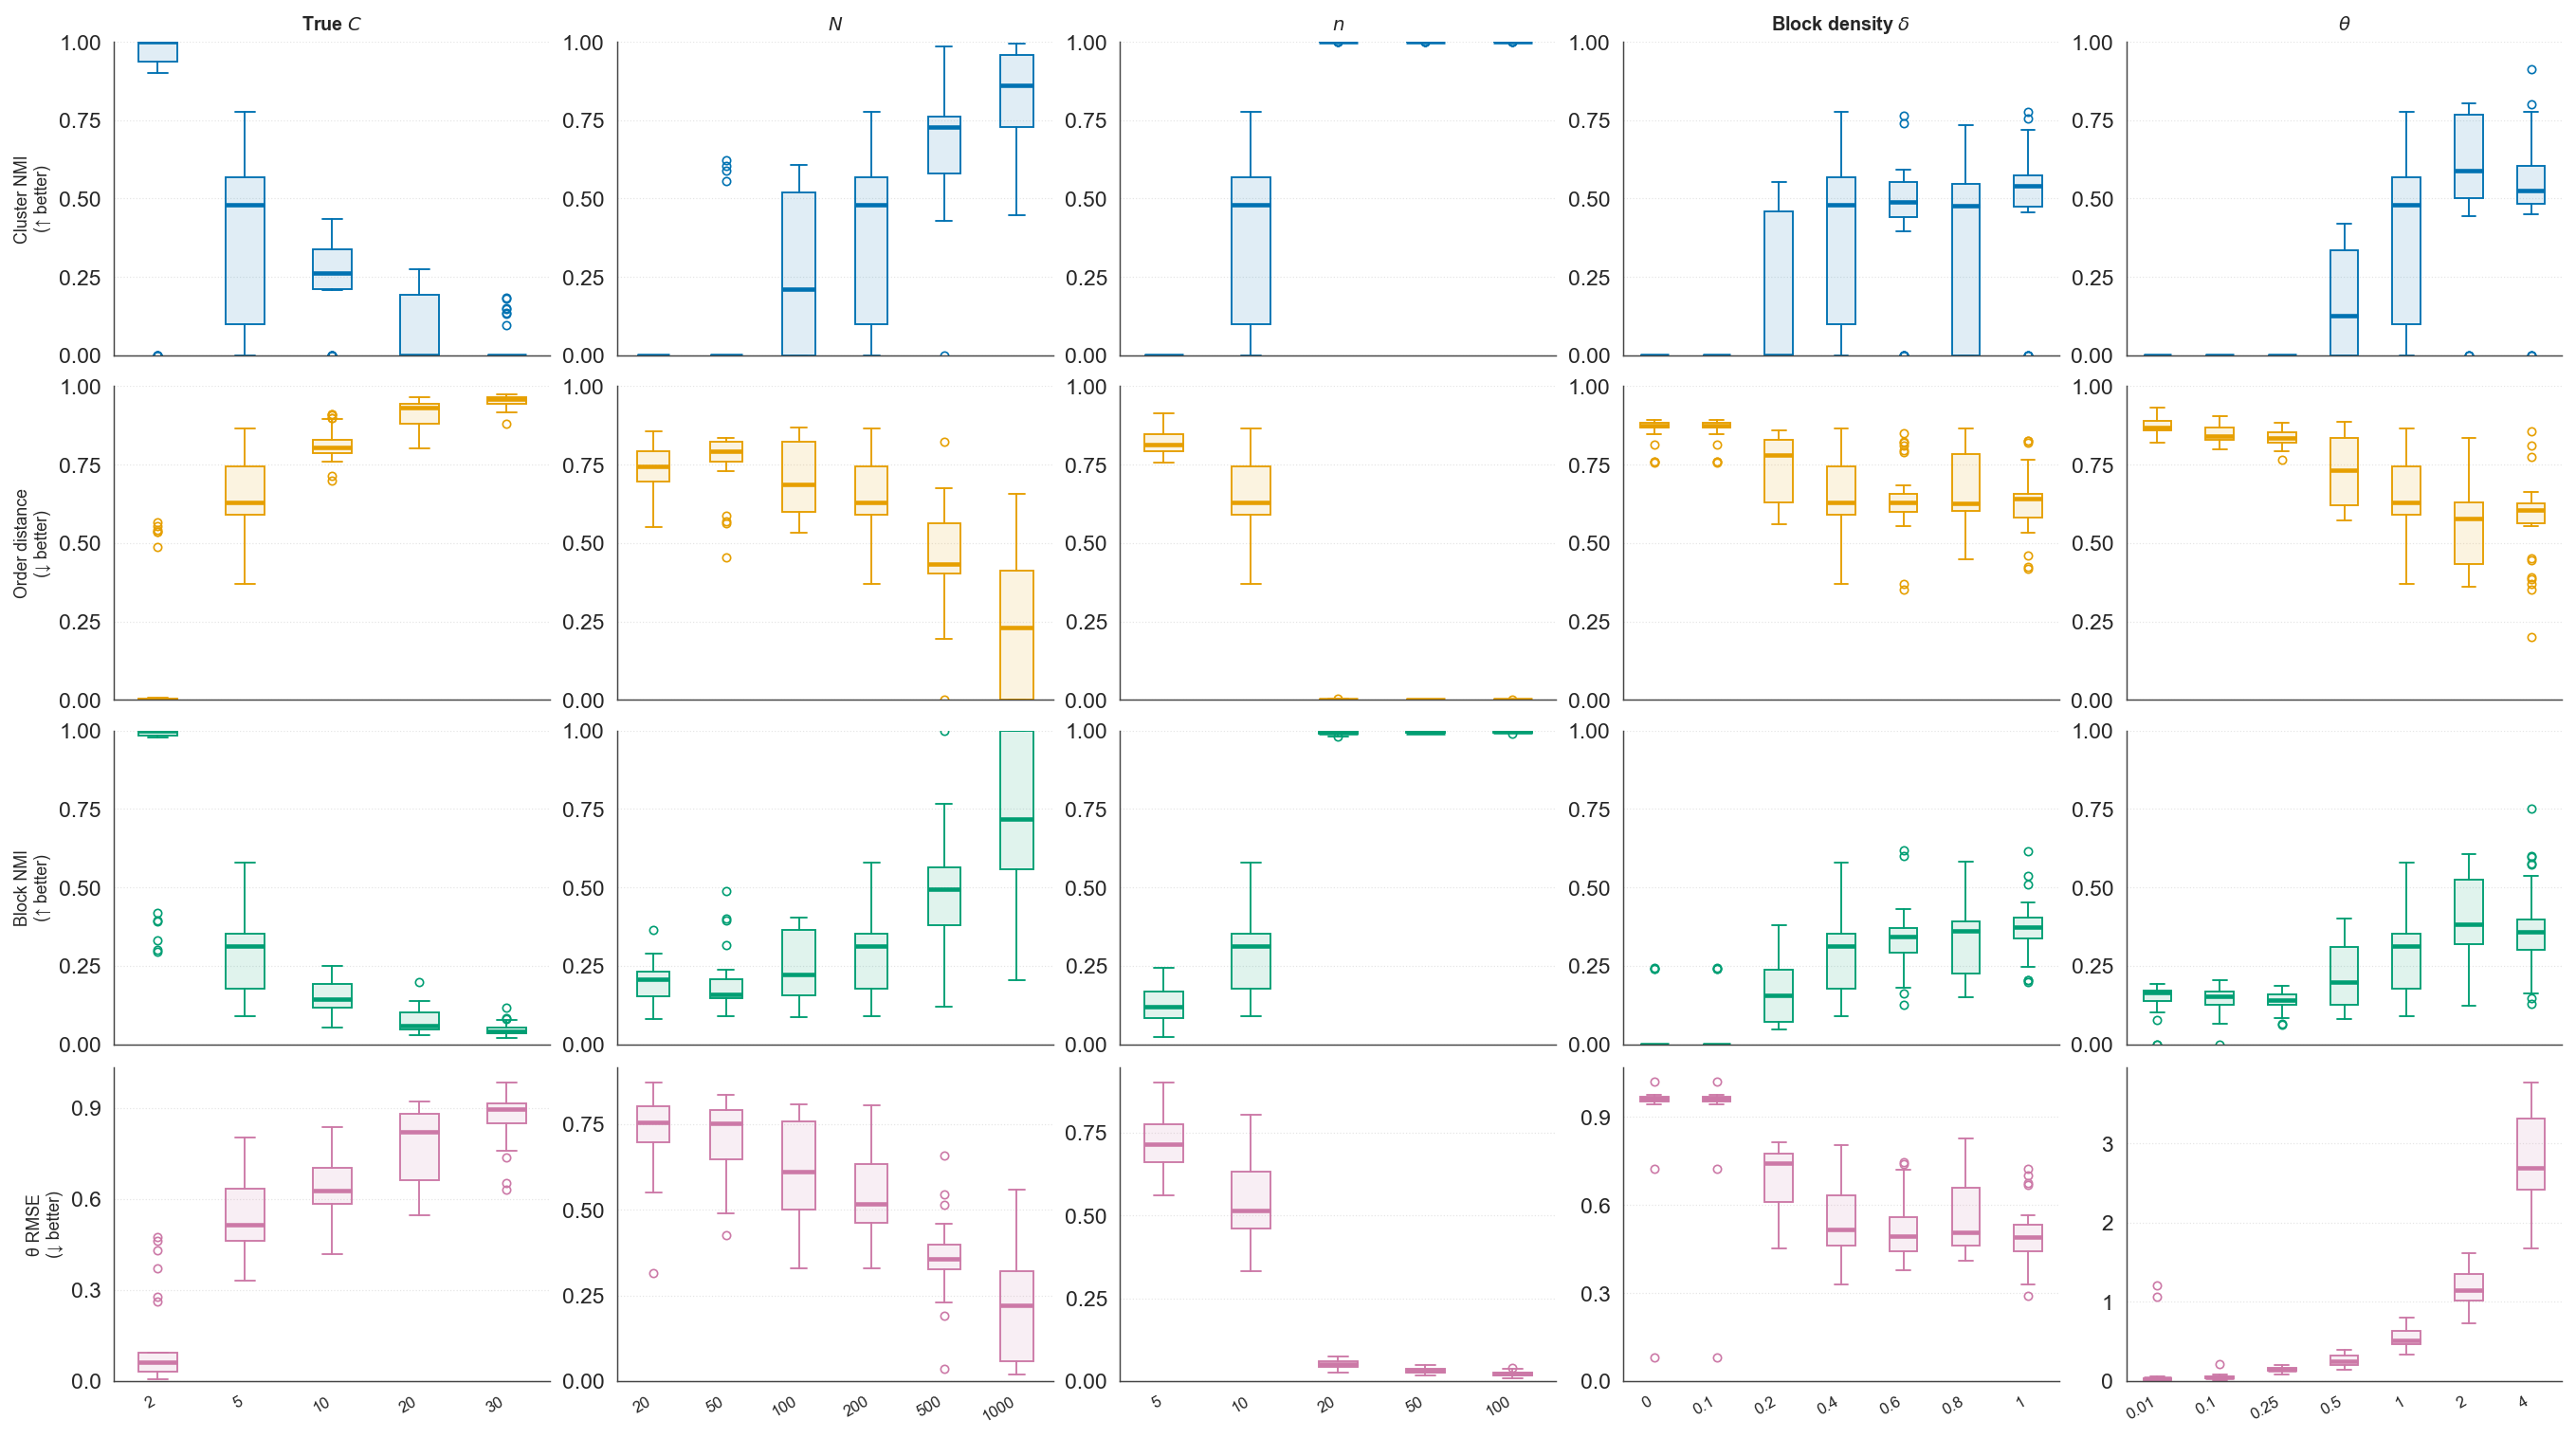

In [ ]:
# ── OAT main-effects box plot ─────────────────────────────────────────────────
fig, axes = plot_oat_boxplots(raw_trial_df)
plt.show()
# fig.savefig("oat_main_effects.pdf")   # uncomment to save


## Items × Clusters Grid Study — Hard Scenarios (C ≥ 30)

Targeted experiment testing whether **more items improve clustering recovery when the number of clusters is large**.

The OAT study revealed that cluster-NMI degrades sharply at C ≥ 30. This grid study fixes all other parameters at their OAT baselines and sweeps:

| Parameter | Values |
|---|---|
| **n_clusters** (true C) | 30, 40, 50 |
| **n_items** | 20, 50, 100, 200 |
| n_assessors | 200 (baseline) |
| block_density | 0.4 (baseline) |
| θ | 1.0 (baseline) |
| seeds | 30 (0–29) |

Total: 3 × 4 × 30 = **360 runs**.

Run the study with:
```
python _timmm_items_cluster_grid.py
# quick smoke-test:
python _timmm_items_cluster_grid.py --limit 10 --n-iter 2000 --burn-in 1000
```


In [ ]:
# ── Load items × clusters grid run ───────────────────────────────────────────
# Set GRID_RUN_NAME to pin a specific run, or None to auto-detect latest.
GRID_RUN_NAME = None   # e.g. 'recovery_items_cluster_grid_20260430_120000'

grid_run_dir = (
    RUNS_DIR / GRID_RUN_NAME if GRID_RUN_NAME
    else latest_items_cluster_grid_run()
)
_, grid_results  = load_run(grid_run_dir)
grid_trial_df    = flatten_grid_results(grid_results)

print(f"Run directory : {grid_run_dir}")
print(f"Results loaded: {len(grid_results)}")
print(f"Trial rows    : {len(grid_trial_df)}")
print(f"n_clusters    : {sorted(grid_trial_df['n_clusters_true'].unique())}")
print(f"n_items       : {sorted(grid_trial_df['n_items'].unique())}")
grid_trial_df.head()


In [ ]:
# ── Grid plot: rows = metrics, columns = n_clusters (30 / 40 / 50) ───────────
# X-axis = n_items;  each seed shown as a jittered point;
# box = IQR, median bar, whiskers = 1.5 × IQR.

_C_VALUES  = sorted(grid_trial_df['n_clusters_true'].unique())
_NI_VALUES = sorted(grid_trial_df['n_items'].unique())

n_metrics  = len(_GRID_METRIC_SPECS)
n_clusters = len(_C_VALUES)

with mpl.rc_context(_GRID_RC):
    fig, axes = plt.subplots(
        n_metrics, n_clusters,
        figsize=(3.8 * n_clusters, 2.8 * n_metrics),
        constrained_layout=True,
        squeeze=False,
    )

    for col_idx, c_val in enumerate(_C_VALUES):
        sub = grid_trial_df[grid_trial_df['n_clusters_true'] == c_val]
        x_arr = np.arange(len(_NI_VALUES))

        for row_idx, (metric_key, metric_label, direction, bounded) in enumerate(_GRID_METRIC_SPECS):
            ax    = axes[row_idx, col_idx]
            color = _PALETTE[row_idx % len(_PALETTE)]

            data = [
                sub.loc[sub['n_items'] == ni, metric_key].dropna().values
                for ni in _NI_VALUES
            ]

            ax.boxplot(
                data,
                positions=x_arr,
                widths=0.45,
                whis=1.5,
                patch_artist=True,
                manage_ticks=False,
                flierprops=dict(
                    marker='o', markersize=4,
                    markerfacecolor='none',
                    markeredgecolor=color,
                    markeredgewidth=0.8,
                    linestyle='none',
                ),
                medianprops=dict(color=color, linewidth=2.2),
                boxprops=dict(
                    facecolor=mpl.colors.to_rgba(color, alpha=0.12),
                    edgecolor=color, linewidth=0.9,
                ),
                whiskerprops=dict(color=color, linewidth=0.9, linestyle='-'),
                capprops=dict(color=color, linewidth=0.9),
            )

            # Overlay individual seed points (jittered)
            rng = np.random.default_rng(0)
            for xi, ni in enumerate(sorted(_NI_VALUES)):
                vals = sub.loc[sub['n_items'] == ni, metric_key].dropna().values
                jitter = rng.uniform(-0.18, 0.18, size=len(vals))
                ax.scatter(
                    xi + jitter, vals,
                    s=8, color=color, alpha=0.35, linewidths=0,
                    zorder=2,
                )

            ax.yaxis.grid(True)
            ax.xaxis.grid(False)
            ax.set_axisbelow(True)
            ax.set_xticks(x_arr)
            ax.set_xlim(-0.5, len(_NI_VALUES) - 0.5)

            if bounded:
                ax.set_ylim(0, 1)
                ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
            else:
                ax.set_ylim(bottom=0)
                ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4, min_n_ticks=3))

            if col_idx == 0:
                ylabel = f'{metric_label}\n({direction})' if direction else metric_label
                ax.set_ylabel(ylabel, labelpad=4)

            if row_idx == 0:
                ax.set_title(f'C = {c_val}')

            if row_idx == n_metrics - 1:
                ax.set_xticklabels(
                    [str(int(v)) for v in _NI_VALUES],
                    fontsize=8,
                )
                ax.set_xlabel('Number of items  (n)', labelpad=4)
            else:
                ax.set_xticklabels([])

    fig.suptitle(
        'Items × Clusters grid: clustering recovery vs. n_items for hard scenarios\n'
        '(N=200 assessors, block density=0.4, θ=1.0 | 30 seeds, spectral init)',
        fontsize=10, fontweight='bold',
    )

plt.show()
